In [38]:
import sys
sys.path.append('../')
sys.path.append('../..')
import importlib
import hmm_functions # import entire module so we can call importlib.reload() on it
importlib.reload(hmm_functions)
from hmm_functions import load_data, create_folds, print_n_param_updates_per_epoch, get_hyperparam_combinations, run_grid_search, plot_cv_loss, hyperparam_performance, run_full_model_eval, plot_state_time_course, get_mean_phase_coherences, leida_sanity_check, create_hypothesis_testing_dataframe
import numpy as np
import nibabel as nib
import pandas as pd
pd.set_option('display.max_colwidth', None)
import os
import pickle
import matplotlib.pyplot as plt
from osl_dynamics.models import load
from osl_dynamics.utils import plotting
from osl_dynamics.inference import modes
from osl_dynamics.analysis import post_hoc
import seaborn as sns
import _stats # import entire module so we can call importlib.reload() on it
importlib.reload(_stats)
from _stats import permtest_ind

# Prepare Data

In [47]:
experiment = 'LLstim'
data_prep_method = 'LEiDA' # 'ICA' or 'LEiDA'

if experiment == 'LLstim' and data_prep_method == 'LEiDA':
    data_path = '../../CIMT_data/no_wm/LLstim/stim_phase_coherence_matrices_no_wm_114roi.npy'
    metadata_corrected = pd.read_csv('../../CIMT_data/no_wm/LLstim/LLstim_info/metadata_corrected.csv') 
elif experiment == 'RLstim' and data_prep_method == 'LEiDA':
    data_path = '../../CIMT_data/no_wm/RLstim/right_fl_stim_phase_coherence_matrices_no_wm_116roi.npy'
    metadata_corrected = pd.read_csv('../../CIMT_data/no_wm/RLstim/RLstim_info/metadata_corrected_rmCIMT49d006_cci007_not_combined.csv')

In [4]:
# Create data array X
X, full_data = load_data(
    data_path=data_path, 
    data_prep_method=data_prep_method, 
    standardize=False, # False for LEiDA
)

# Create subj_order and y
if data_prep_method == 'ICA':   
    with open(os.path.join(data_path, data_path.split('/')[-1] + 'SelectedDataFolders.txt'), 'r') as f:
        subj_order = f.readlines()

    y = []
    i = 0
    for tc in sorted(os.listdir(data_path)):
        if re.search(r"[0-9]_timecourses_ica_s1_.nii$", tc):
            subj_order[i] = subj_order[i][-17:-1]
            y.append(subj_order[i][:-4])
            i += 1

    # Create ICA .nii file excluding bad_ICs
    denoised_gica_path = os.path.join(data_path, data_path.split('/')[-1] + '_agg__component_ica_denoised_.nii')
    if not os.path.exists(denoised_gica_path):
        gica = nib.load(os.path.join(data_path, data_path.split('/')[-1] + '_agg__component_ica_.nii'))
        gica_data = gica.get_fdata()
        print("Before:", gica_data.shape)
        gica_data = np.delete(gica_data, obj=[IC - 1 for IC in bad_ICs], axis=3)
        print("After:", gica_data.shape)
        gica_nii = nib.Nifti1Image(gica_data, gica.affine, header=gica.header)
        nib.save(gica_nii, denoised_gica_path)
elif data_prep_method == 'LEiDA':
    subj_order = metadata_corrected['subject_id'].unique()
    y = [subj[:-4] for subj in subj_order]
else:
    raise ValueError("invalid data_prep_method. Only ICA and LEiDA are supported")

subj_order = np.array(subj_order) # the subject labels in the EXACT order that the subjects appear in X
y = np.array(y) # the experimental cohort of each subject in the EXACT order that the subjects appear in X
print("X shape:", X.shape)
print("full_data attributes:", full_data)
print("subj_order shape:", subj_order.shape)
print("y shape:", y.shape)

Loading files:   0%|          | 0/114 [00:00<?, ?it/s]

X shape: (114, 250, 114)
full_data attributes: Data
 id: 13249162336
 n_sessions: 114
 n_samples: 28500
 n_channels: 114
subj_order shape: (114,)
y shape: (114,)


In [5]:
print(subj_order)

cohorts, cnt = np.unique_counts(y)
for i in range(len(cohorts)):
    print(f"Number of subjects in {cohorts[i]}: {cnt[i]}")

['CCI_CIMT_07d_001' 'CCI_CIMT_07d_004' 'CCI_CIMT_07d_006'
 'CCI_CIMT_07d_007' 'CCI_CIMT_07d_010' 'CCI_CIMT_07d_011'
 'CCI_CIMT_07d_020' 'CCI_CIMT_07d_022' 'CCI_CIMT_07d_024'
 'CCI_CIMT_07d_032' 'CCI_CIMT_07d_033' 'CCI_CIMT_07d_037'
 'CCI_CIMT_07d_038' 'CCI_CIMT_07d_039' 'CCI_CIMT_07d_040'
 'CCI_CIMT_21d_001' 'CCI_CIMT_21d_004' 'CCI_CIMT_21d_006'
 'CCI_CIMT_21d_007' 'CCI_CIMT_21d_010' 'CCI_CIMT_21d_011'
 'CCI_CIMT_21d_020' 'CCI_CIMT_21d_022' 'CCI_CIMT_21d_024'
 'CCI_CIMT_21d_032' 'CCI_CIMT_21d_033' 'CCI_CIMT_21d_037'
 'CCI_CIMT_21d_038' 'CCI_CIMT_21d_039' 'CCI_CIMT_21d_040'
 'CCI_CIMT_49d_001' 'CCI_CIMT_49d_004' 'CCI_CIMT_49d_006'
 'CCI_CIMT_49d_007' 'CCI_CIMT_49d_010' 'CCI_CIMT_49d_011'
 'CCI_CIMT_49d_020' 'CCI_CIMT_49d_022' 'CCI_CIMT_49d_024'
 'CCI_CIMT_49d_032' 'CCI_CIMT_49d_033' 'CCI_CIMT_49d_037'
 'CCI_CIMT_49d_038' 'CCI_CIMT_49d_039' 'CCI_CIMT_49d_040'
 'CCI_none_07d_002' 'CCI_none_07d_003' 'CCI_none_07d_005'
 'CCI_none_07d_009' 'CCI_none_07d_012' 'CCI_none_07d_013'
 'CCI_none_07d

In [6]:
n_splits = 5
split_plan = create_folds(
    n_splits=n_splits, 
    X=X, 
    y=y, 
    inner_val_size=0.2, 
    random_state=42,
    standardize=False, # False for LEiDA
)

Fold 1:
  Train: index=[  3   4   5   6   7   8   9  10  11  12  13  14  18  19  20  21  22  23
  24  25  26  27  28  29  33  34  35  36  37  38  39  40  41  42  43  44
  48  49  50  51  52  53  54  55  56  57  58  59  63  64  65  66  67  68
  69  70  71  72  73  74  78  79  80  81  82  83  84  85  86  87  88  89
  92  93  94  95  96  97 100 101 102 103 104 105 107 108 109 110 111 112
 113]
  Test:  index=[  0   1   2  15  16  17  30  31  32  45  46  47  60  61  62  75  76  77
  90  91  98  99 106]


Loading files:   0%|          | 0/91 [00:00<?, ?it/s]

Loading files:   0%|          | 0/23 [00:00<?, ?it/s]

Loading files:   0%|          | 0/72 [00:00<?, ?it/s]

Loading files:   0%|          | 0/19 [00:00<?, ?it/s]

...

Fold 5:
  Train: index=[  0   1   2   3   4   5   6   7   8   9  10  11  15  16  17  18  19  20
  21  22  23  24  25  26  30  31  32  33  34  35  36  37  38  39  40  41
  45  46  47  48  49  50  51  52  53  54  55  56  60  61  62  63  64  65
  66  67  68  69  70  71  75  76  77  78  79  80  81  82  83  84  85  86
  90  91  92  93  94  95  96  98  99 100 101 102 103 106 107 108 109 110
 111 112]
  Test:  index=[ 12  13  14  27  28  29  42  43  44  57  58  59  72  73  74  87  88  89
  97 104 105 113]


Loading files:   0%|          | 0/92 [00:00<?, ?it/s]

Loading files:   0%|          | 0/22 [00:00<?, ?it/s]

Loading files:   0%|          | 0/73 [00:00<?, ?it/s]

Loading files:   0%|          | 0/19 [00:00<?, ?it/s]

# Train HMM

In [49]:
if data_prep_method == 'ICA':
    hmm_run = f"ICA_{full_data.n_channels}c_no_TDE"
elif data_prep_method == 'LEiDA':
    hmm_run = f"LEiDA_{full_data.n_channels}c_no_TDE"

hmm_run

'LEiDA_114c_no_TDE'

In [50]:
grid_search_log = {}
grid_search_log_save_path = f'{experiment}/grid_search/grid_search_log_{hmm_run}.pkl'

if os.path.exists(grid_search_log_save_path):
    with open(grid_search_log_save_path, 'rb') as f:
        grid_search_log = pickle.load(f)
else:
    os.makedirs(f'{experiment}/grid_search', exist_ok=True)

sorted(grid_search_log.keys())

[3, 4, 5, 6, 7, 8, 9]

In [51]:
hyperparam_grid = {
    'k': [7], # range(2, 15),
    'sequence_length': [50],
    'learn_means': [True], # try True for LEiDA
    'learn_covariances': [True],
    'set_regularizers': [True],
    'batch_size': [32], 
    'learning_rate': [3e-4, 1e-3], 
    'lr_decay': [0.0, 0.005], # Optimize learning_rate with a lr_decay of 0.05 first, then optimize lr_decay with the commented values
    'n_epochs': [5000], # using early stopping anyways, so just set to a high number
    'patience': [20],
}

print_n_param_updates_per_epoch(hyperparam_grid, full_data)

Number of parameter updates per epoch with sequence_length=50 and batch_size=32: 18


In [15]:
run_grid_search(
    grid_search_log=grid_search_log, 
    grid_search_log_save_path=grid_search_log_save_path, 
    hyperparam_grid=hyperparam_grid, 
    seed=42, 
    split_plan=split_plan,
)

2026-05-18 18:34:08 INFO osl-dynamics [hmm.py:368:set_regularizers]: Setting regularizers



Hyperparam set 1: {'k': 7, 'sequence_length': 50, 'learn_means': True, 'learn_covariances': True, 'set_regularizers': True, 'batch_size': 32, 'learning_rate': 0.0001, 'lr_decay': 0.0, 'n_epochs': 5000, 'patience': 20}

Fold 1...


2026-05-18 18:34:08.702454: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2026-05-18 18:34:08 INFO osl-dynamics [inf_mod_base.py:1435:random_state_time_course_initialization]: Random state time course initialization
2026-05-18 18:34:08 INFO osl-dynamics [inf_mod_base.py:1451:random_state_time_course_initialization]: Initialization 0
2026-05-18 18:34:08 INFO osl-dynamics [inf_mod_base.py:1491:set_random_state_time_course_initialization]: Setting random means and covariances
2026-05-18 18:34:08 INFO osl-dynamics [inf_mod_base.py:1341:random_subset_initialization]: Random subset initialization
2026-05-18 18:34:08 INFO osl-dynamics [inf_mod_base.py:1357:random_subset_initialization]: Initialization 0


random_state_time_course_initialization can't simulate a state time course where each state activates. Switching to using random_subset_initialization instead.


2026-05-18 18:34:11 INFO osl-dynamics [inf_mod_base.py:1357:random_subset_initialization]: Initialization 1
2026-05-18 18:34:14 INFO osl-dynamics [inf_mod_base.py:1357:random_subset_initialization]: Initialization 2
2026-05-18 18:34:17 INFO osl-dynamics [inf_mod_base.py:1385:random_subset_initialization]: Using initialization 0


KeyboardInterrupt: 

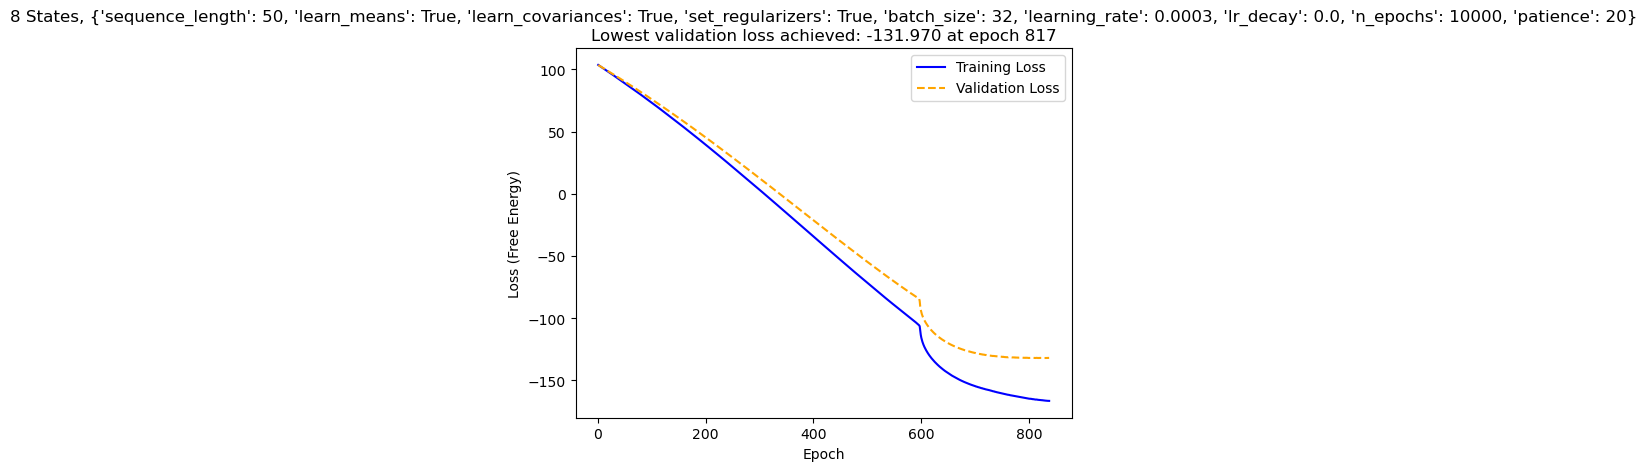

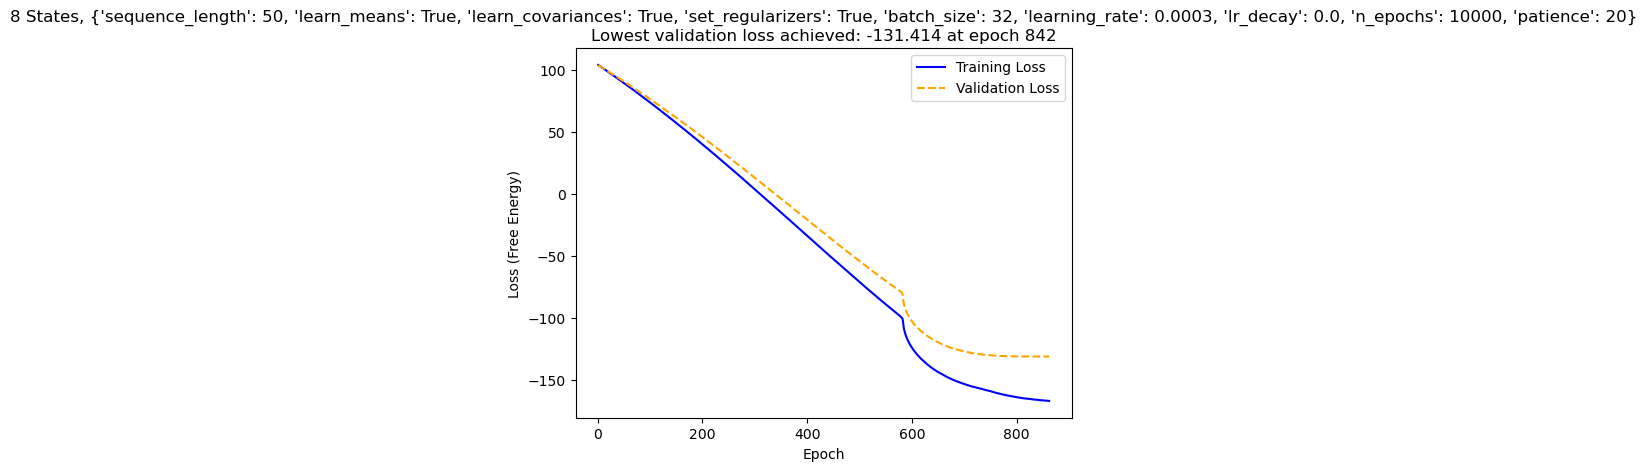

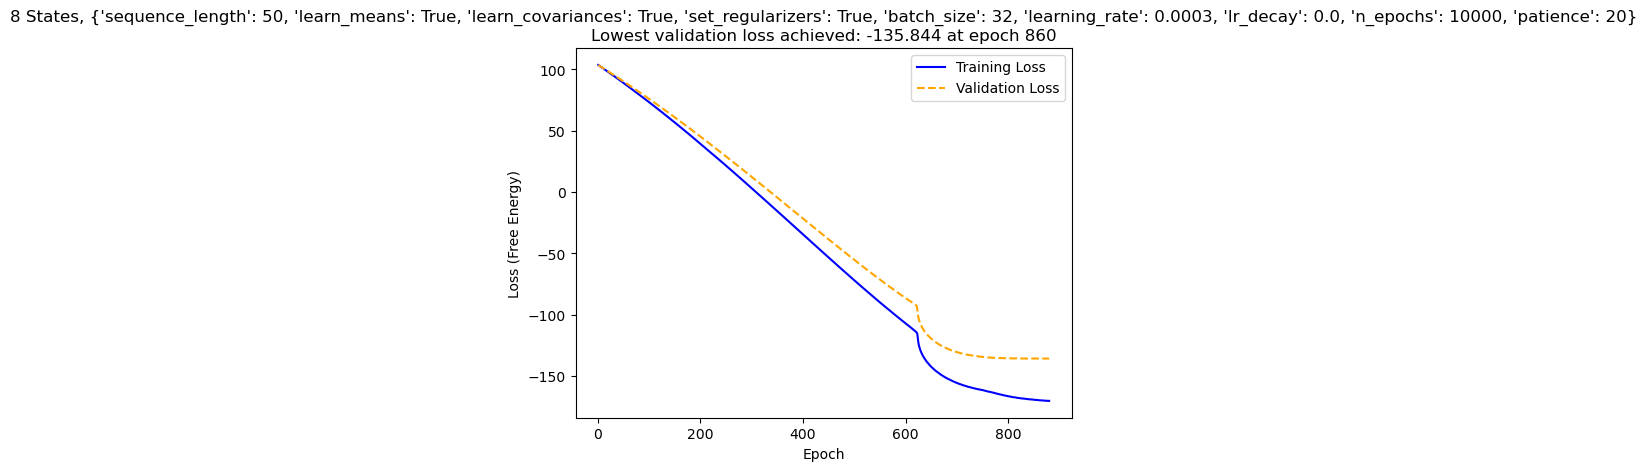

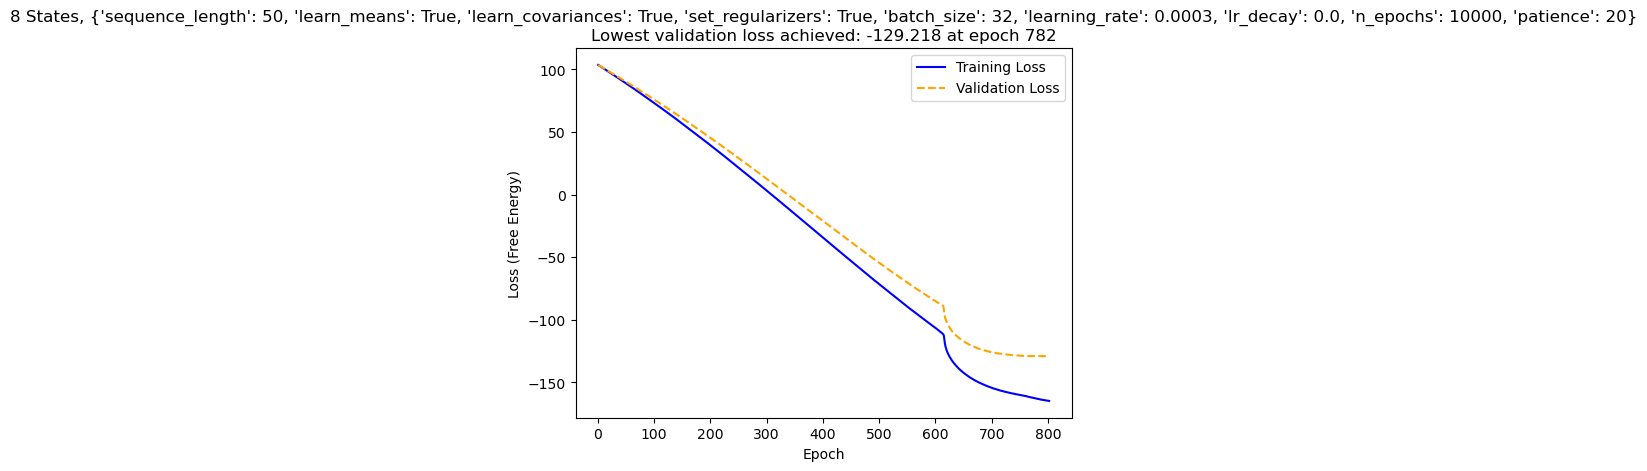

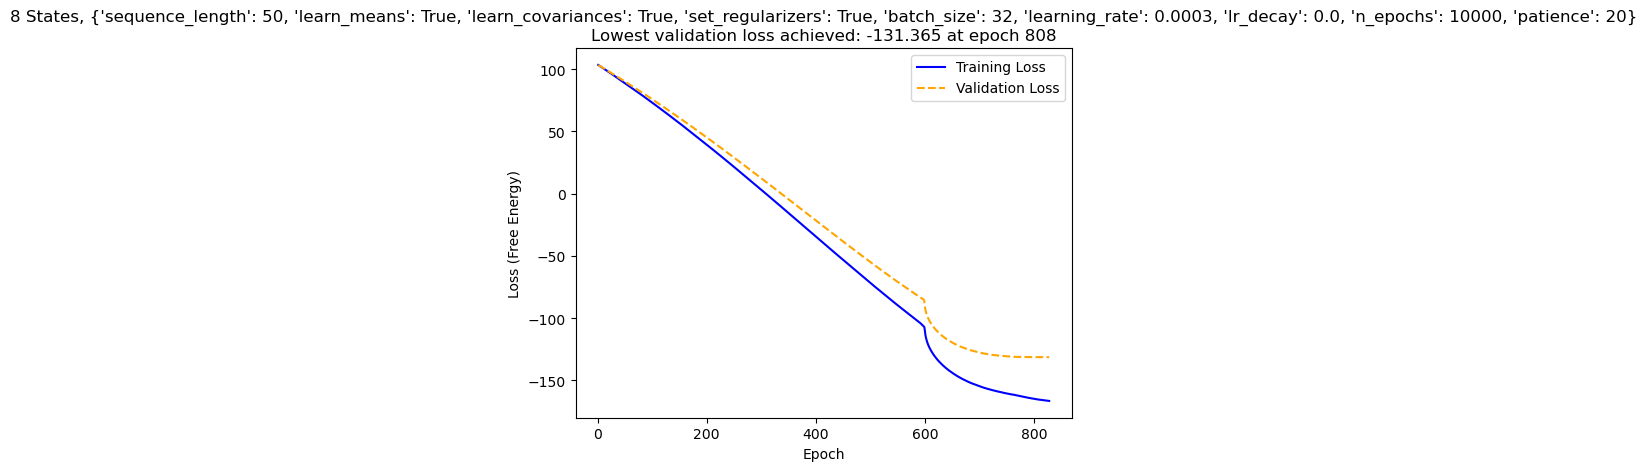

In [53]:
plot_cv_loss(grid_search_log, 8, split_plan)

In [90]:
performance_df = hyperparam_performance(grid_search_log, 9)
performance_df

,k,hyperparams,average_outer_free_energy,best_inner_training_epochs
0,9,"{'sequence_length': 50, 'learn_means': True, 'learn_covariances': True, 'set_regularizers': True, 'batch_size': 32, 'learning_rate': 0.0003, 'lr_decay': 0.0, 'n_epochs': 10000, 'patience': 20}",-132.531999,"[826, 817, 874, 770, 824]"
1,9,"{'sequence_length': 50, 'learn_means': True, 'learn_covariances': True, 'set_regularizers': True, 'batch_size': 32, 'learning_rate': 0.001, 'lr_decay': 0.005, 'n_epochs': 10000, 'patience': 20}",-117.468592,"[1980, 2000, 2041, 2063, 2036]"
2,9,"{'sequence_length': 50, 'learn_means': True, 'learn_covariances': True, 'set_regularizers': True, 'batch_size': 32, 'learning_rate': 0.001, 'lr_decay': 0.01, 'n_epochs': 10000, 'patience': 20}",0.312484,"[1171, 1195, 1123, 1224, 1185]"
3,9,"{'sequence_length': 50, 'learn_means': True, 'learn_covariances': True, 'set_regularizers': True, 'batch_size': 32, 'learning_rate': 0.0003, 'lr_decay': 0.005, 'n_epochs': 10000, 'patience': 20}",46.031680,"[2259, 2258, 2268, 2196, 2259]"
4,9,"{'sequence_length': 50, 'learn_means': True, 'learn_covariances': True, 'set_regularizers': True, 'batch_size': 32, 'learning_rate': 0.0003, 'lr_decay': 0.01, 'n_epochs': 10000, 'patience': 20}",76.086039,"[1133, 1144, 1139, 1137, 1150]"
5,9,"{'sequence_length': 50, 'learn_means': True, 'learn_covariances': True, 'set_regularizers': True, 'batch_size': 32, 'learning_rate': 0.0001, 'lr_decay': 0.005, 'n_epochs': 10000, 'patience': 20}",85.893557,"[1902, 1903, 1909, 1918, 1920]"
6,9,"{'sequence_length': 50, 'learn_means': True, 'learn_covariances': True, 'set_regularizers': True, 'batch_size': 32, 'learning_rate': 0.0001, 'lr_decay': 0.01, 'n_epochs': 10000, 'patience': 20}",95.022628,"[888, 888, 895, 882, 882]"
7,9,"{'sequence_length': 50, 'learn_means': True, 'learn_covariances': True, 'set_regularizers': True, 'batch_size': 32, 'learning_rate': 0.0001, 'lr_decay': 0.0, 'n_epochs': 10000, 'patience': 20}",inf,"[2798, 2624, 2919, 2714, 2563]"
8,9,"{'sequence_length': 50, 'learn_means': True, 'learn_covariances': True, 'set_regularizers': True, 'batch_size': 32, 'learning_rate': 0.001, 'lr_decay': 0.0, 'n_epochs': 10000, 'patience': 20}",inf,"[259, 260, 225, 214, 237]"


# Compute Model Evaluation Metrics on Full Dataset 

In [ ]:
results_path = f'{experiment}/results/{hmm_run}'
model_eval_log = {}
model_eval_log_save_path = results_path + f'/model_eval_log_{hmm_run}.pkl'

if os.path.exists(model_eval_log_save_path):
    with open(model_eval_log_save_path, 'rb') as f:
        model_eval_log = pickle.load(f)
else:
    os.makedirs(results_path, exist_ok=True)

sorted(model_eval_log.keys())

In [16]:
run_full_model_eval(
    model_eval_log=model_eval_log, 
    model_eval_log_save_path=model_eval_log_save_path, 
    k_values=[3], 
    n_realizations=10, 
    model_save_metric='total_LL', # may want to change to free_energy to stay consistent with run_grid_search()
    seed=42, 
    full_data=full_data,
    results_path=results_path, 
)

Fitting model with 3 states...
The model with 3 states has already been evaluated on the full dataset, skipping ...


# Compute Summary Statistics

## Load model of interest and compute preliminary summary statistics

In [452]:
k_optimal = 7
model = load(model_eval_log[k_optimal]['best_realization_path'])

2026-05-18 16:26:21 INFO osl-dynamics [mod_base.py:781:load]: Loading model: CIMT/LLstim/results/LEiDA_114c_no_TDE/7_states/7_states_model


In [453]:
inf_params_path = f'{results_path}/{k_optimal}_states/inf_params'
os.makedirs(inf_params_path, exist_ok=True)

In [454]:
alpha_path = f'{inf_params_path}/alp_{k_optimal}_states.pkl'
if os.path.exists(alpha_path):
    alpha = pickle.load(open(alpha_path, 'rb'))
else:
    alpha = model.get_alpha(full_data)
    pickle.dump(alpha, open(alpha_path, 'wb'))

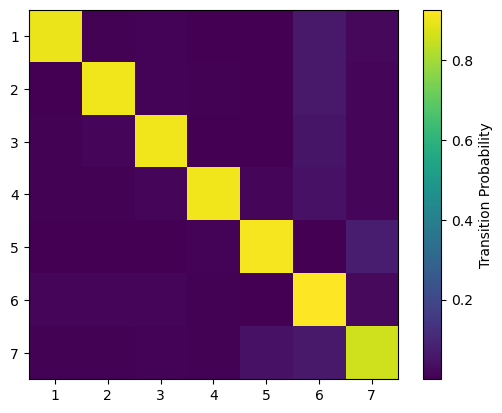

In [455]:
trans_matrix = model.get_trans_prob()
plt.imshow(trans_matrix, origin='upper')
plt.xticks(ticks=range(0, k_optimal), labels=range(1, k_optimal + 1))
plt.yticks(ticks=range(0, k_optimal), labels=range(1, k_optimal + 1))
plt.colorbar(label='Transition Probability')
plt.show()

In [456]:
# Now the group-level means and covs
means_path, covs_path = f'{inf_params_path}/means_{k_optimal}_states.npy', f'{inf_params_path}/covs_{k_optimal}_states.npy'

if os.path.exists(means_path) and os.path.exists(covs_path):
    means, covs = np.load(means_path), np.load(covs_path)
else:
    means, covs = model.get_means_covariances()
    np.save(means_path, means)
    np.save(covs_path, covs)

means.shape, covs.shape

((7, 114), (7, 114, 114))

In [457]:
type(alpha), len(alpha) # each element of alpha is a subject

(list, 114)

In [458]:
# Hard classify the state probabilities (i.e., for each time point set each probability to either 0 or 1)
stc = np.array(modes.argmax_time_courses(alpha)) # state time course
print(stc.shape)

(114, 250, 7)


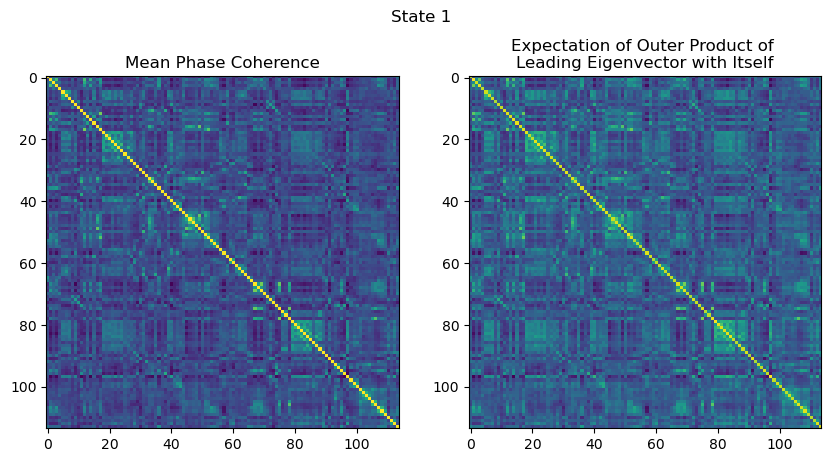

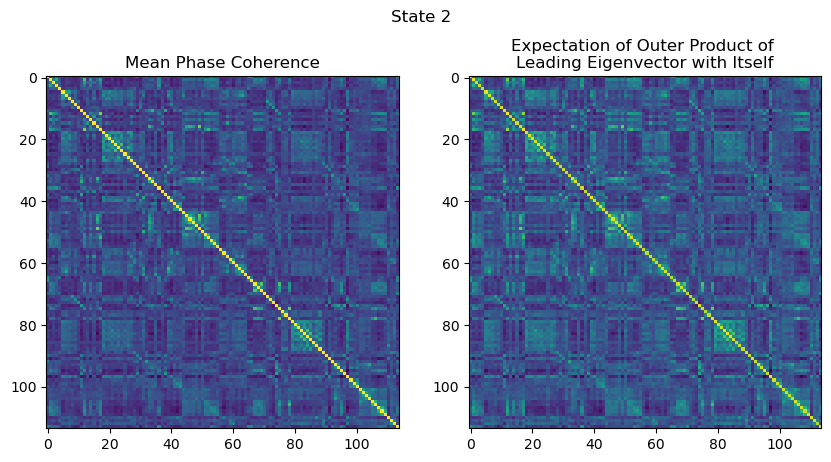

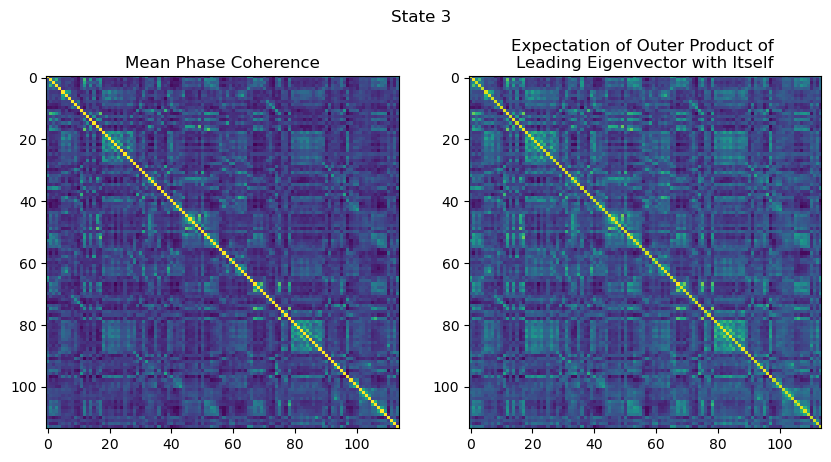

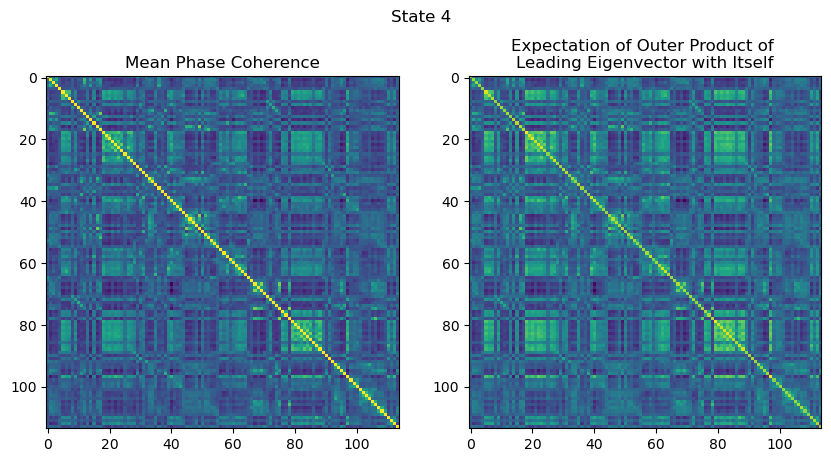

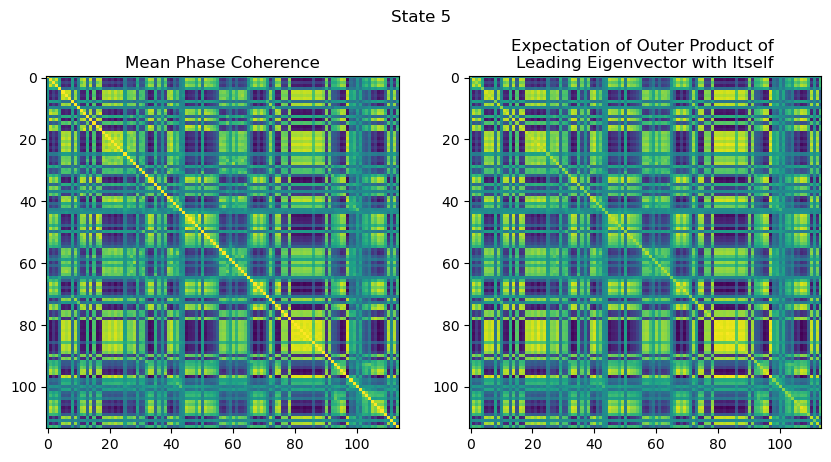

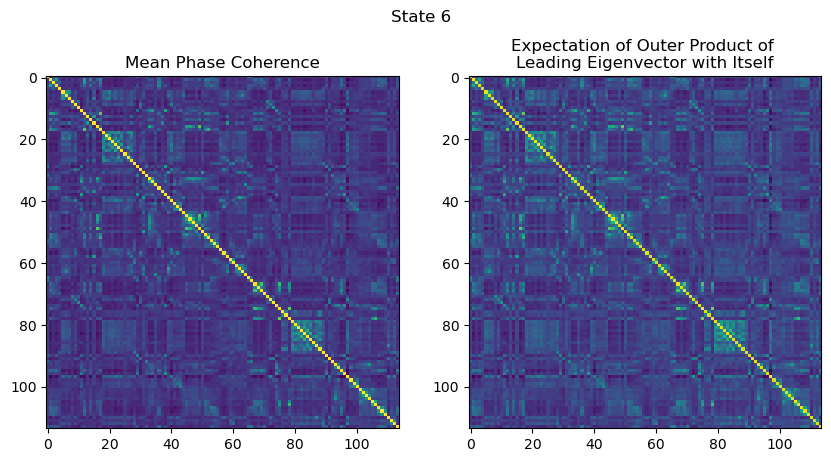

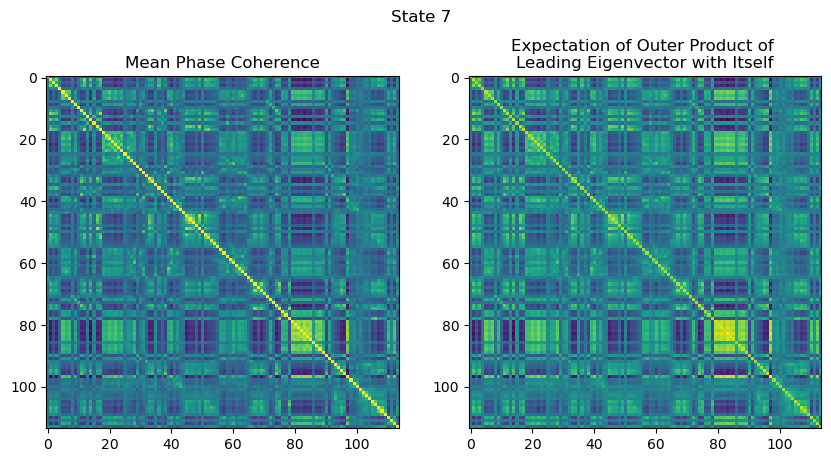

In [459]:
if data_prep_method == 'LEiDA':
    phase_coherence = np.load(data_path)
    mean_phase_coherences = get_mean_phase_coherences(
        phase_coherence=phase_coherence,
        full_data=full_data,
        stc=stc,
    )

    np.save(f'{results_path}/{k_optimal}_states/mean_phase_coherences.npy', mean_phase_coherences)
    
    outer_products = leida_sanity_check(
        mean_phase_coherences=mean_phase_coherences,
        state_means=means, 
        state_covs=covs,
        figsize=(10, 5),
    )

In [460]:
# Fractional occupancy (FO)
fo = modes.fractional_occupancies(stc)
fo.shape

(114, 7)

In [461]:
# FO of each state averaged across subjects
sorted_fos = [] # (state_num, FO)
mean_fos = np.mean(fo, axis=0)
for i in range(k_optimal):
    sorted_fos.append((i + 1, mean_fos[i]))

sorted_fos.sort(key=lambda x: x[1], reverse=True)
for state, f in sorted_fos:
    print(f"State {state} FO:", f)

State 6 FO: 0.39810526315789485
State 7 FO: 0.1558596491228069
State 3 FO: 0.12094736842105257
State 5 FO: 0.1032982456140351
State 2 FO: 0.09084210526315785
State 1 FO: 0.06680701754385959
State 4 FO: 0.06414035087719294


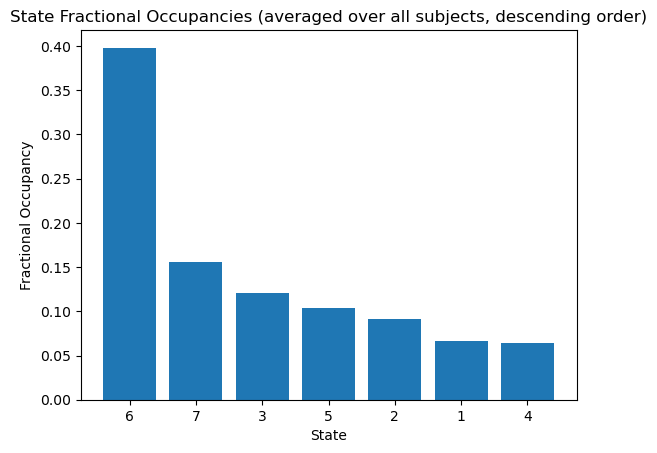

In [462]:
plt.bar(x=[str(x[0]) for x in sorted_fos], height=[x[1] for x in sorted_fos])
plt.title("State Fractional Occupancies (averaged over all subjects, descending order)")
plt.xlabel("State")
plt.ylabel("Fractional Occupancy")
plt.show()

In [463]:
for state_num, _ in sorted_fos:
    print(f"Total number of samples assigned to state {state_num}: {np.sum(stc[:, :, state_num - 1] == 1)}")

Total number of samples assigned to state 6: 11346
Total number of samples assigned to state 7: 4442
Total number of samples assigned to state 3: 3447
Total number of samples assigned to state 5: 2944
Total number of samples assigned to state 2: 2589
Total number of samples assigned to state 1: 1904
Total number of samples assigned to state 4: 1828


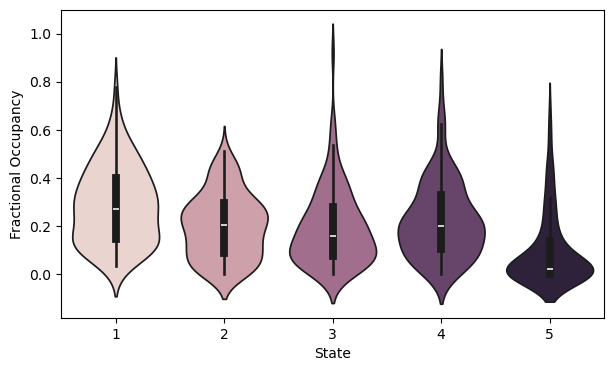

In [415]:
# Plot the distribution of fractional occupancy (FO) across subjects
fig, ax = plotting.plot_violin(fo.T, x_label="State", y_label="Fractional Occupancy")

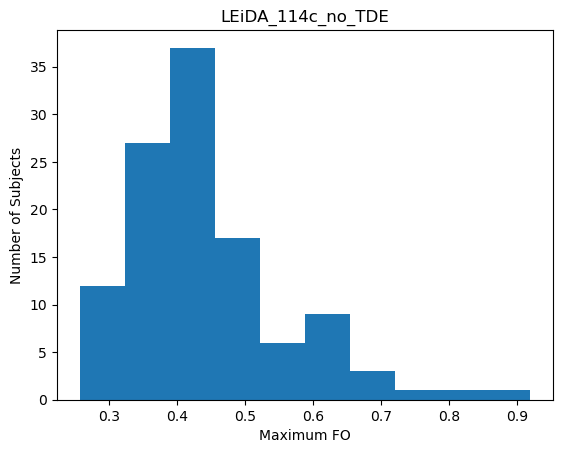

In [416]:
# Plot historgram of maximum FOs (maxFOs) to make sure there aren't states dominating subject time courses
fig, ax = plt.subplots(1, 1)
ax.hist(np.max(fo, axis=1))
ax.set_title(hmm_run)
ax.set_xlabel("Maximum FO")
ax.set_ylabel("Number of Subjects")

plt.show()

In [417]:
# Mean maxFOs for each experimental group
for group in np.unique(y):
    print(f"{group}:", np.mean(np.max(fo[np.where(y == group)[0],], axis=1)))

CCI_CIMT_07d: 0.44213333333333343
CCI_CIMT_21d: 0.4037333333333334
CCI_CIMT_49d: 0.46266666666666667
CCI_none_07d: 0.42426666666666674
CCI_none_21d: 0.5018666666666667
CCI_none_49d: 0.4370666666666666
SHM_none_07d: 0.477
SHM_none_21d: 0.4545
SHM_none_49d: 0.3935


In [418]:
count = 0
for subj_idx in np.where(np.max(fo, axis=1) >= 0.9)[0]:
    count += 1
    print(subj_order[subj_idx][-17:])

count

SHM_none_07d_018


1

## Subject-Level State Time Courses (Viterbi Paths)

In [215]:
if experiment == 'CIMT/LLstim' or experiment == 'CIMT/RLstim':
    stim_times = ([0] * 15 + [1] * 10) * 10
    print(len(stim_times))

250


### 07d

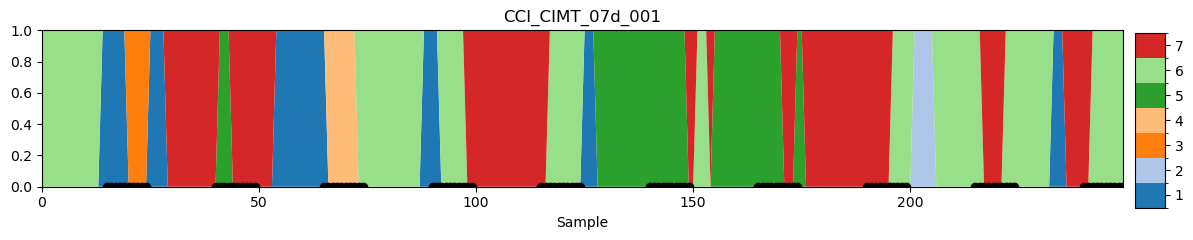

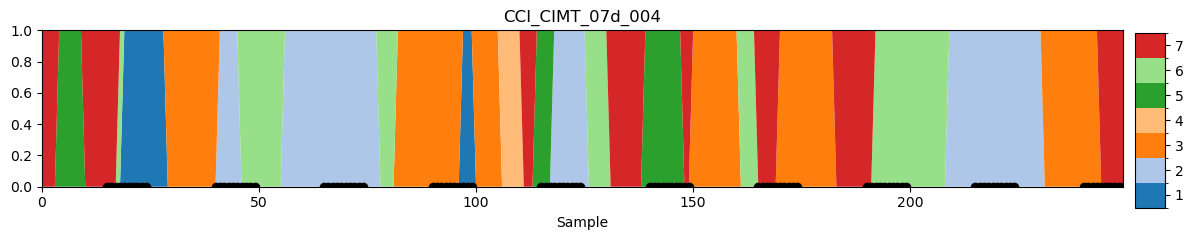

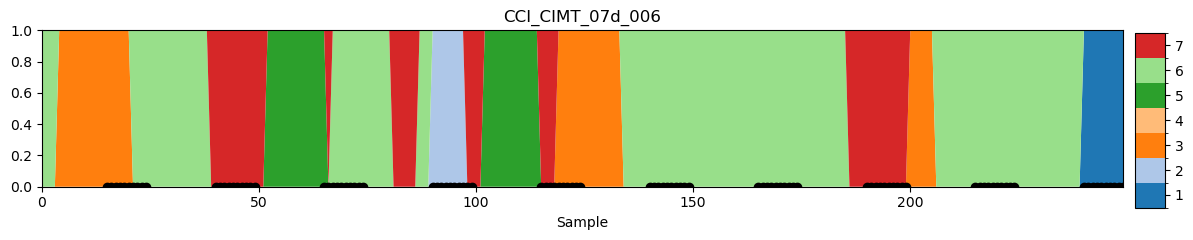

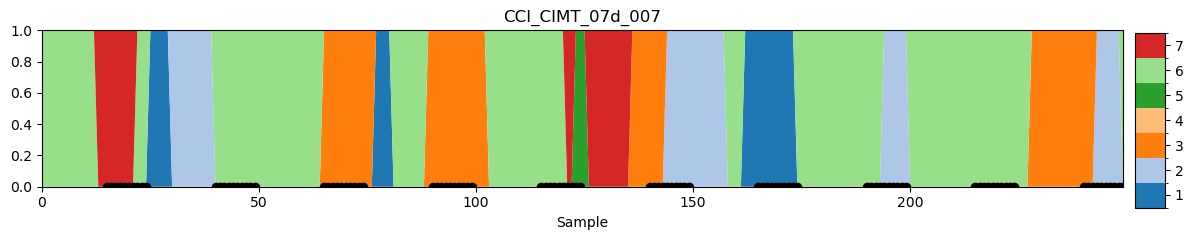

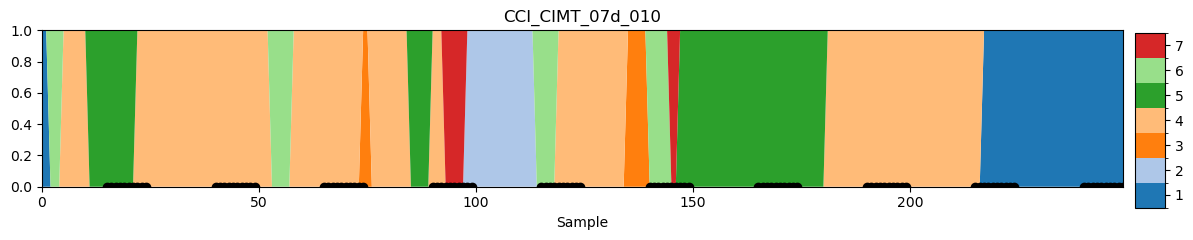

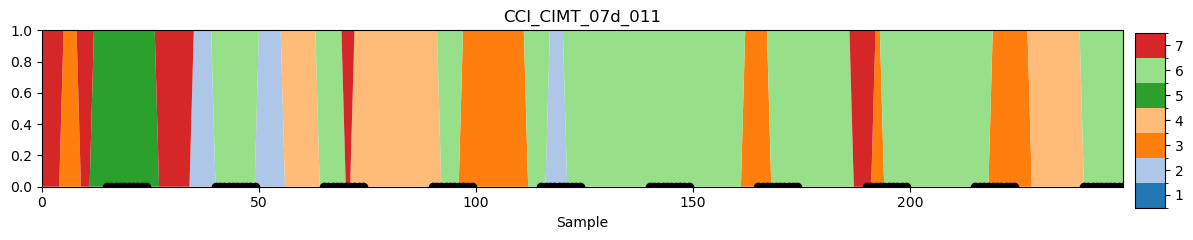

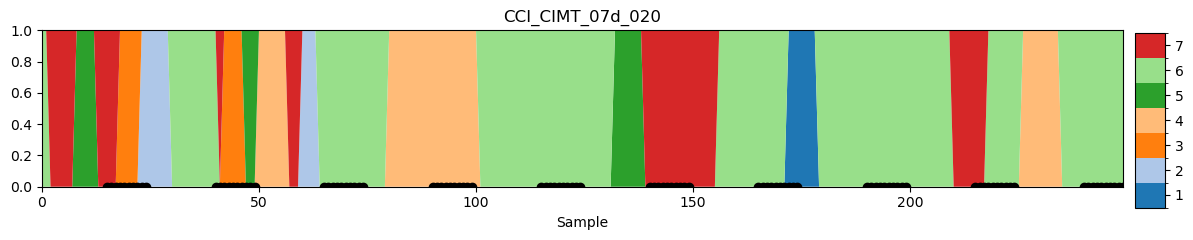

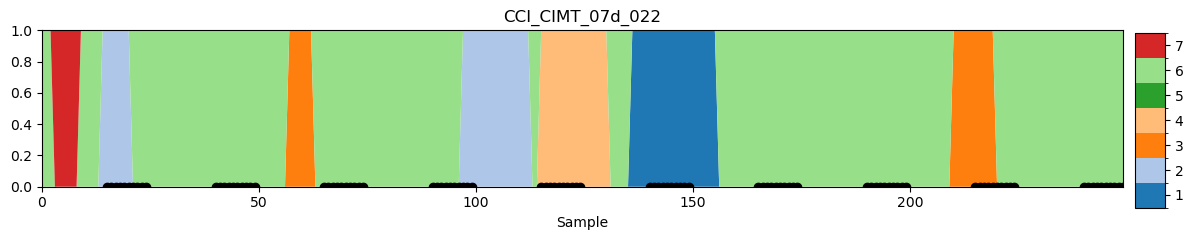

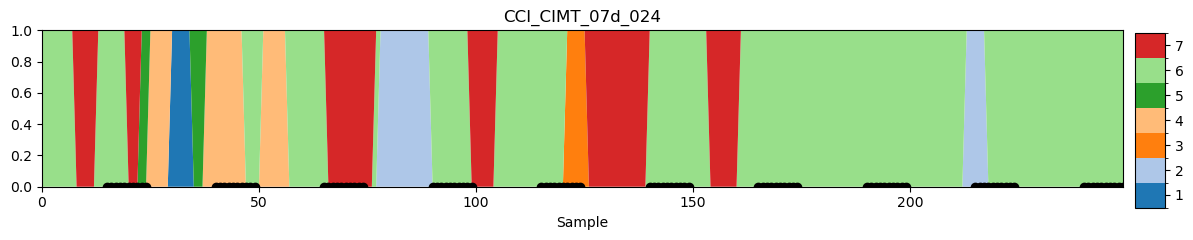

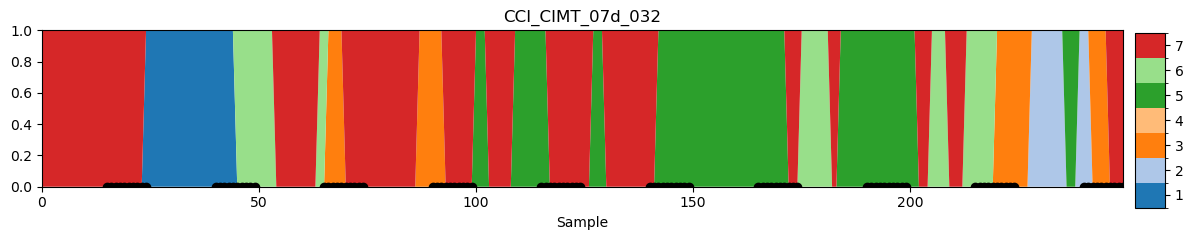

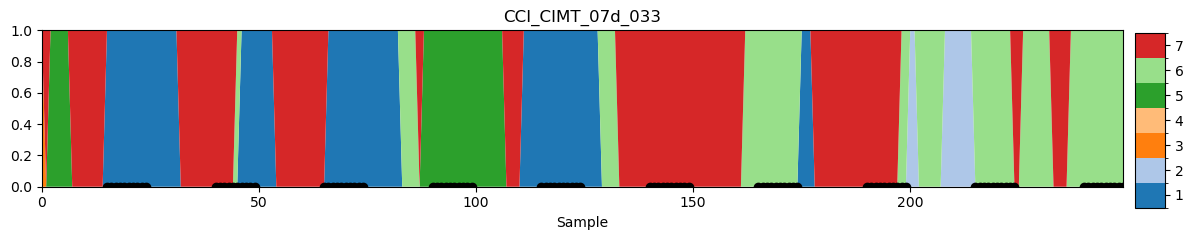

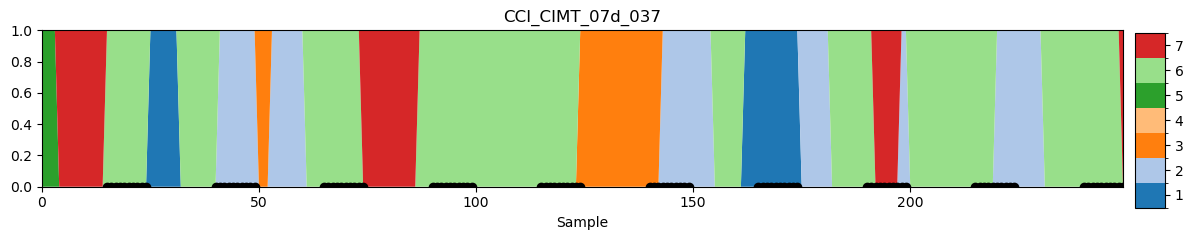

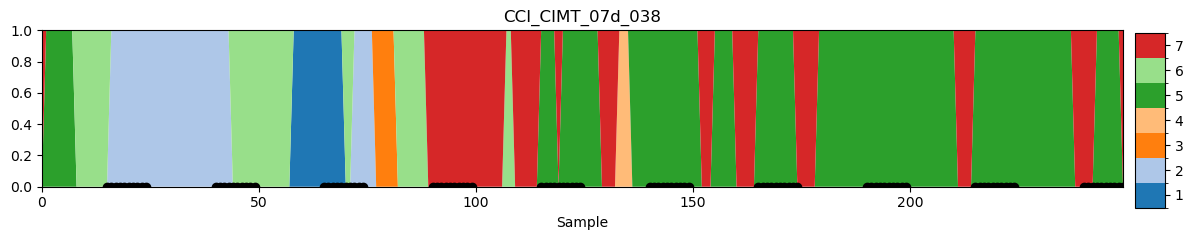

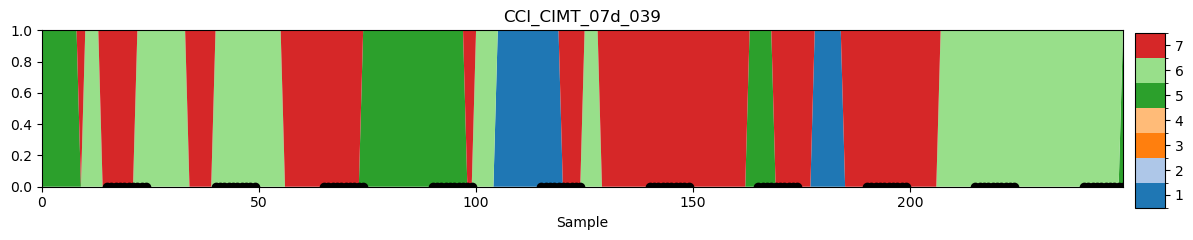

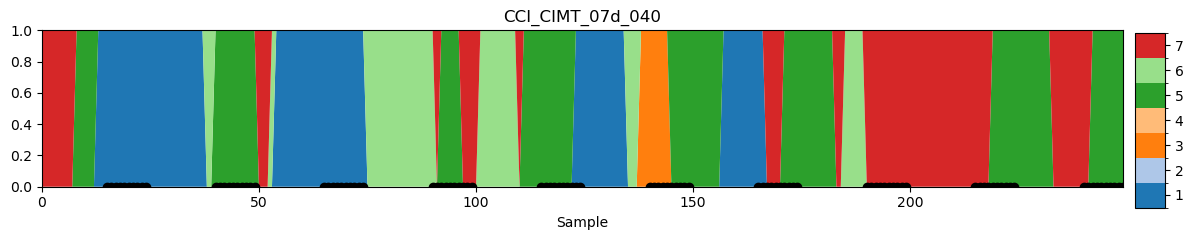

In [424]:
for subj in np.where(y == 'CCI_CIMT_07d')[0]:
    plot_state_time_course(subj_tc=stc[subj], n_samples=X.shape[1], cmap='tab20', title=str(subj_order[subj][-17:]), stim_times=stim_times if stim_times else None)

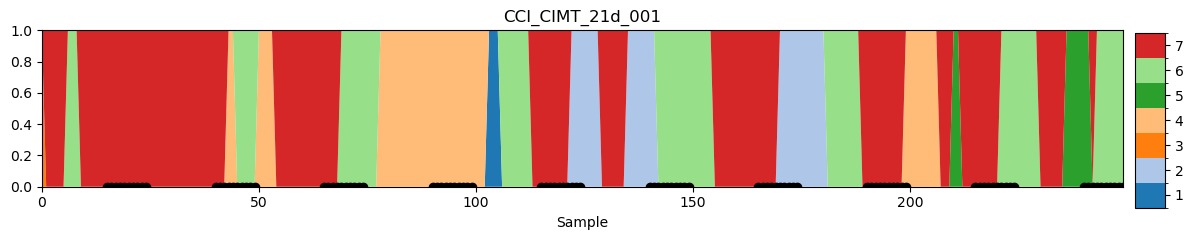

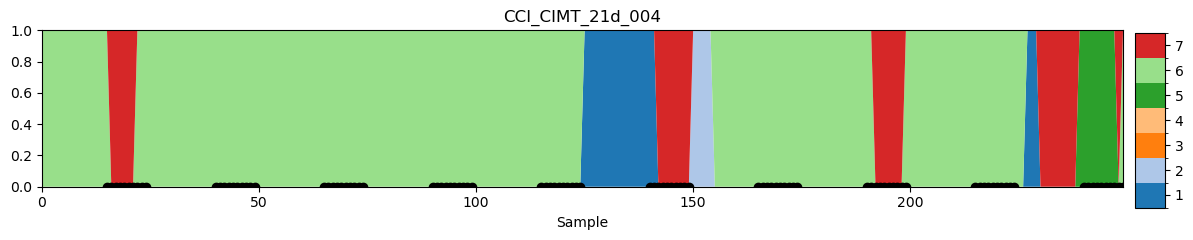

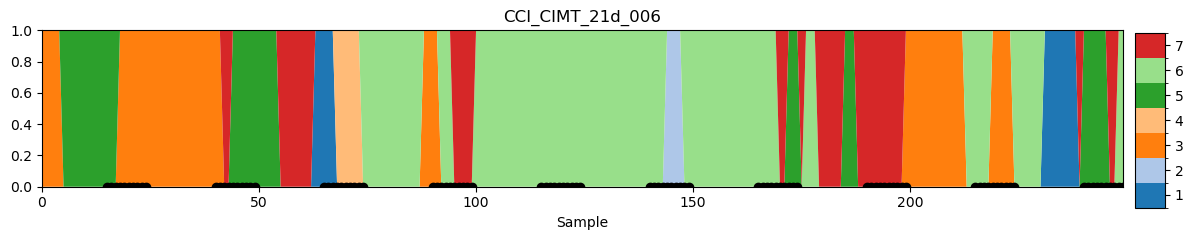

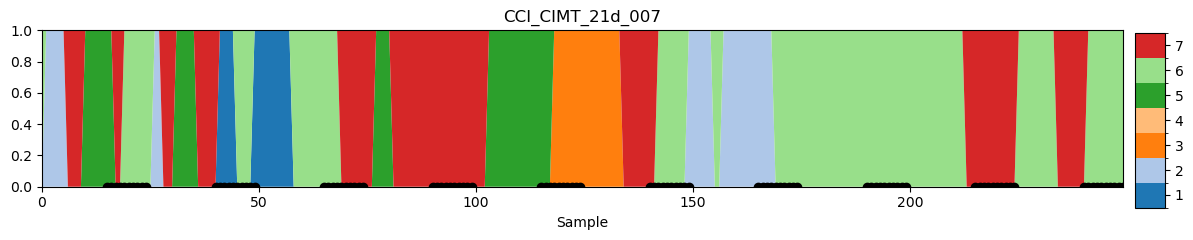

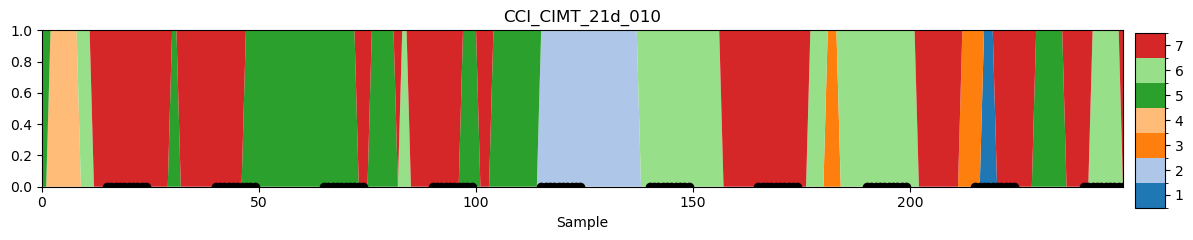

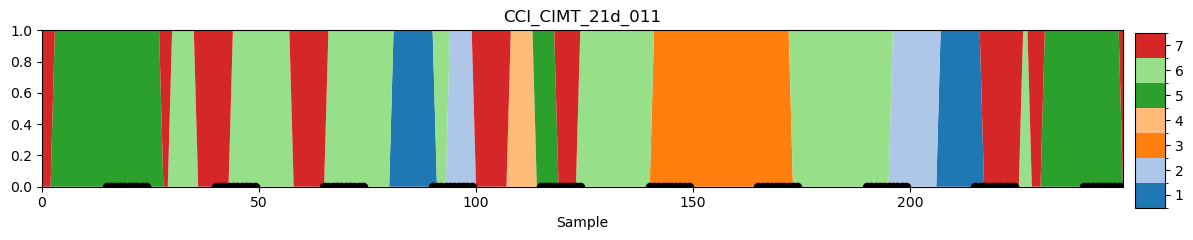

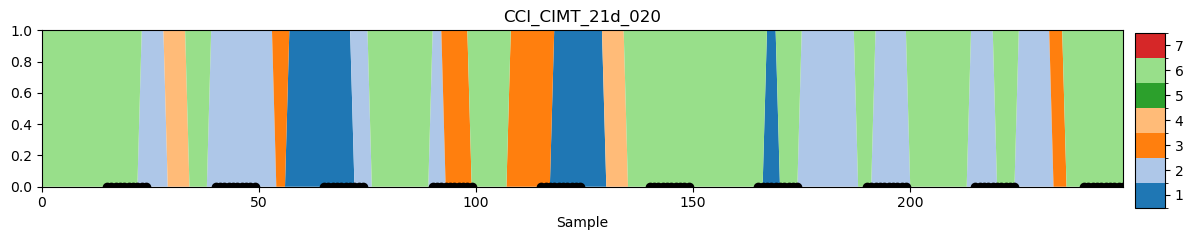

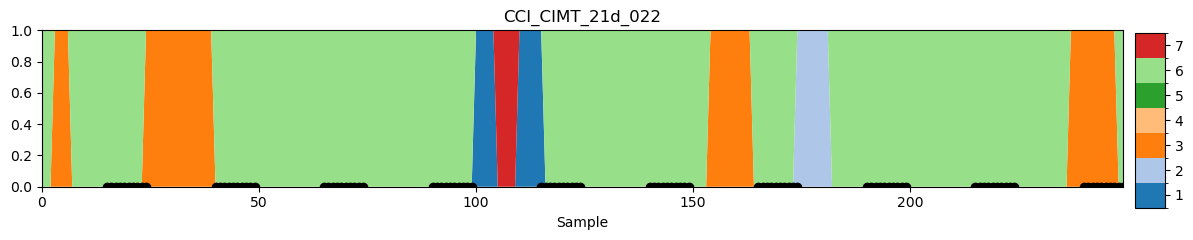

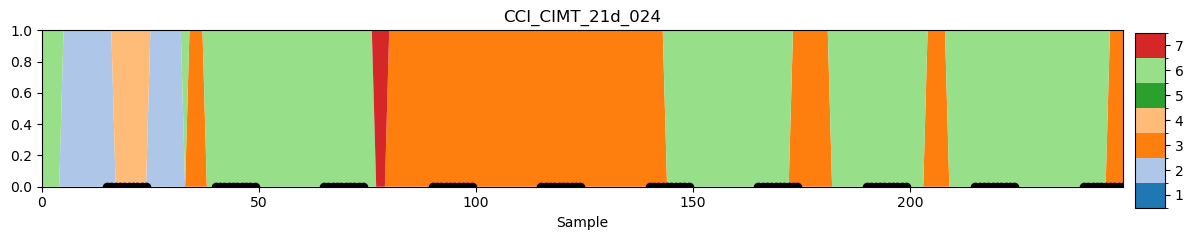

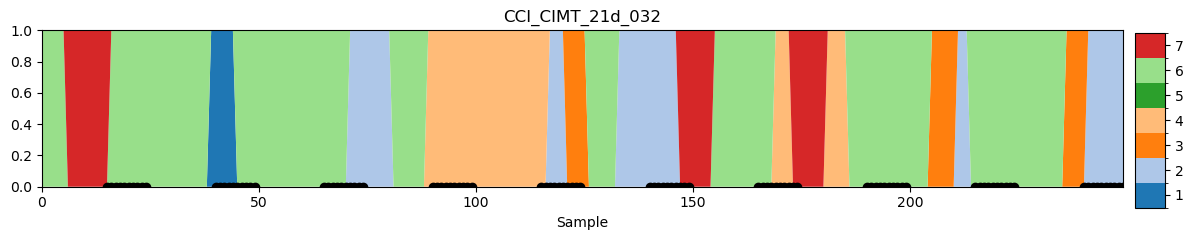

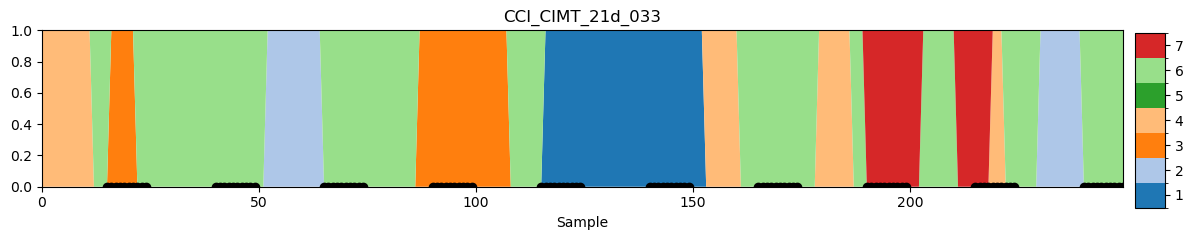

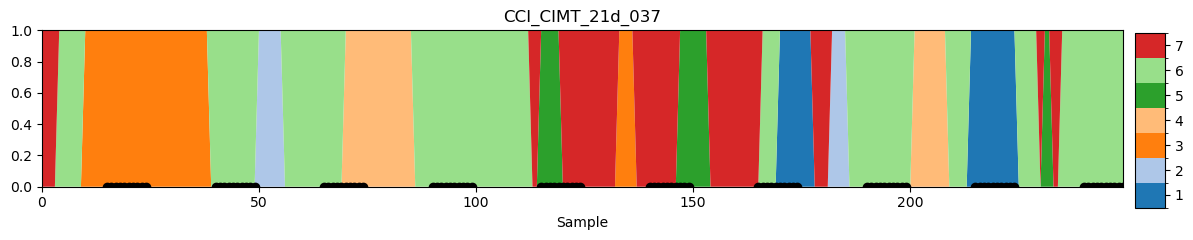

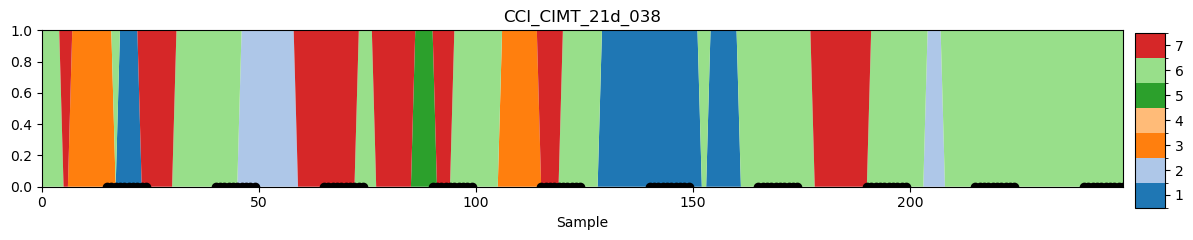

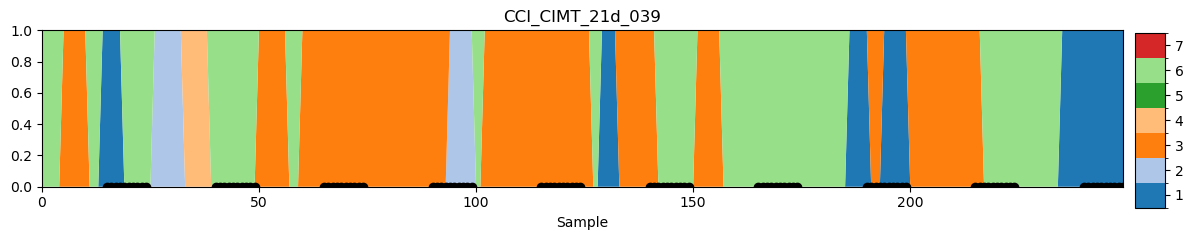

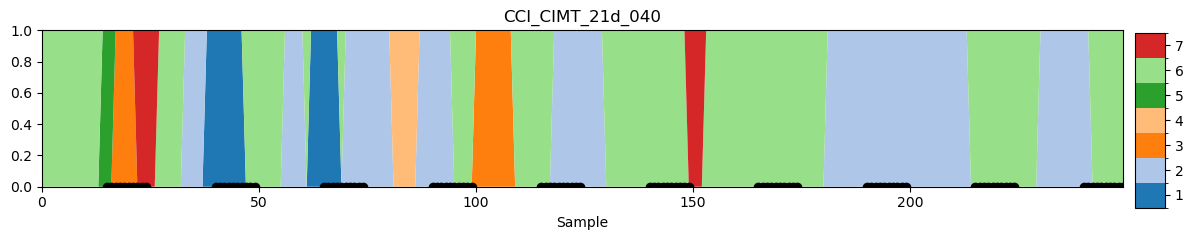

In [425]:
for subj in np.where(y == 'CCI_CIMT_21d')[0]:
    plot_state_time_course(subj_tc=stc[subj], n_samples=X.shape[1], cmap='tab20', title=str(subj_order[subj][-17:]), stim_times=stim_times if stim_times else None)

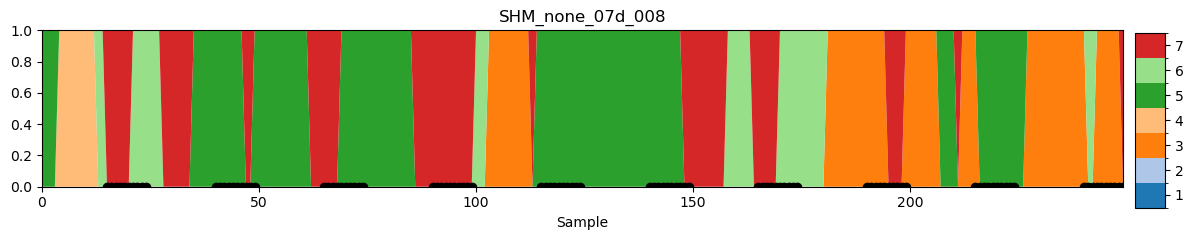

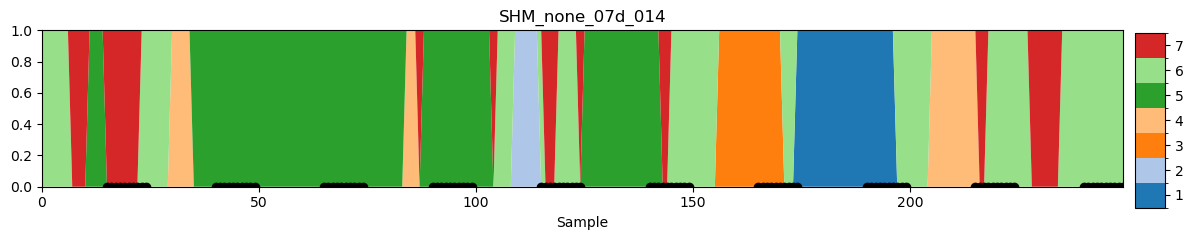

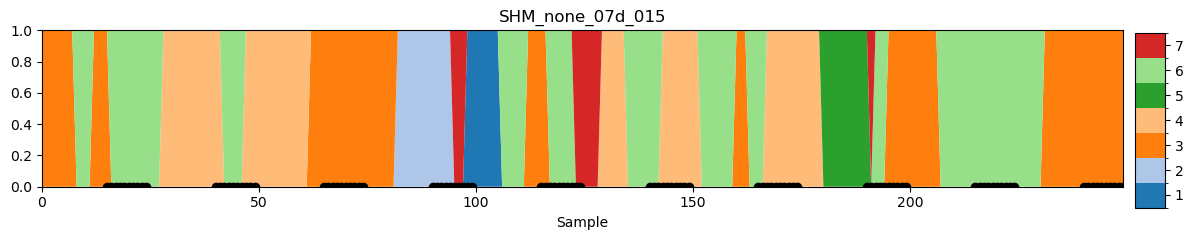

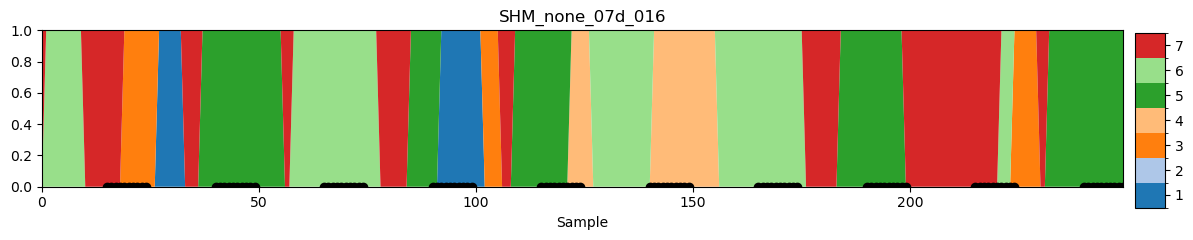

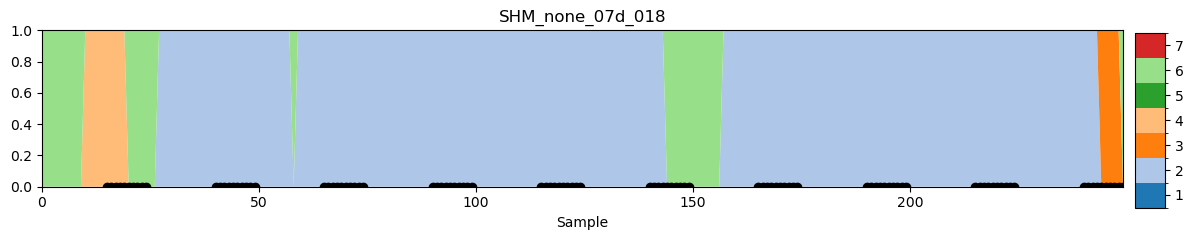

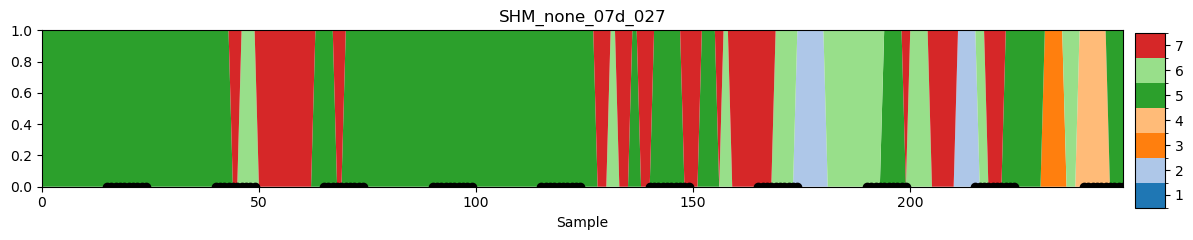

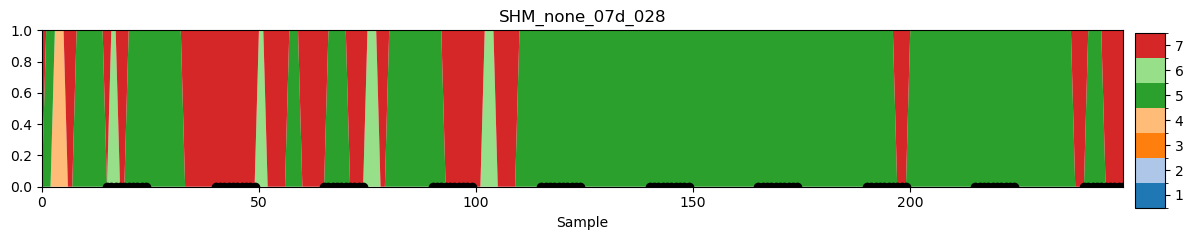

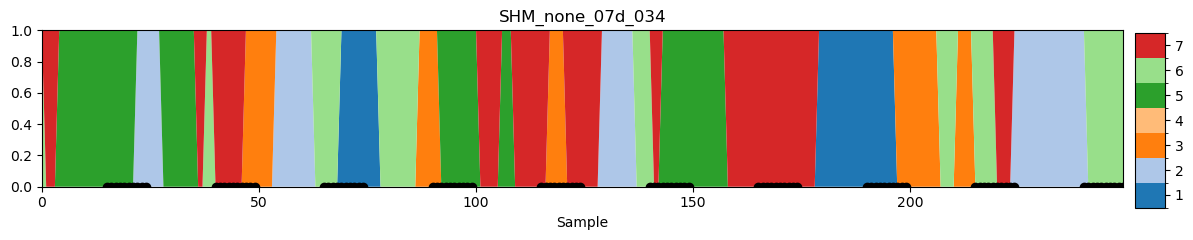

In [426]:
for subj in np.where(y == 'SHM_none_07d')[0]:
    plot_state_time_course(subj_tc=stc[subj], n_samples=X.shape[1], cmap='tab20', title=str(subj_order[subj][-17:]), stim_times=stim_times if stim_times else None)

### 21d

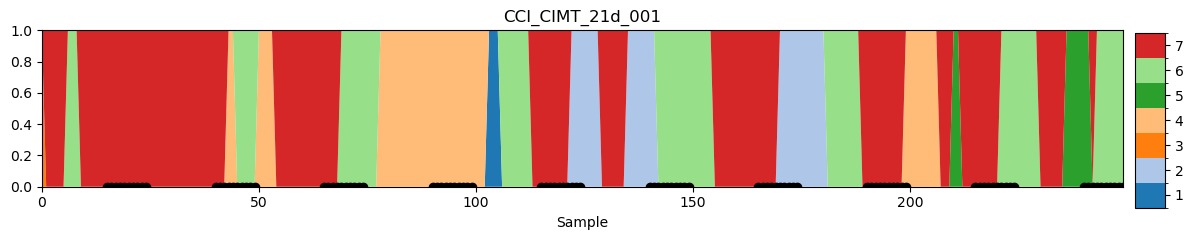

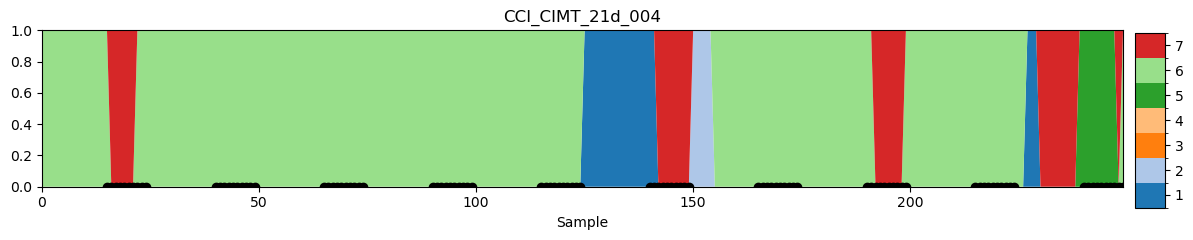

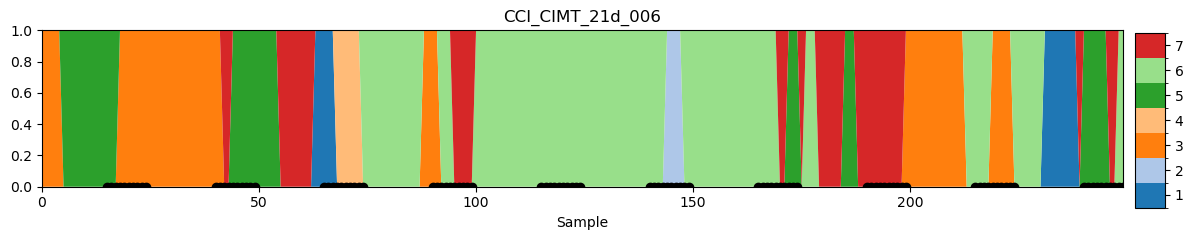

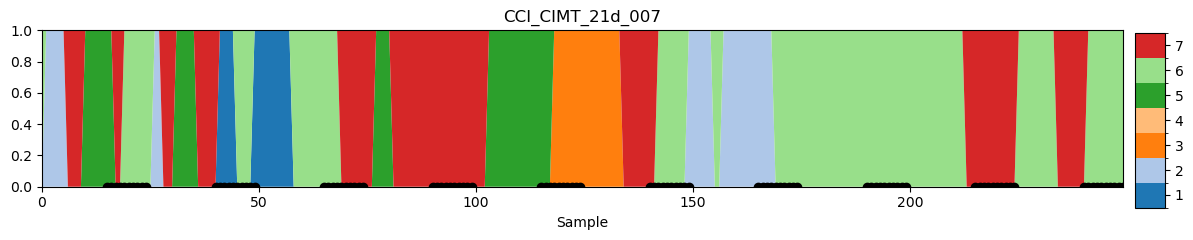

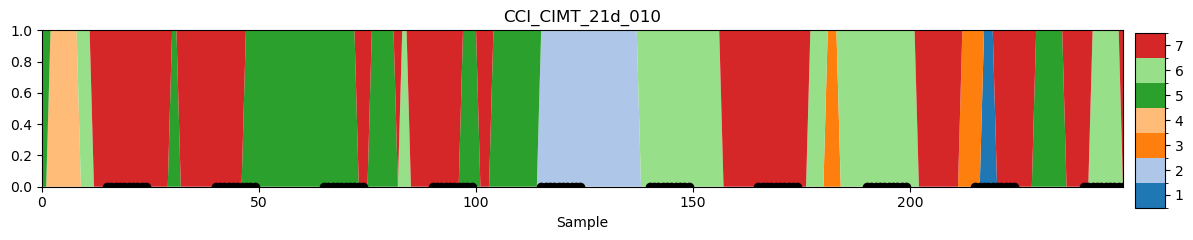

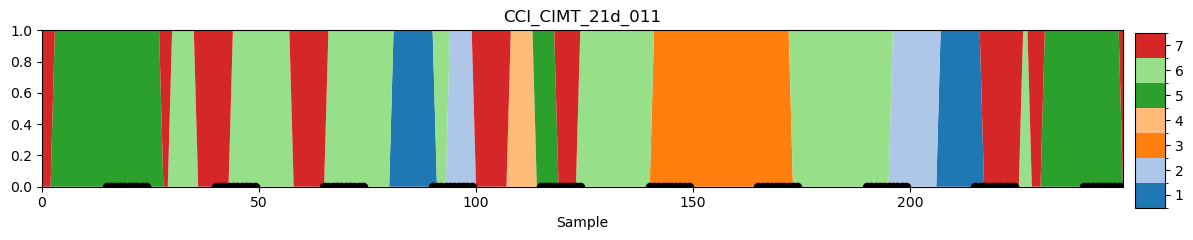

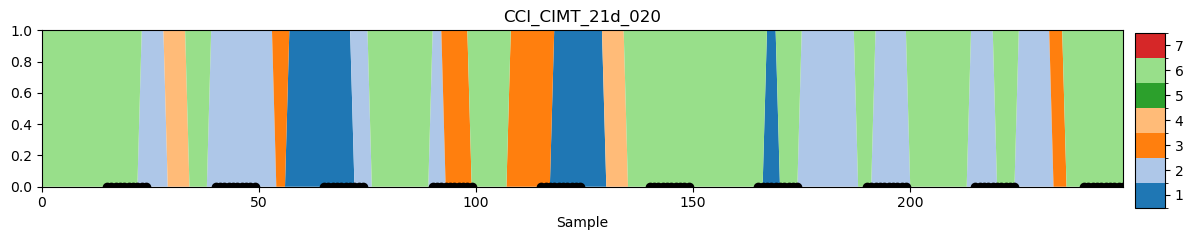

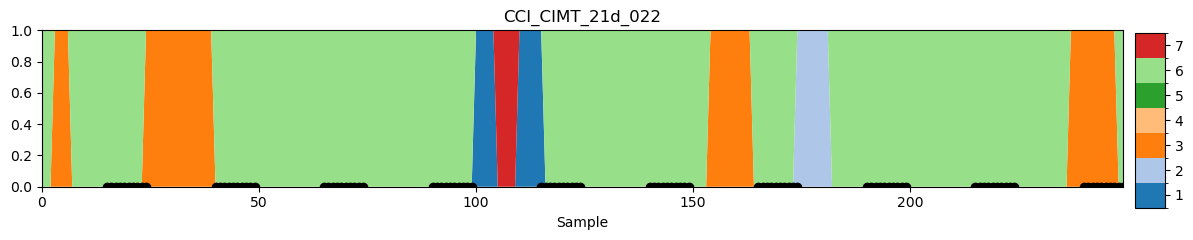

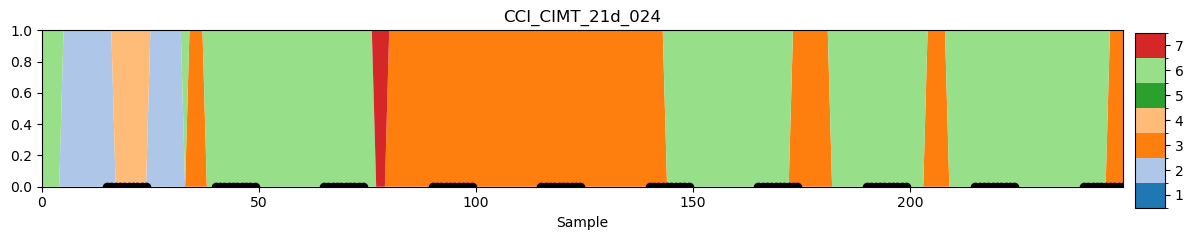

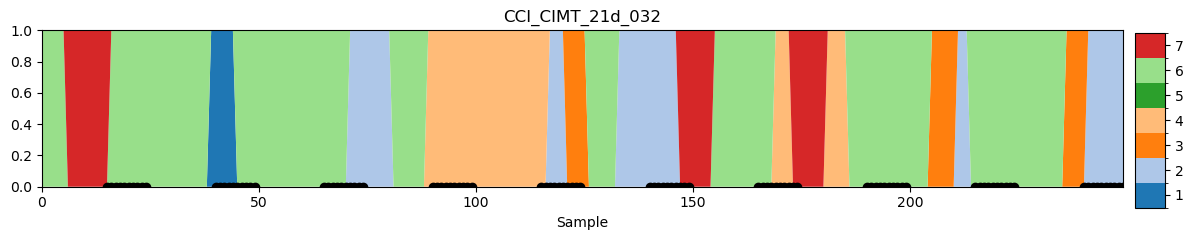

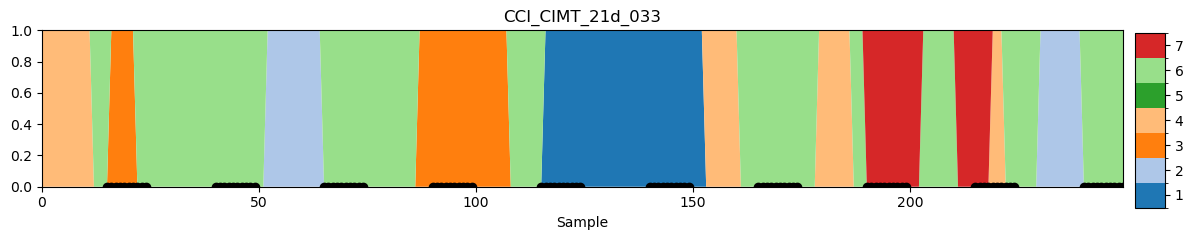

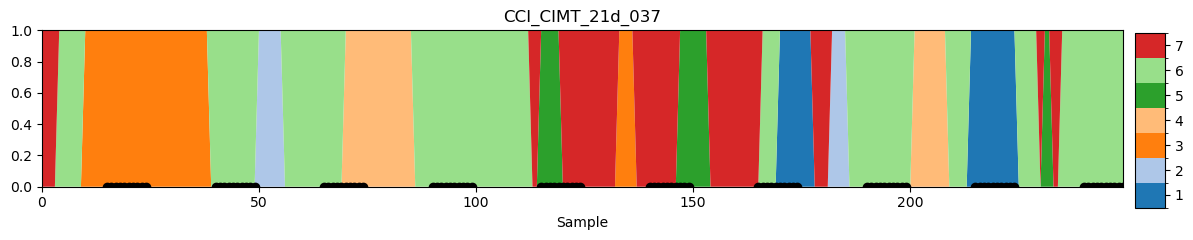

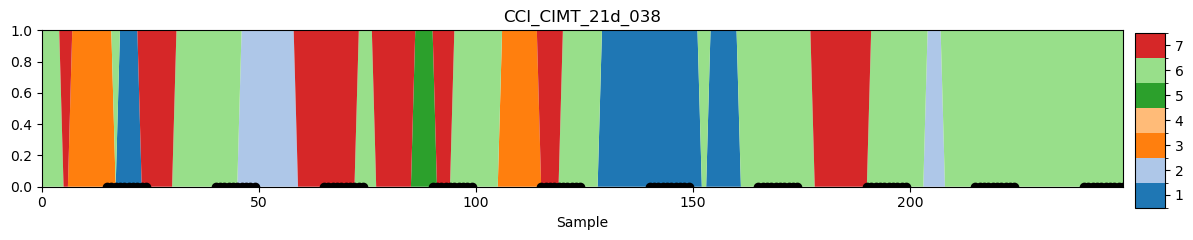

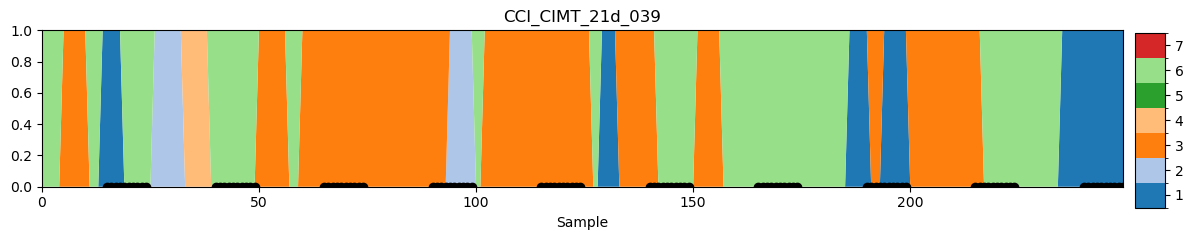

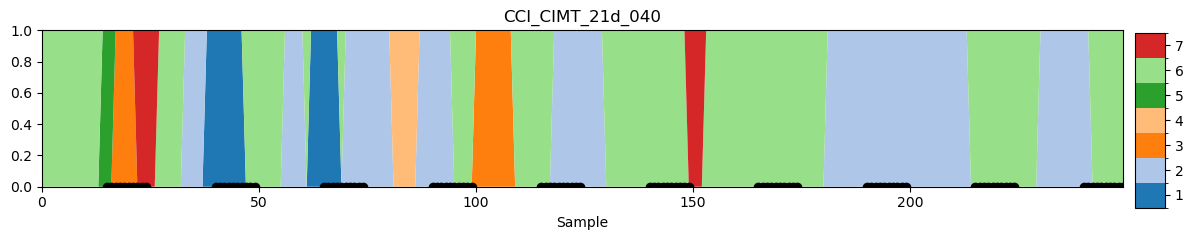

In [427]:
for subj in np.where(y == 'CCI_CIMT_21d')[0]:
    plot_state_time_course(subj_tc=stc[subj], n_samples=X.shape[1], cmap='tab20', title=str(subj_order[subj][-17:]), stim_times=stim_times if stim_times else None)

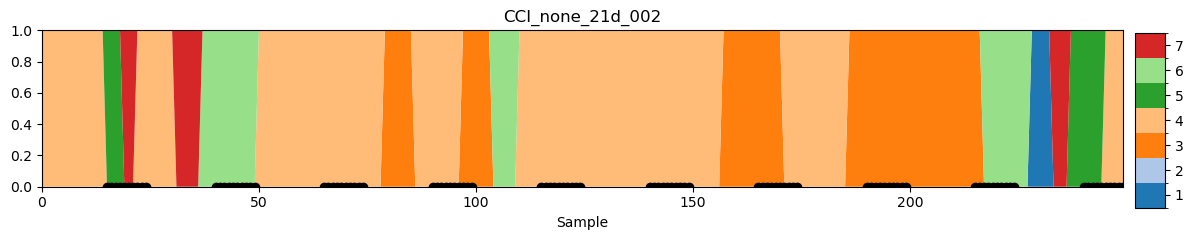

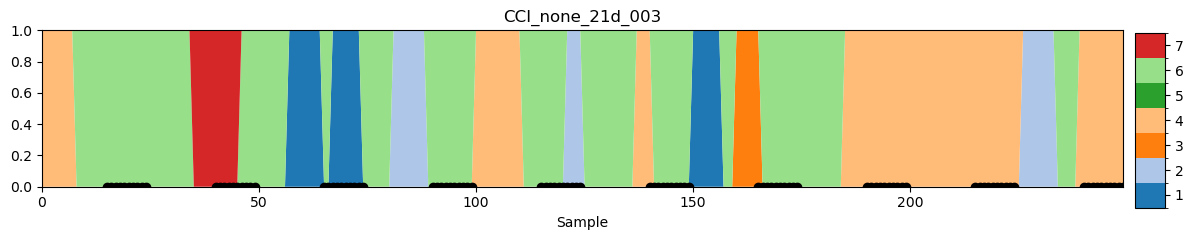

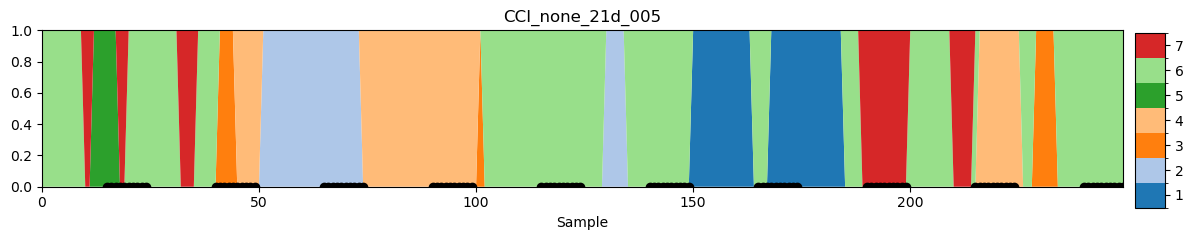

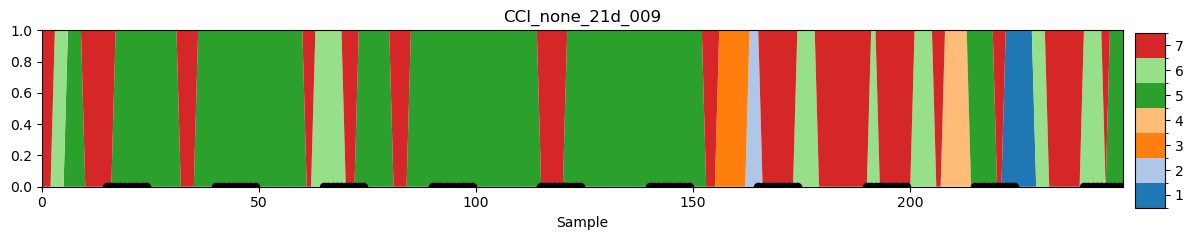

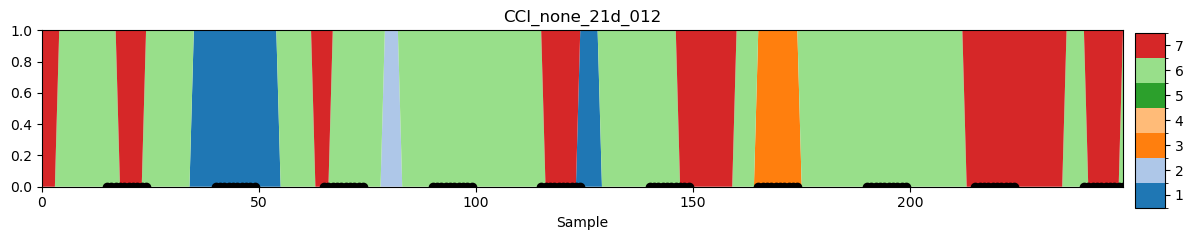

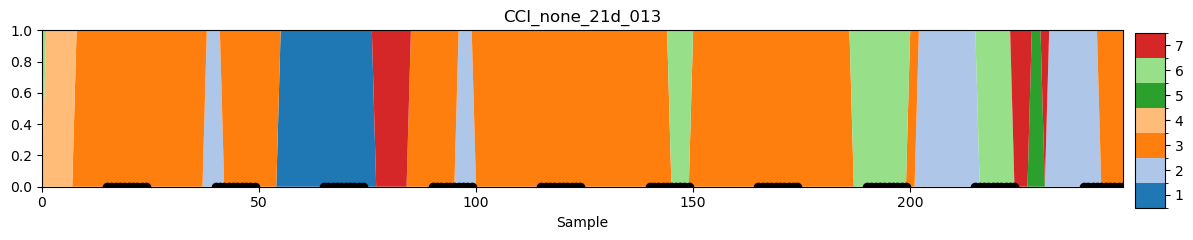

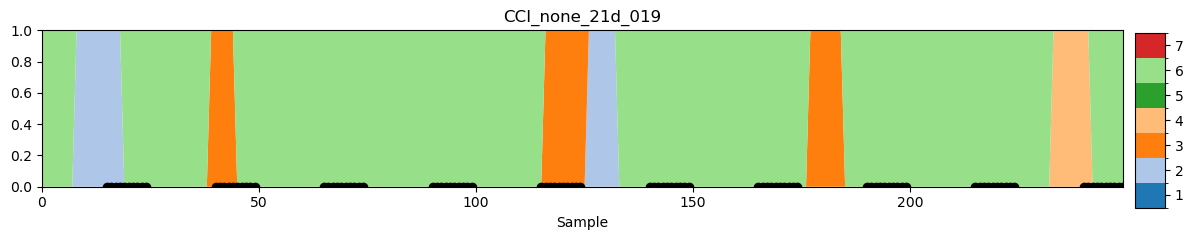

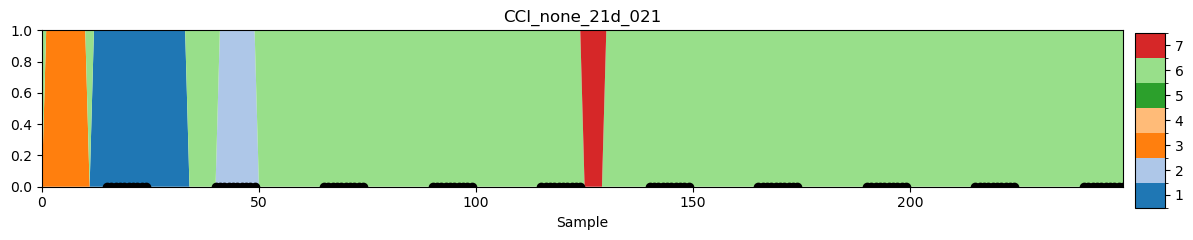

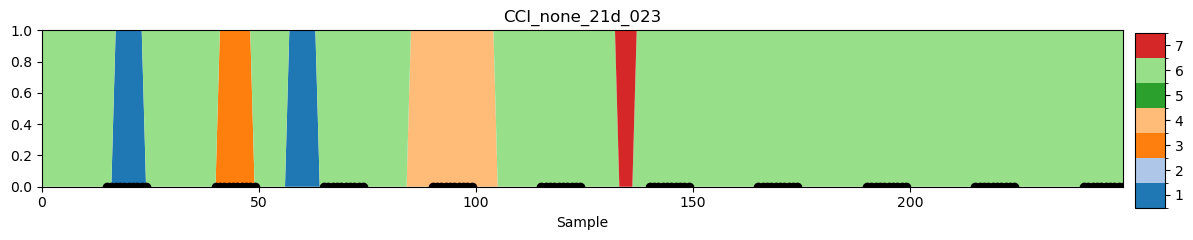

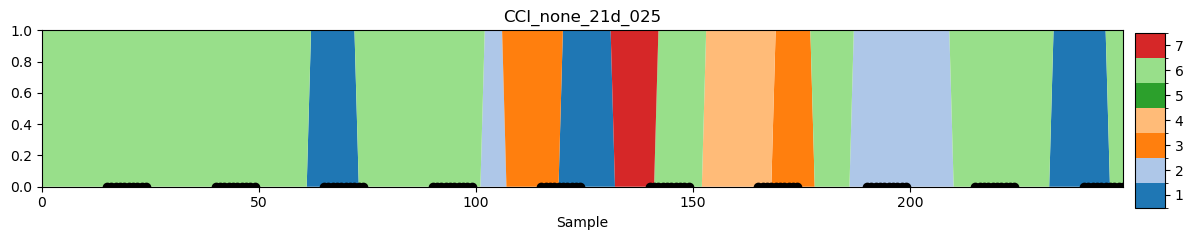

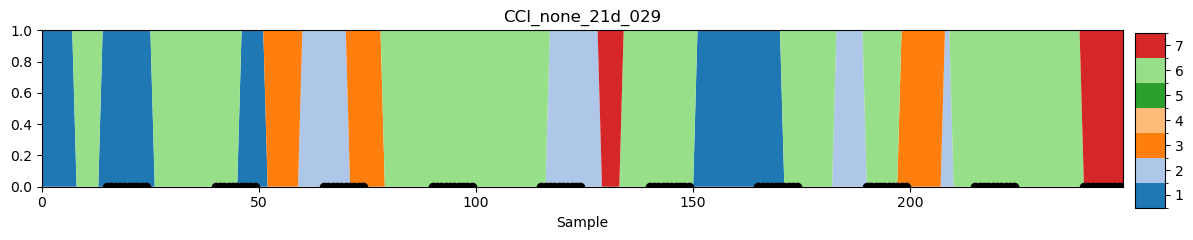

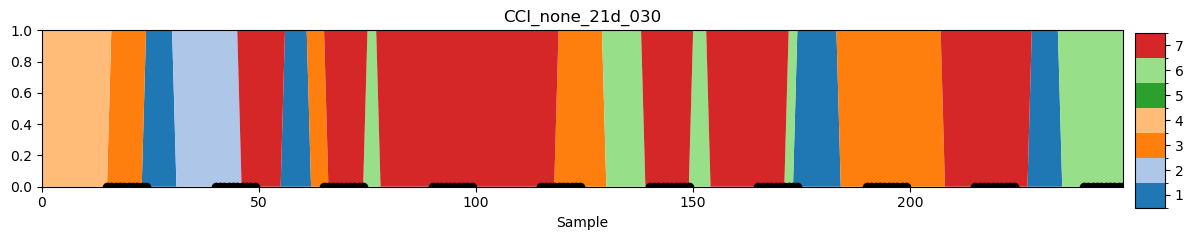

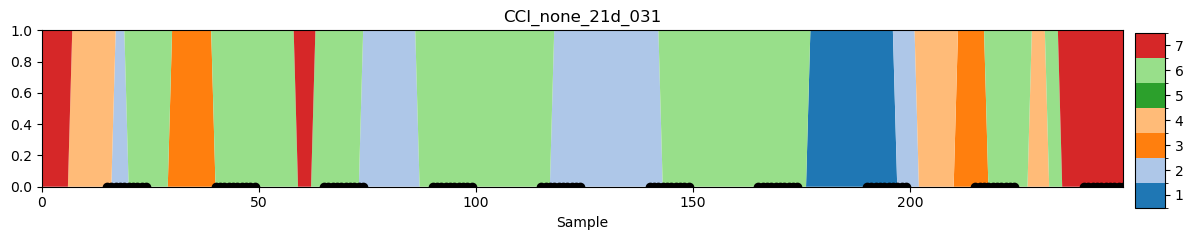

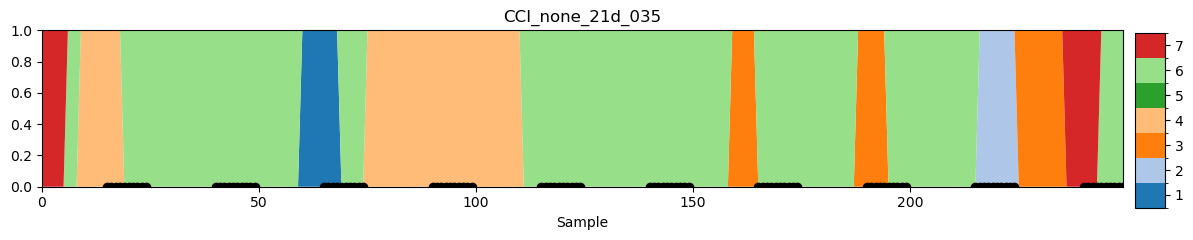

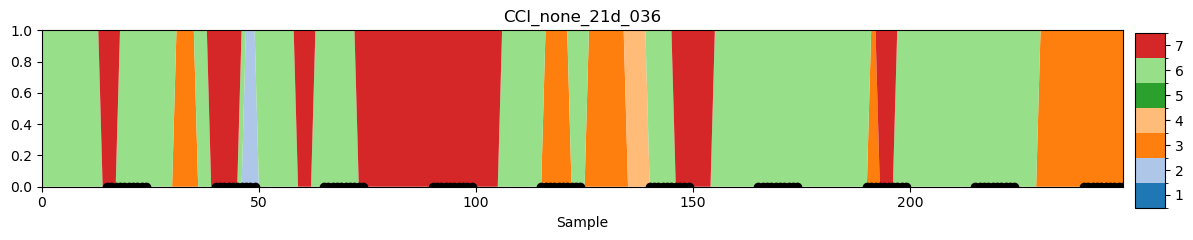

In [428]:
for subj in np.where(y == 'CCI_none_21d')[0]:
    plot_state_time_course(subj_tc=stc[subj], n_samples=X.shape[1], cmap='tab20', title=str(subj_order[subj][-17:]), stim_times=stim_times if stim_times else None)

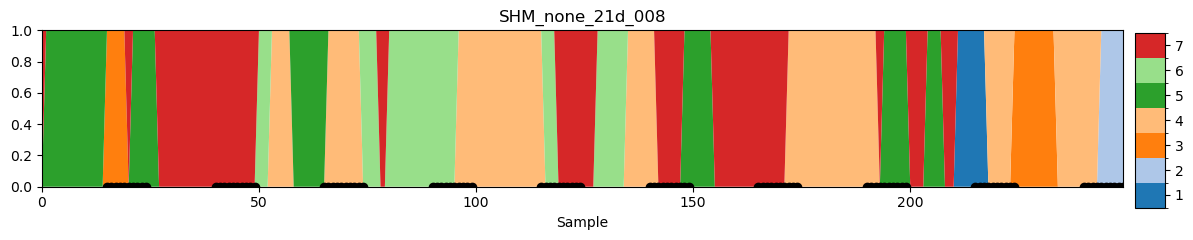

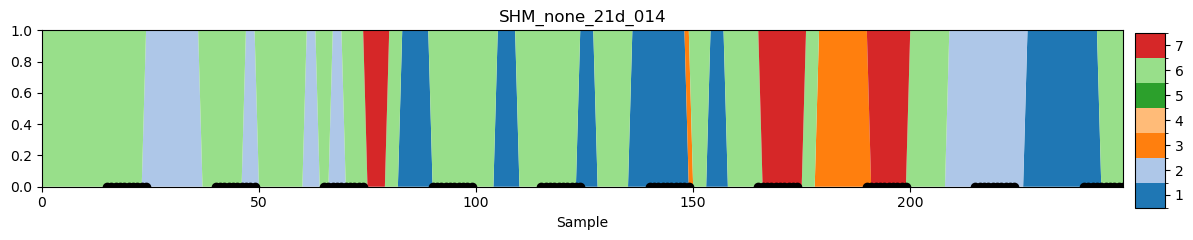

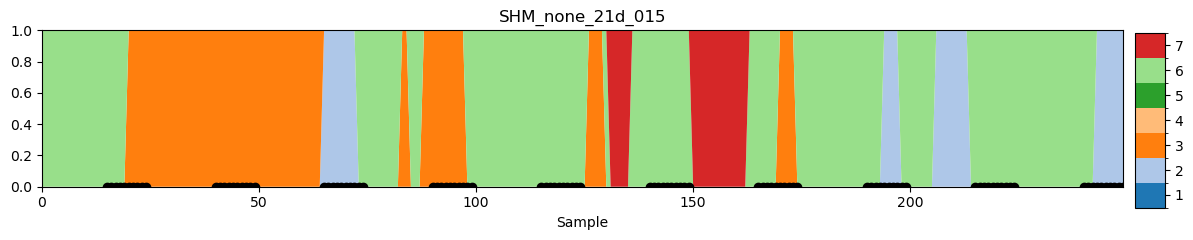

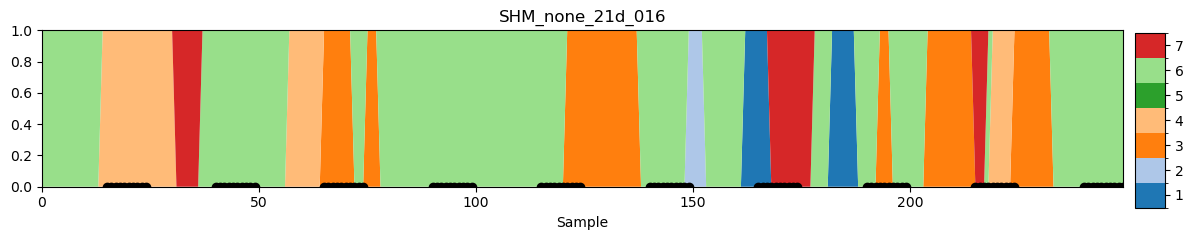

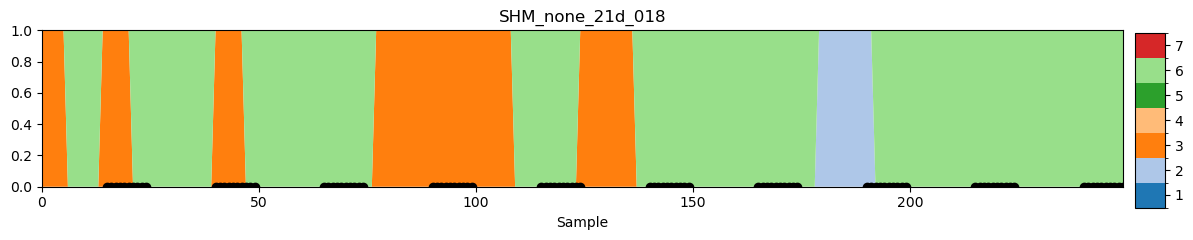

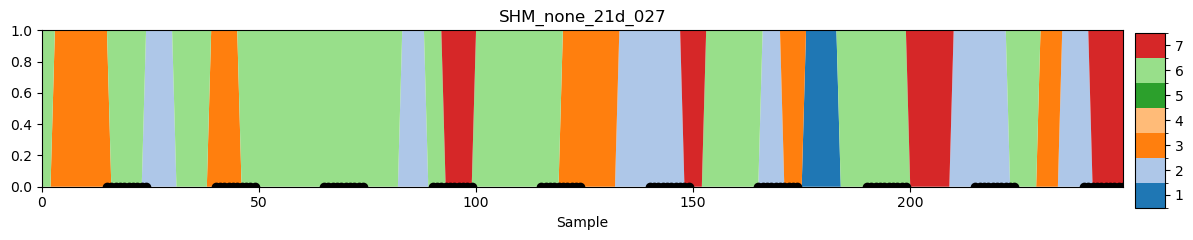

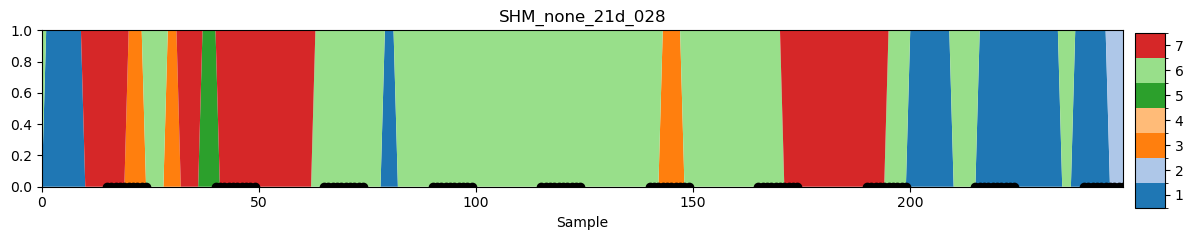

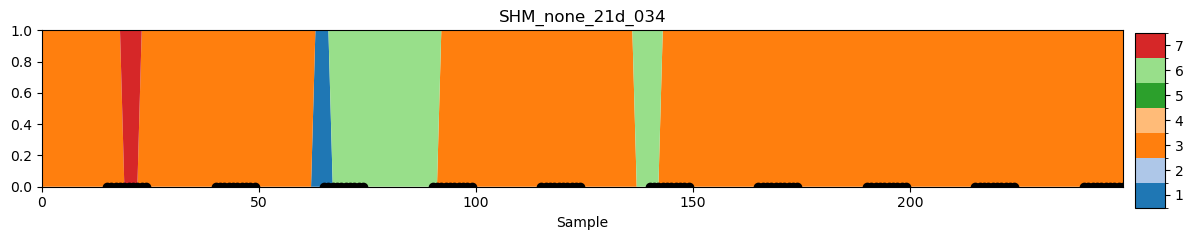

In [429]:
for subj in np.where(y == 'SHM_none_21d')[0]:
    plot_state_time_course(subj_tc=stc[subj], n_samples=X.shape[1], cmap='tab20', title=str(subj_order[subj][-17:]), stim_times=stim_times if stim_times else None)

### 49d

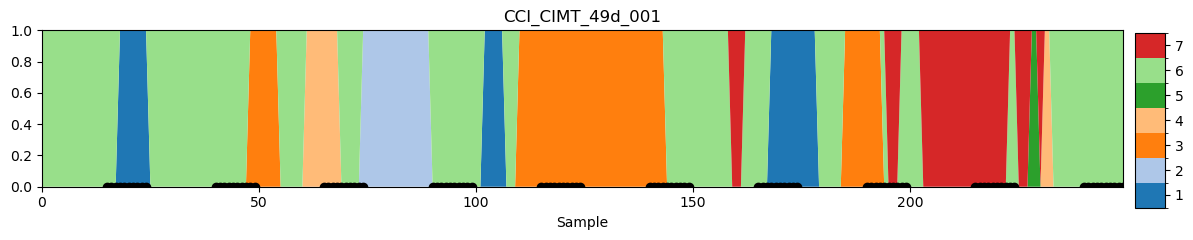

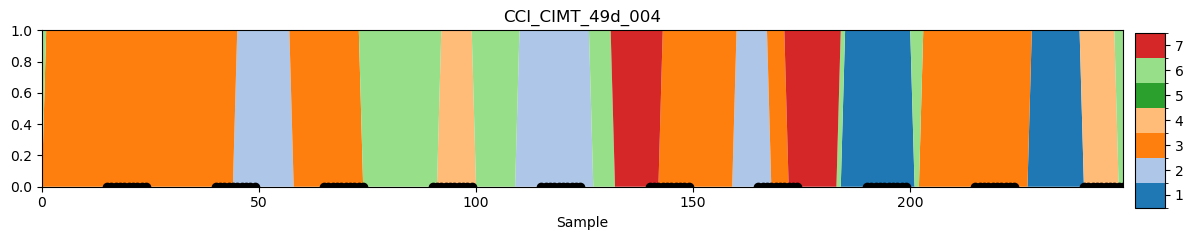

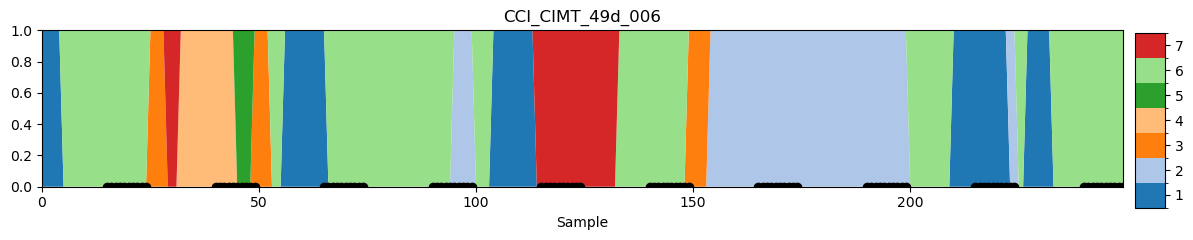

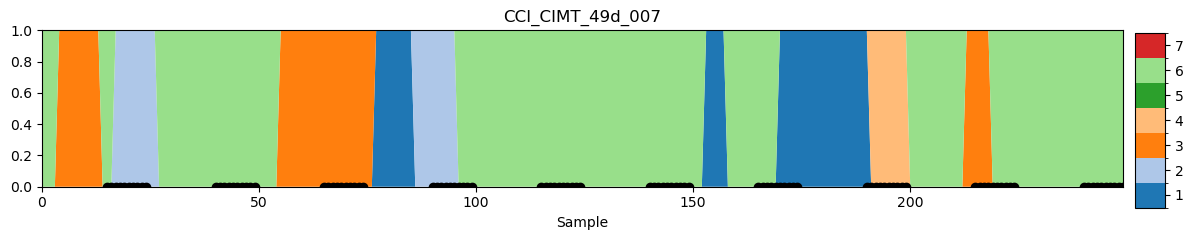

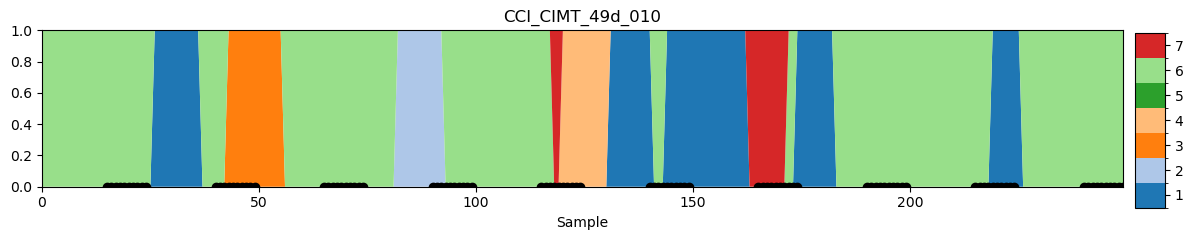

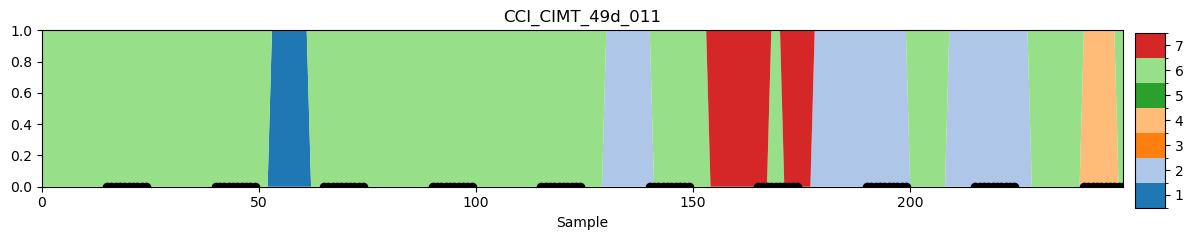

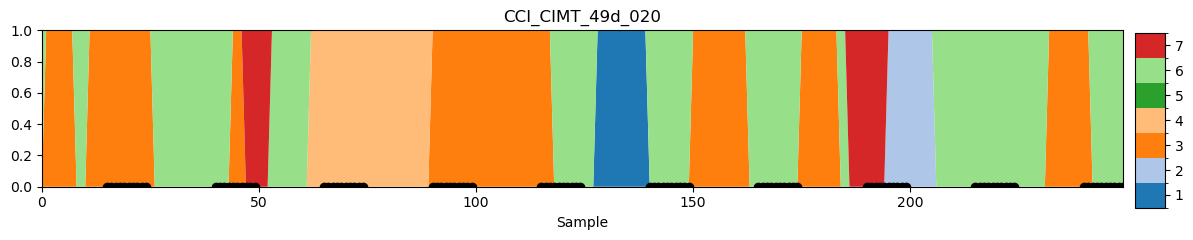

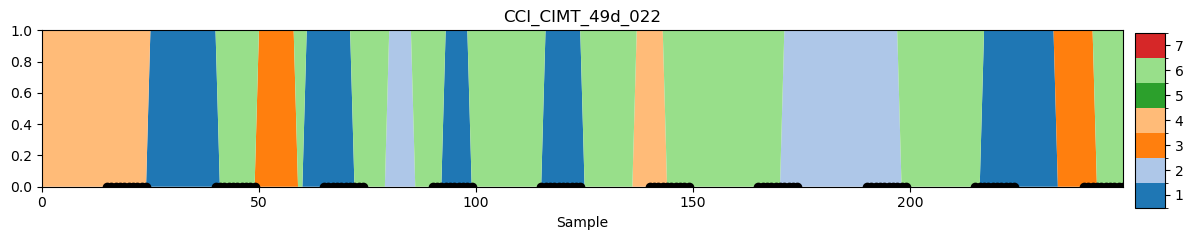

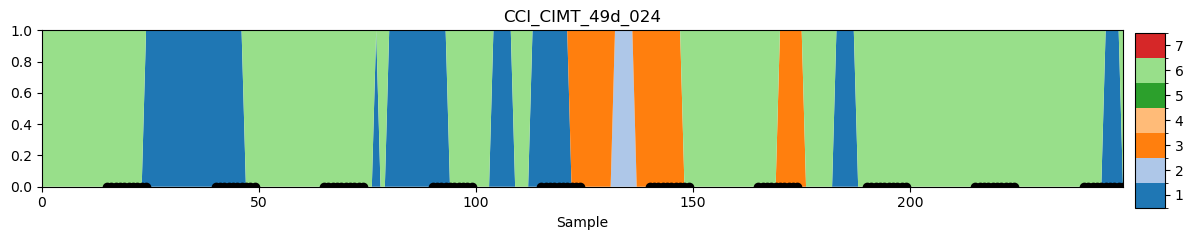

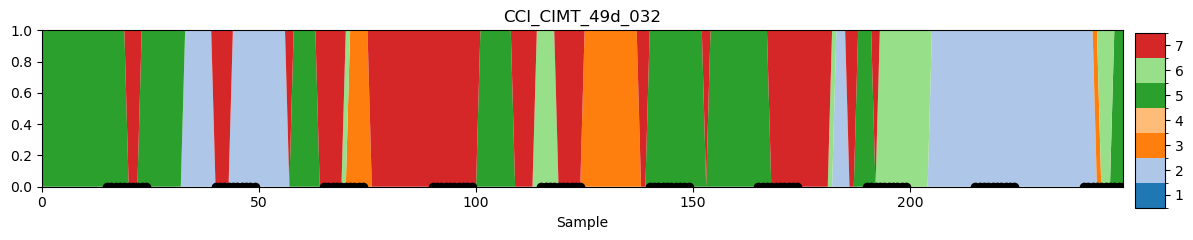

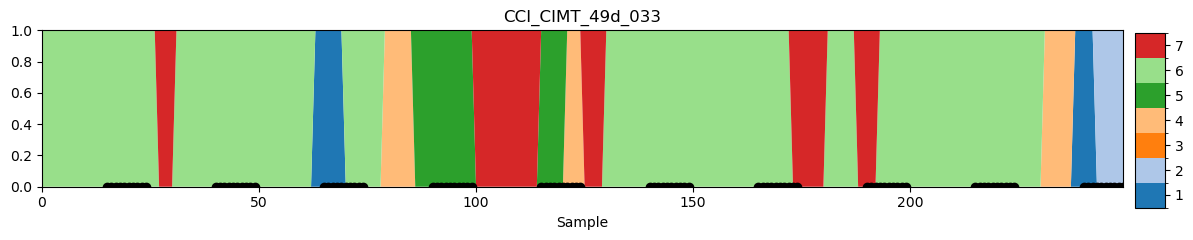

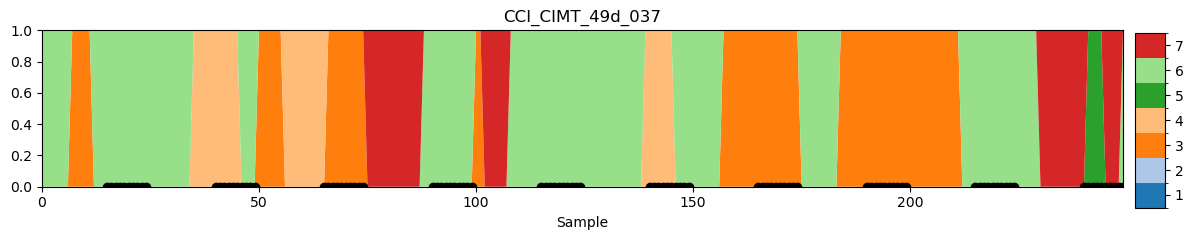

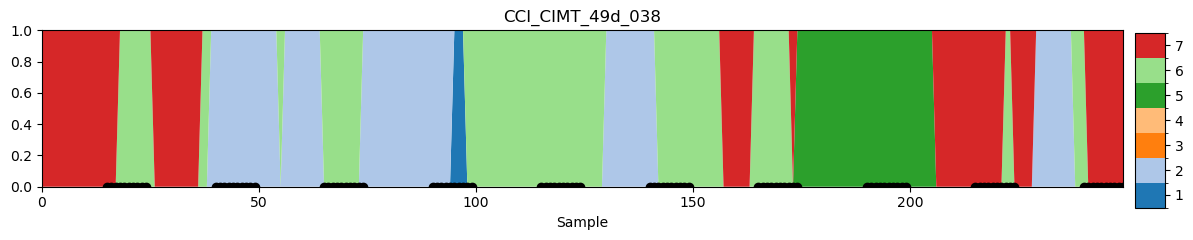

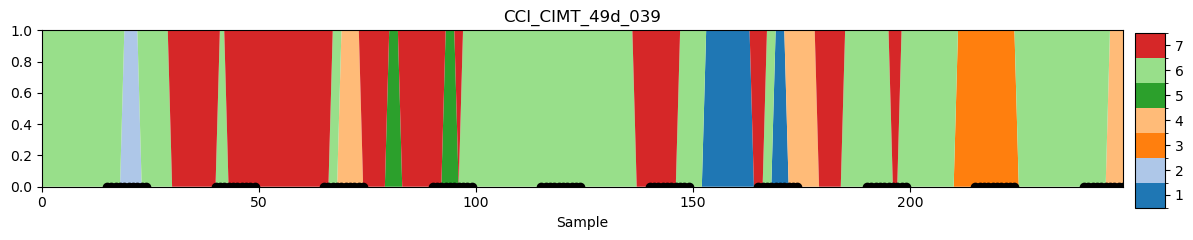

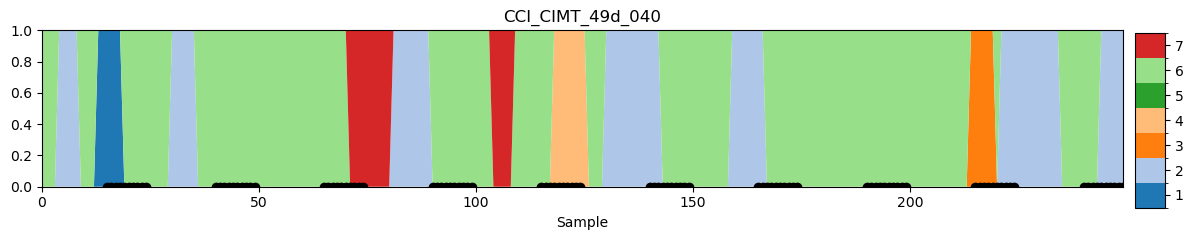

In [430]:
for subj in np.where(y == 'CCI_CIMT_49d')[0]:
    plot_state_time_course(subj_tc=stc[subj], n_samples=X.shape[1], cmap='tab20', title=str(subj_order[subj][-17:]), stim_times=stim_times if stim_times else None)

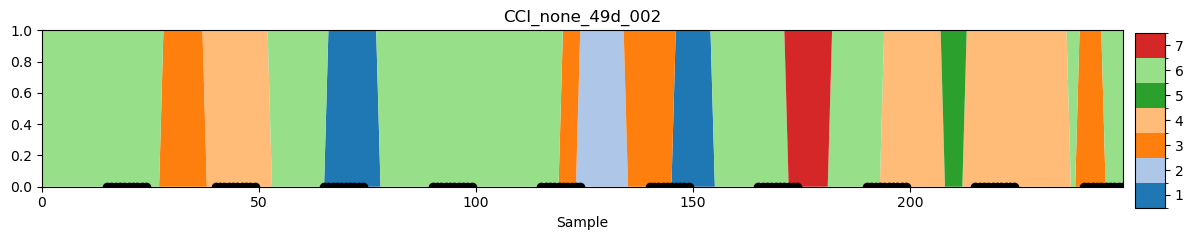

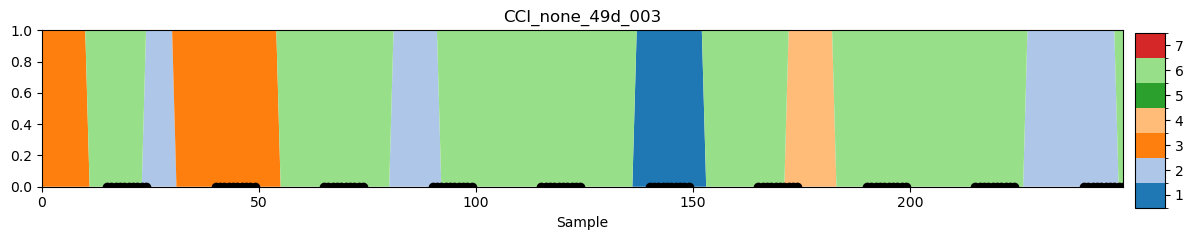

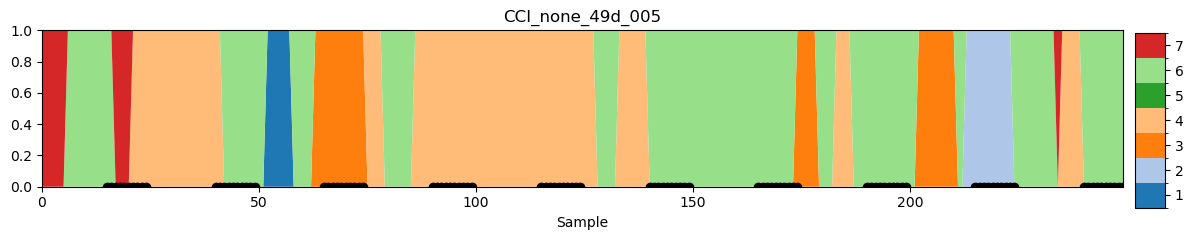

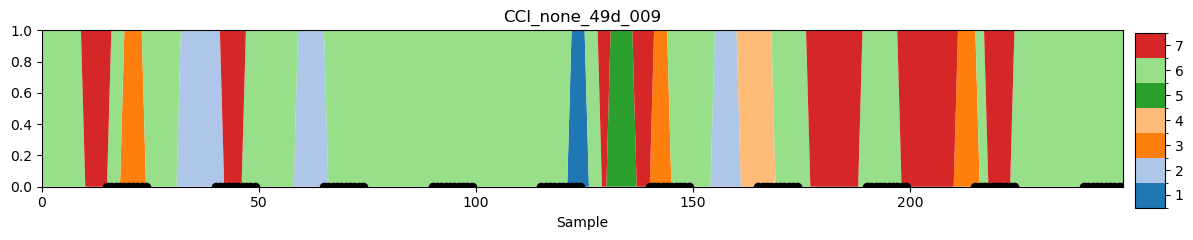

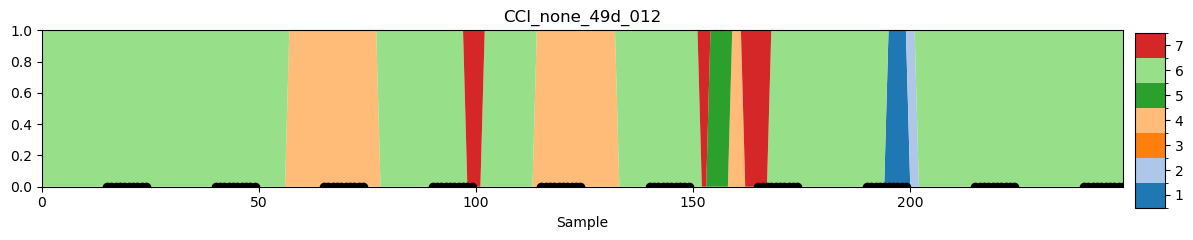

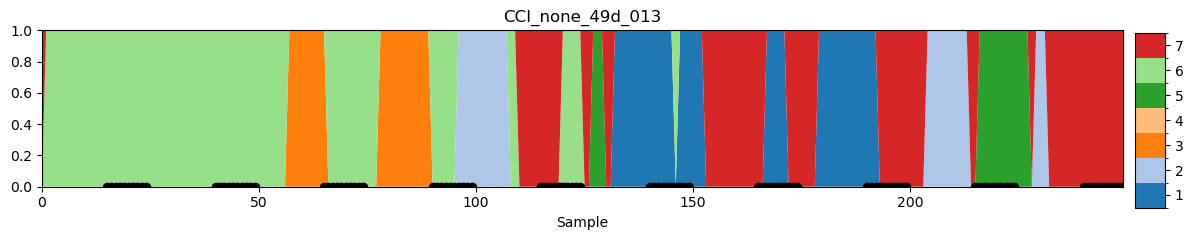

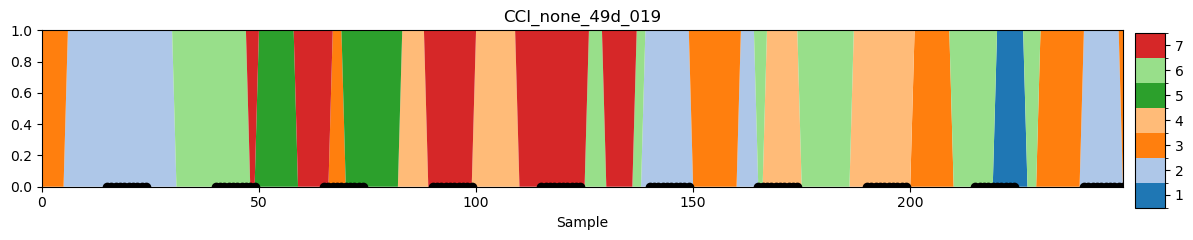

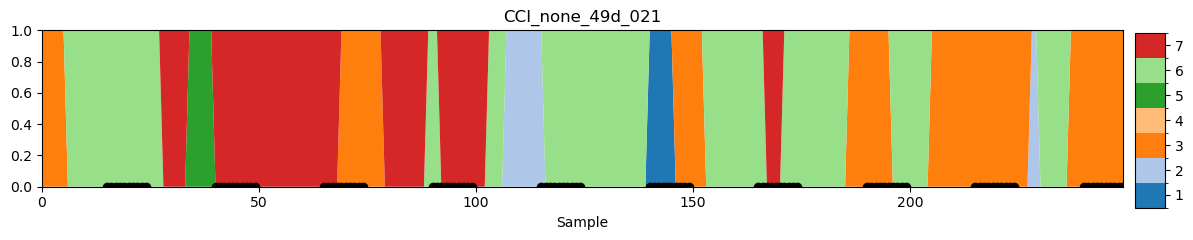

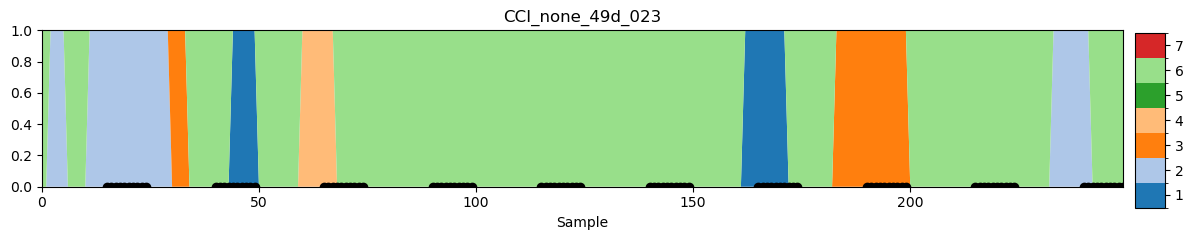

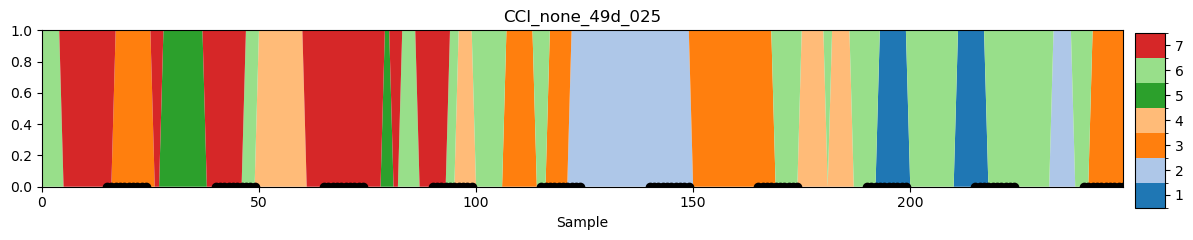

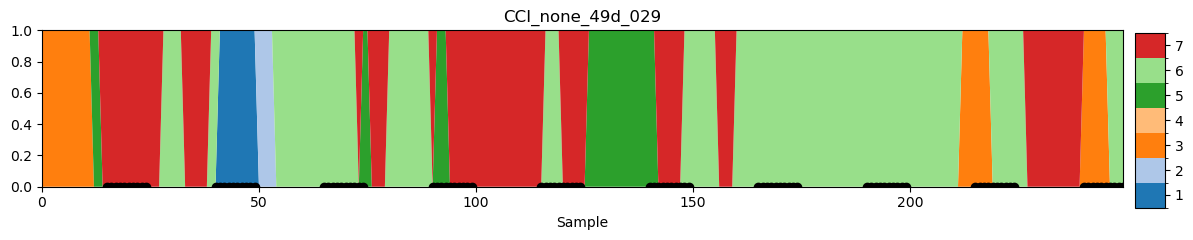

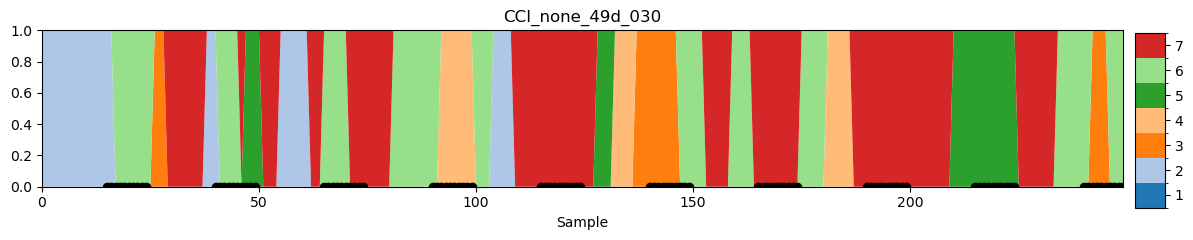

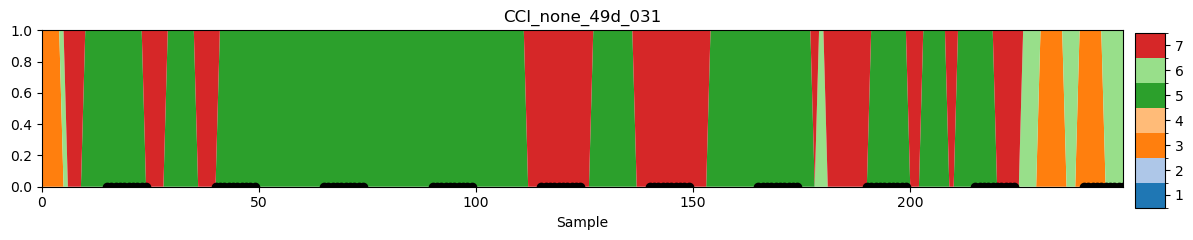

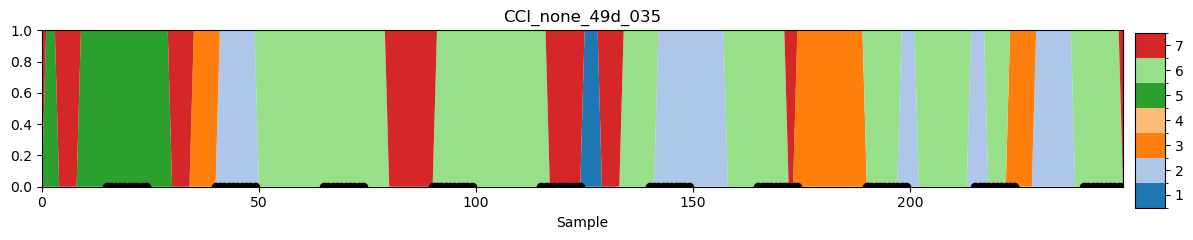

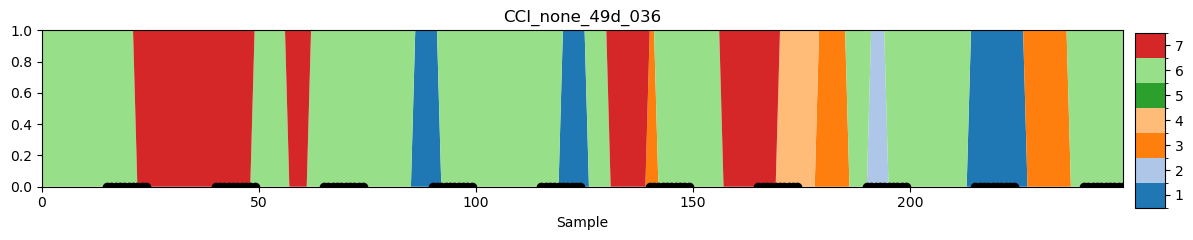

In [431]:
for subj in np.where(y == 'CCI_none_49d')[0]:
    plot_state_time_course(subj_tc=stc[subj], n_samples=X.shape[1], cmap='tab20', title=str(subj_order[subj][-17:]), stim_times=stim_times if stim_times else None)

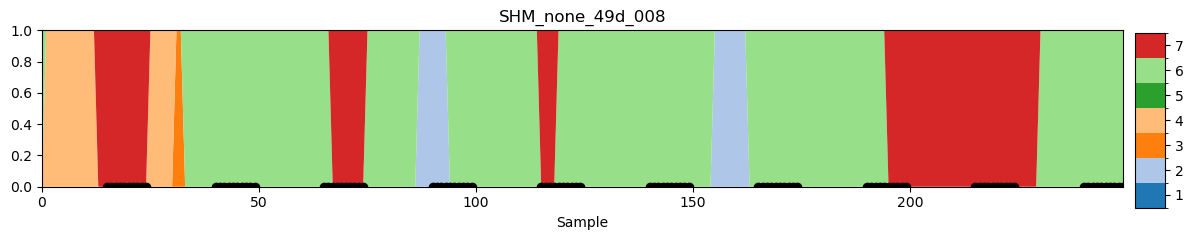

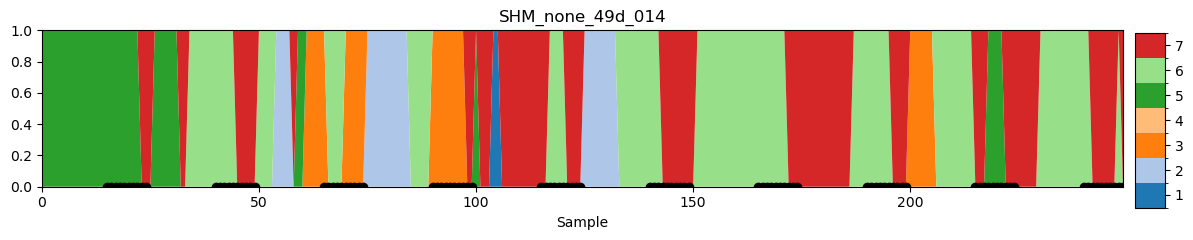

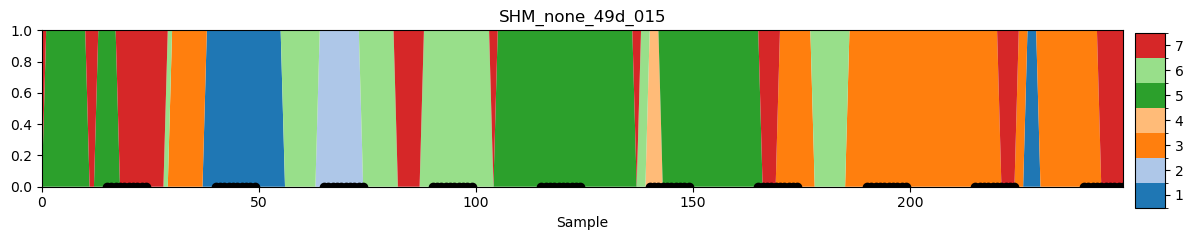

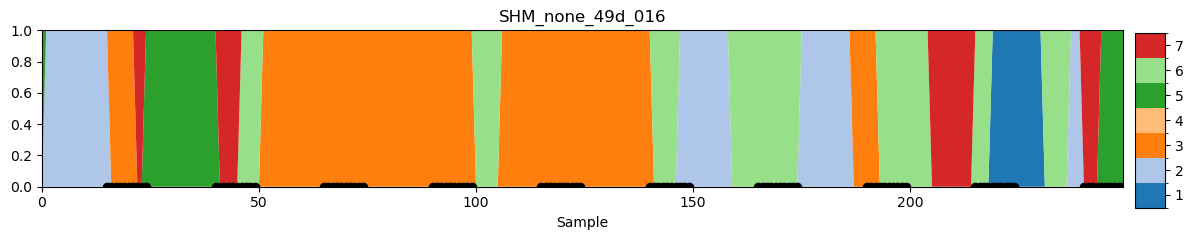

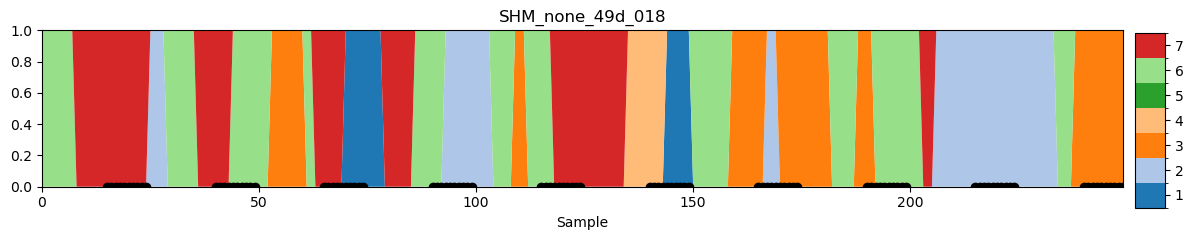

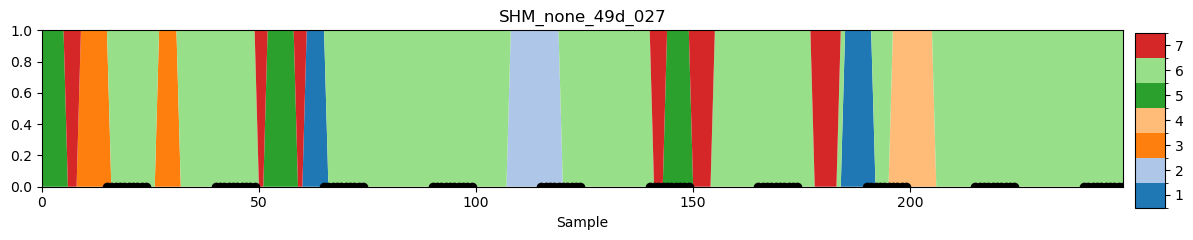

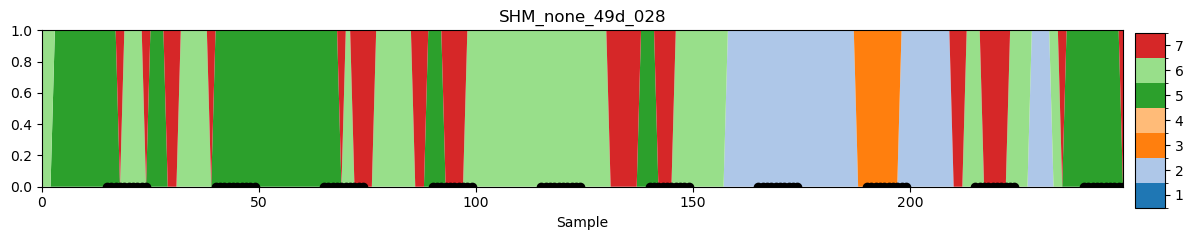

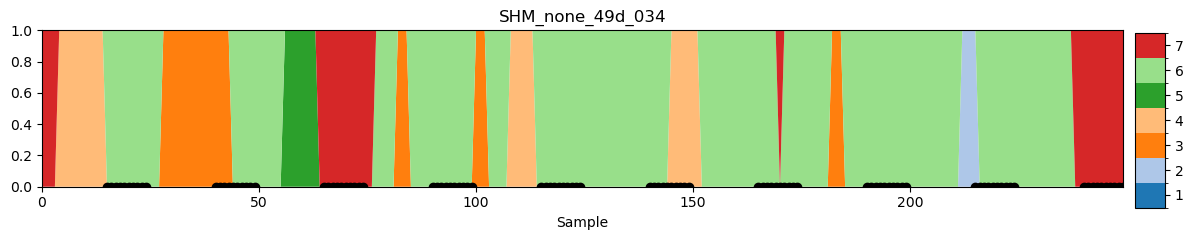

In [432]:
for subj in np.where(y == 'SHM_none_49d')[0]:
    plot_state_time_course(subj_tc=stc[subj], n_samples=X.shape[1], cmap='tab20', title=str(subj_order[subj][-17:]), stim_times=stim_times if stim_times else None)

## Overall Mean State Lifetimes, Intervals, and Switching Rates

[19.19273183 16.83600668 19.06461988 18.70597327 19.63667502 19.61746032
 13.89771018 16.46679198]


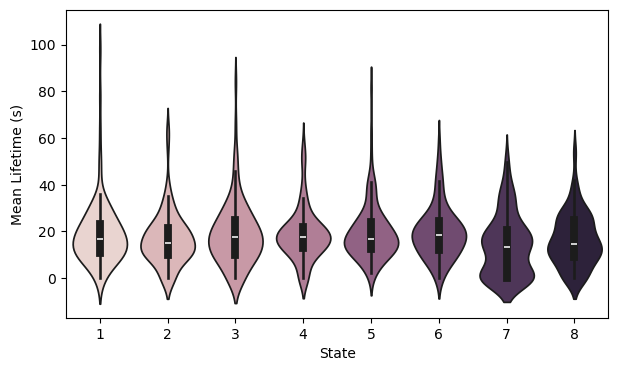

In [157]:
# Calculate mean lifetimes (in seconds)
lt = modes.mean_lifetimes(stc, sampling_frequency=1/2) # TR = 2 s, so sampling_frequency = 1 sample per 2 seconds

# # Convert to ms
# lt *= 1000

# Print the group average
print(np.mean(lt, axis=0))

# Plot distribution across subjects
fig, ax = plotting.plot_violin(lt.T, x_label="State", y_label="Mean Lifetime (s)")

[106.51988304  87.68174603  79.63070175  88.63897243  82.52778031
  74.12030075  47.69564188  71.85630744]


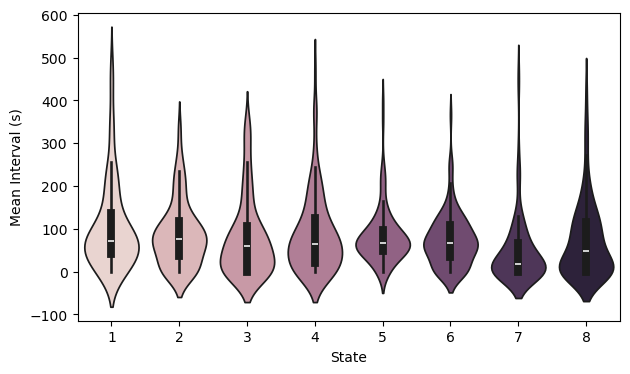

In [158]:
# Calculate mean intervals (in seconds). An interval is the duration between successive visits for a particular state
intv = modes.mean_intervals(stc, sampling_frequency=1/2)

# Print the group average
print(np.mean(intv, axis=0))

# Plot distribution across subjects
fig, ax = plotting.plot_violin(intv.T, x_label="State", y_label="Mean Interval (s)")

[0.00631579 0.00591228 0.00492982 0.00540351 0.00833333 0.00682456
 0.00517544 0.00438596]


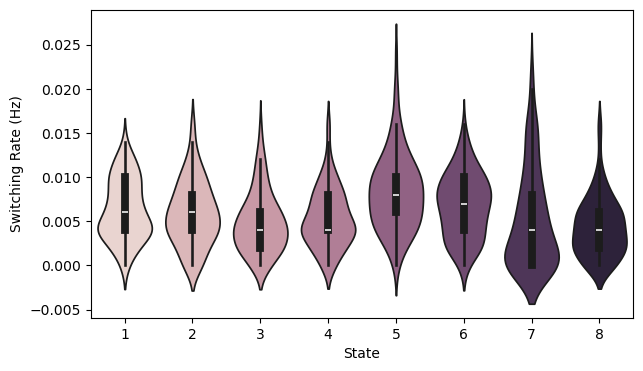

In [159]:
# Calculate the switching rate (Hz). This is defined as the number of state activations per second.
sr = modes.switching_rates(stc, sampling_frequency=1/2)

# Print the group average
print(np.mean(sr, axis=0))

# Plot distribution across subjects
fig, ax = plotting.plot_violin(sr.T, x_label="State", y_label="Switching Rate (Hz)")

## Within-group FO

In [464]:
groups = {}

for group in np.unique(y):
    groups[group] = {}

In [465]:
def within_group_plotting_helper(metric, y_label):
    fig, ax = plt.subplots(1, 2, sharey=True, figsize=(20, 4))
    plotting.plot_violin(
        np.concatenate((groups['CCI_CIMT_07d'][metric], groups['CCI_none_07d'][metric]), axis=0).T, 
        x_label="State", 
        y_label=y_label, 
        title="injured_07d", 
        ax=ax[0]
    )
    plotting.plot_violin(groups['SHM_none_07d'][metric].T, x_label="State", y_label=y_label, title="SHM_none_07d", ax=ax[1])
    
    for PID in ['07d', '21d', '49d']:
        fig, ax = plt.subplots(1, 3, sharey=True, figsize=(20, 4))
        plotting.plot_violin(groups['CCI_CIMT_' + PID][metric].T, x_label="State", y_label=y_label, title="CCI_CIMT_" + PID, ax=ax[0])
        plotting.plot_violin(groups['CCI_none_' + PID][metric].T, x_label="State", y_label=y_label, title="CCI_none_" + PID, ax=ax[1])
        plotting.plot_violin(groups['SHM_none_' + PID][metric].T, x_label="State", y_label=y_label, title="SHM_none_" + PID, ax=ax[2])

True


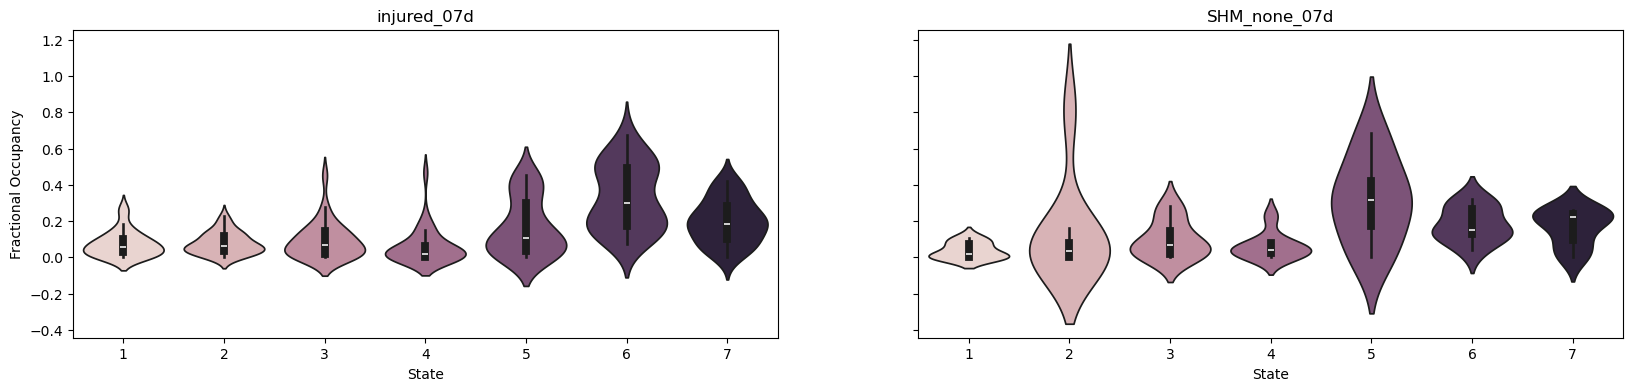

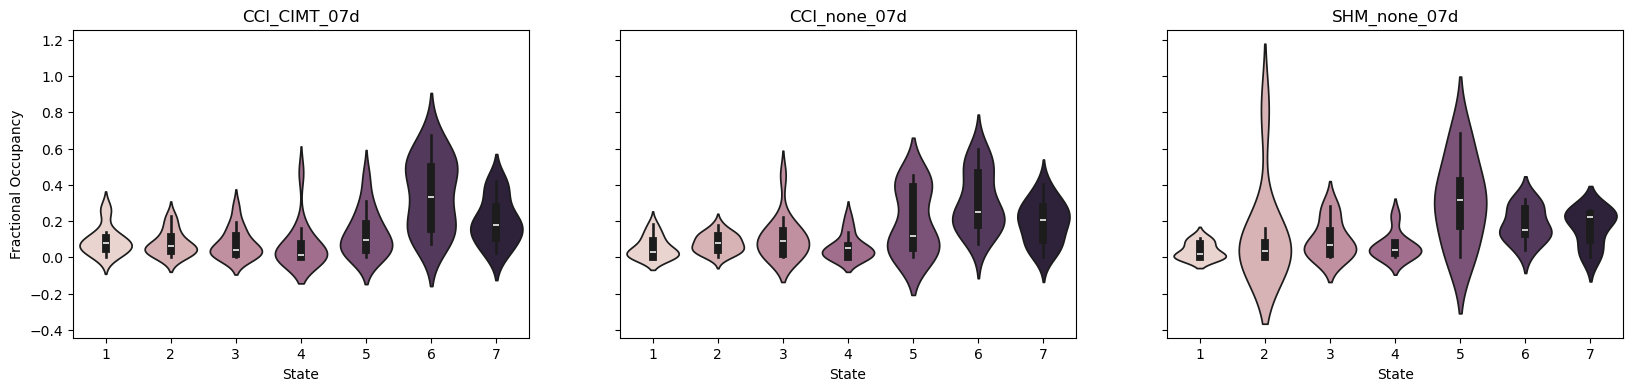

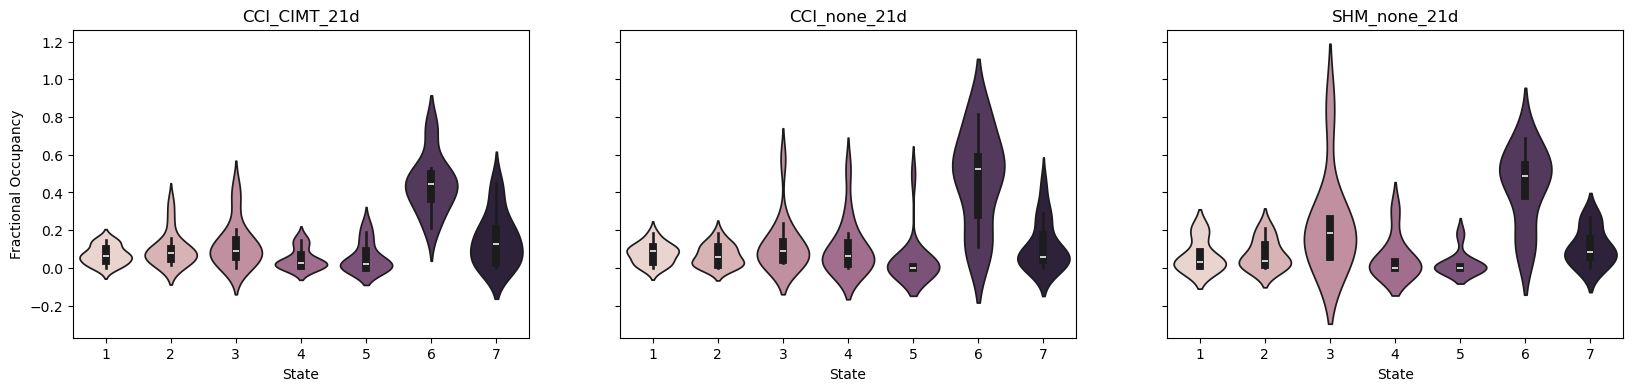

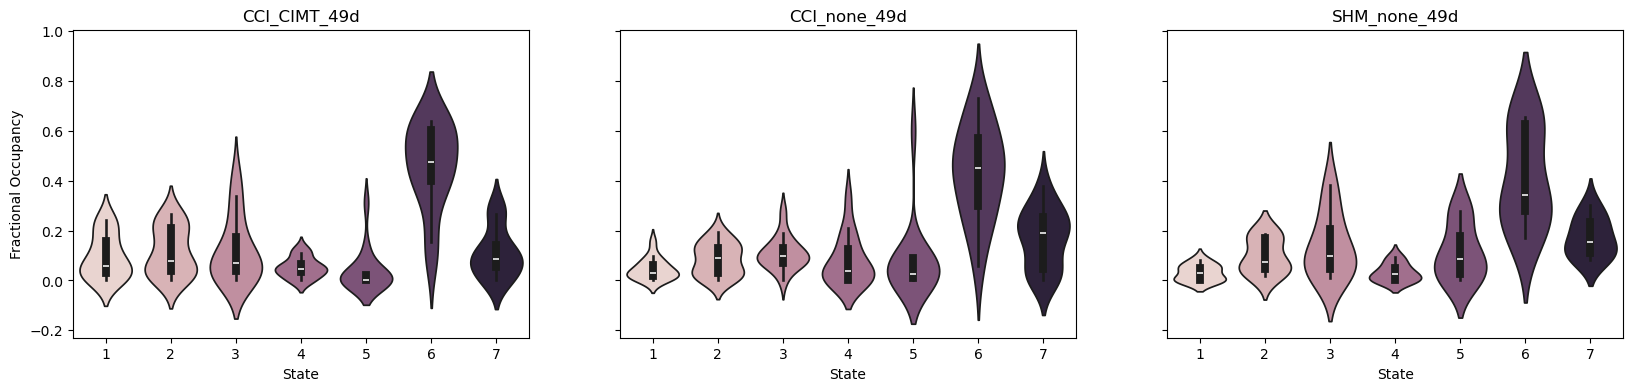

In [466]:
# FO means for each experimental group
for group in groups:
    groups[group]['fo'] = fo[np.where(y == group)]

print(sum([len(groups[group]['fo']) for group in groups]) == full_data.n_sessions)
within_group_plotting_helper('fo', "Fractional Occupancy")

## Within-group mean state lifetimes

In [467]:
# State time course (STC) for each experimental group
for group in groups:
    groups[group]['stc'] = [stc[i] for i in range(len(stc)) if i in np.where(y == group)[0]]

print(sum([len(groups[group]['stc']) for group in groups]) == full_data.n_sessions)

True


True


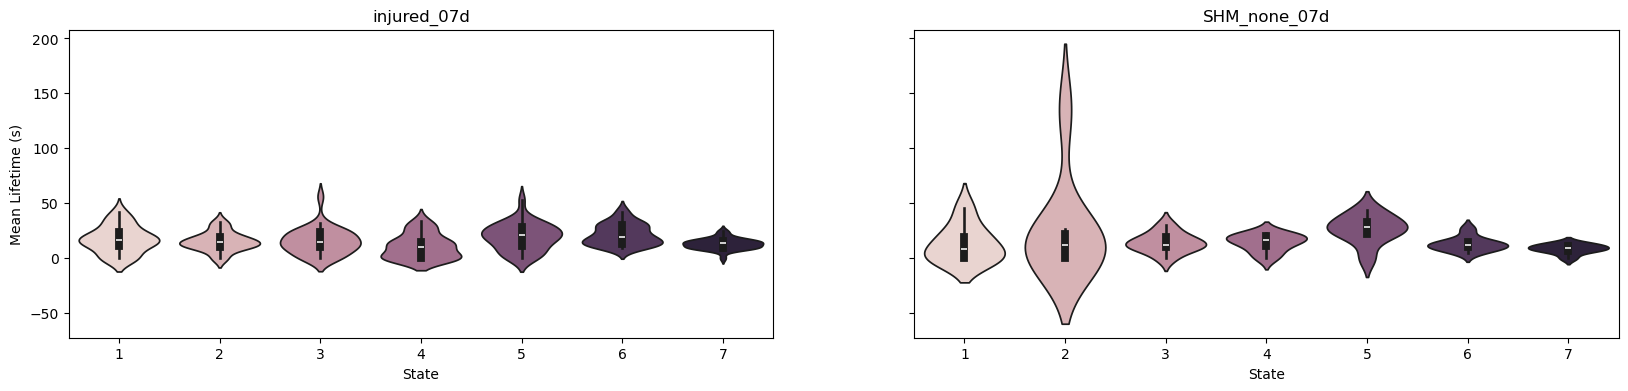

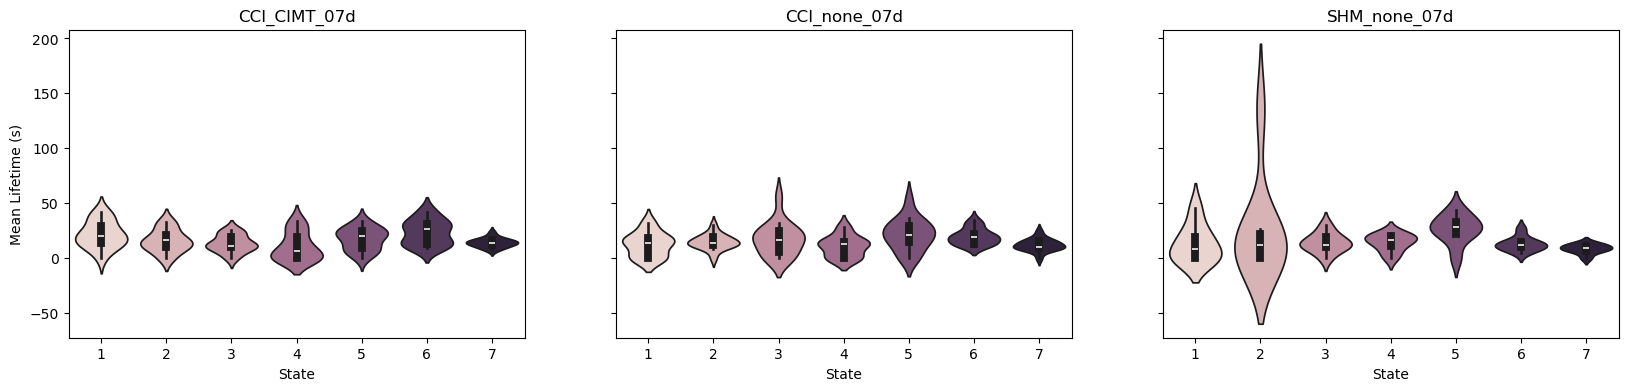

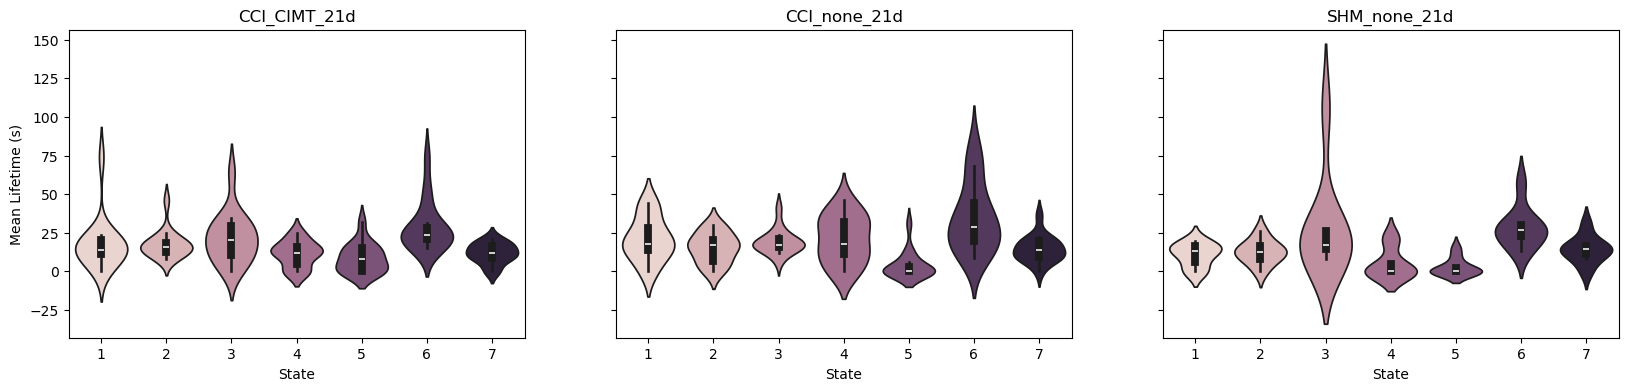

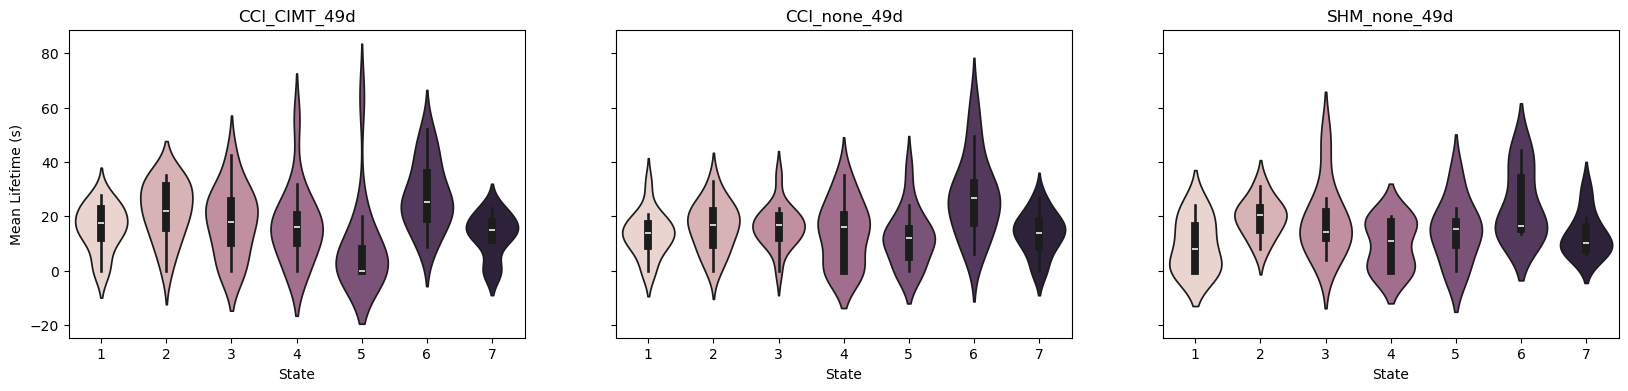

In [468]:
# Calculate mean lifetimes (in seconds) for each experimental group
for group in groups:
    groups[group]['lt'] = modes.mean_lifetimes(groups[group]['stc'], sampling_frequency=1/2) # TR = 2 s, so sampling_frequency = 1 sample per 2 seconds

print(sum([len(groups[group]['lt']) for group in groups]) == full_data.n_sessions)
within_group_plotting_helper('lt', "Mean Lifetime (s)")

## Within-group mean interstate intervals

True


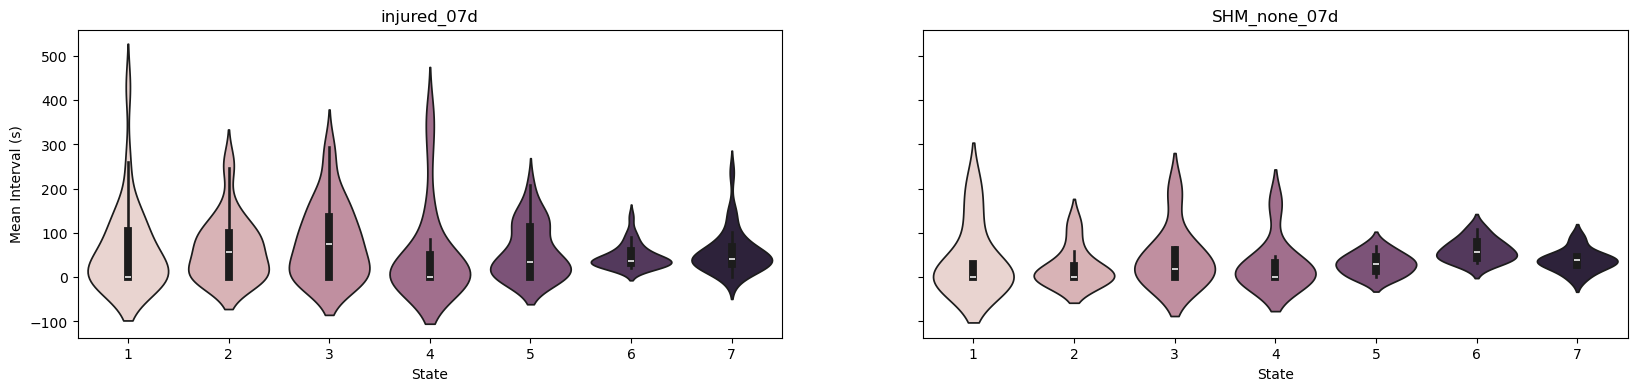

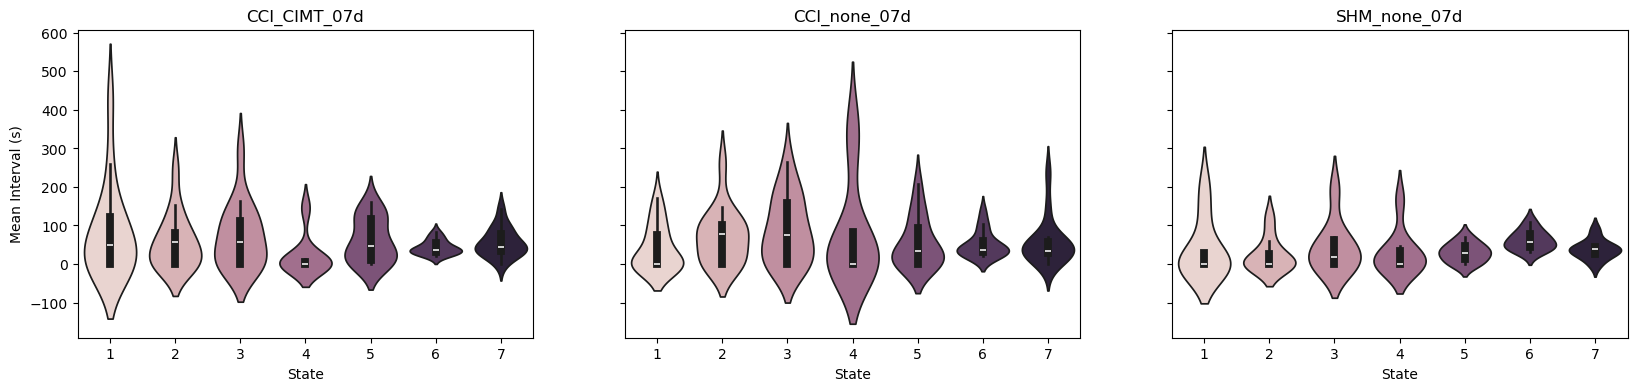

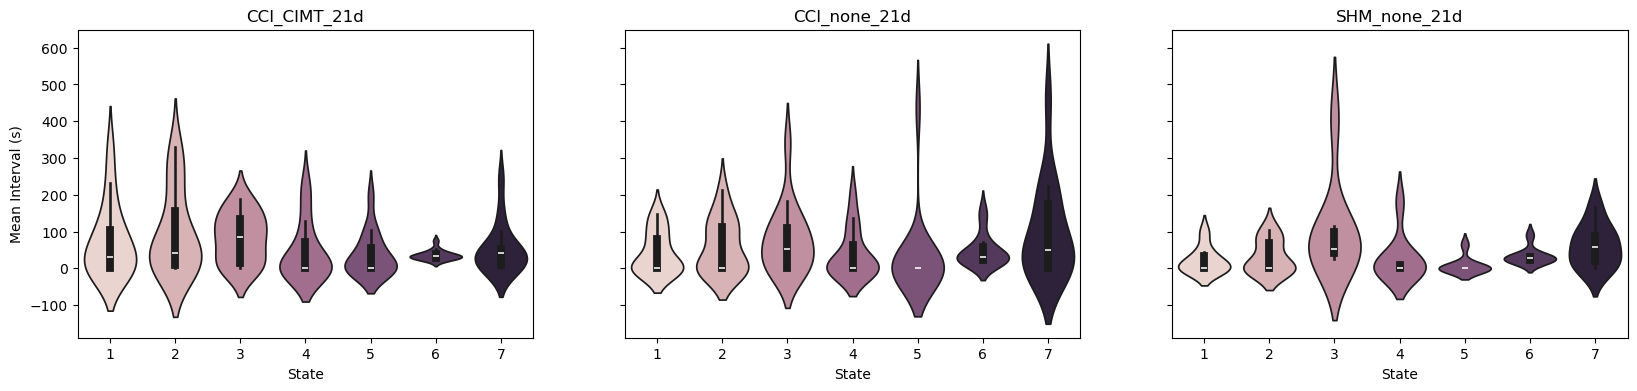

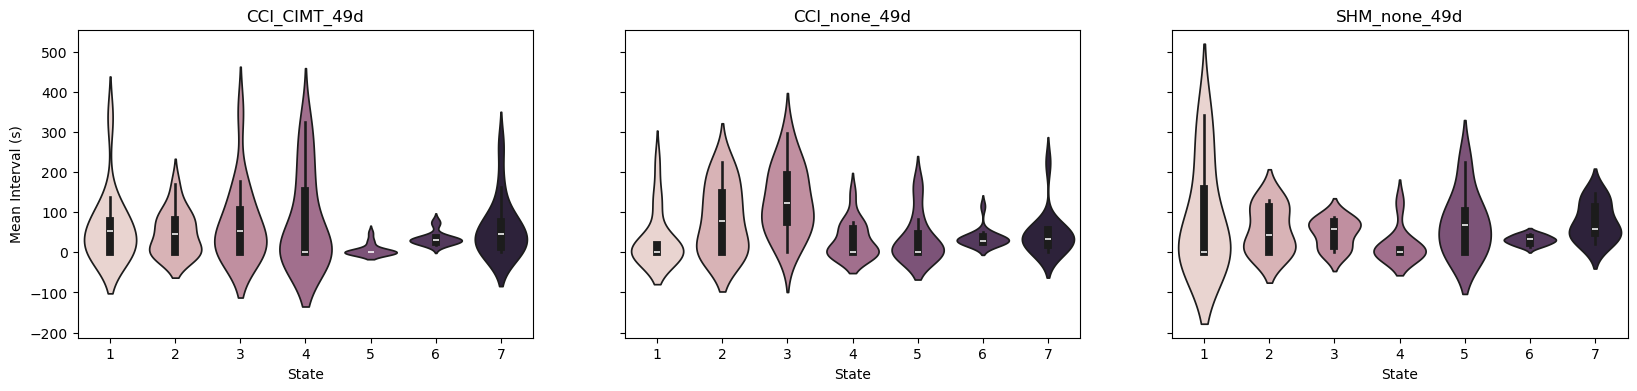

In [469]:
# Calculate mean intervals (in seconds) for each experimental group
for group in groups:
    groups[group]['intv'] = modes.mean_intervals(groups[group]['stc'], sampling_frequency=1/2)

print(sum([len(groups[group]['intv']) for group in groups]) == full_data.n_sessions)
within_group_plotting_helper('intv', "Mean Interval (s)")

## Within-group switching rate 

True


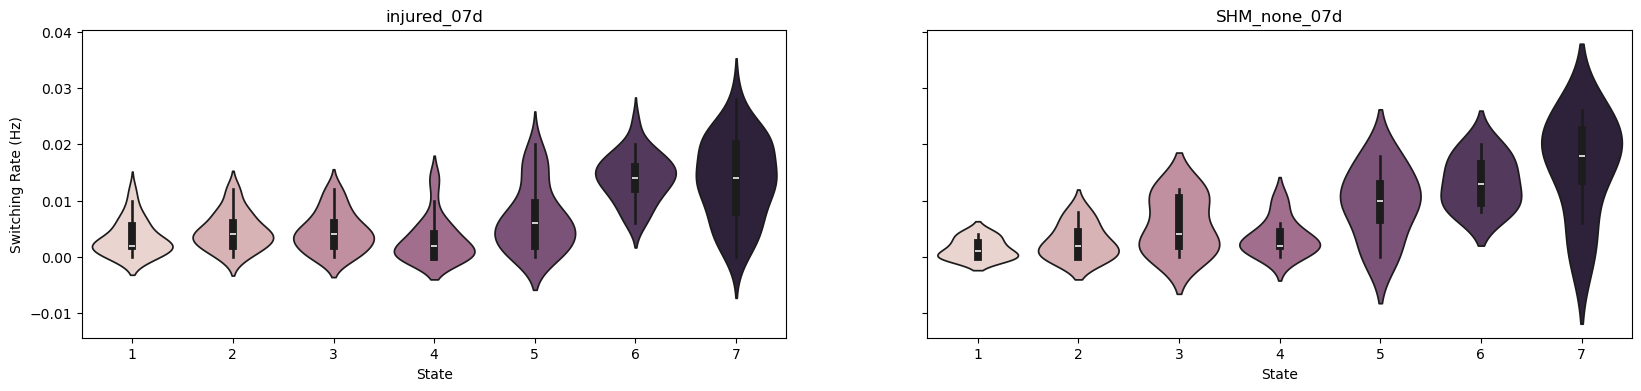

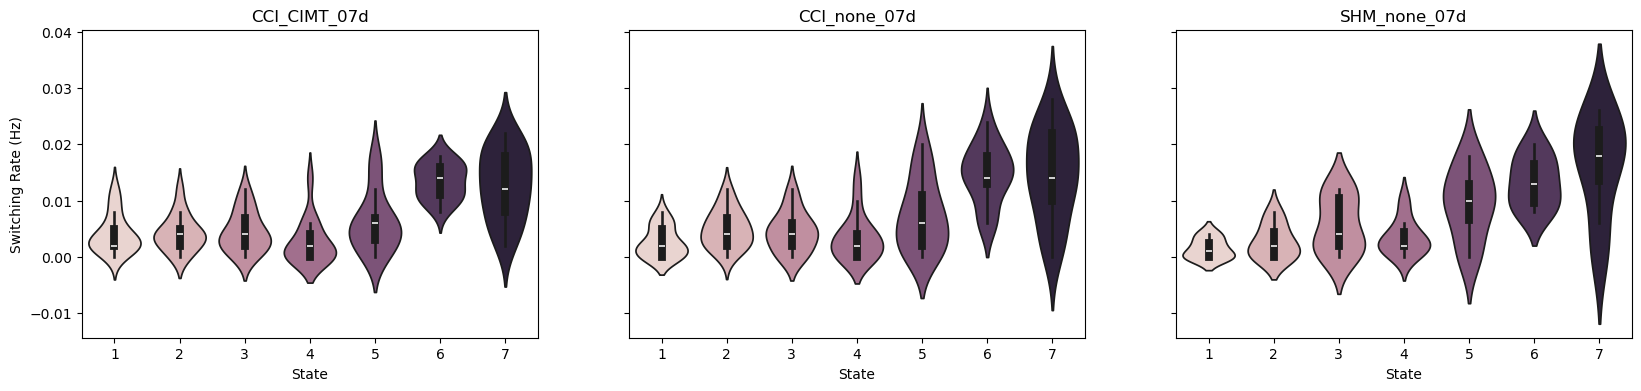

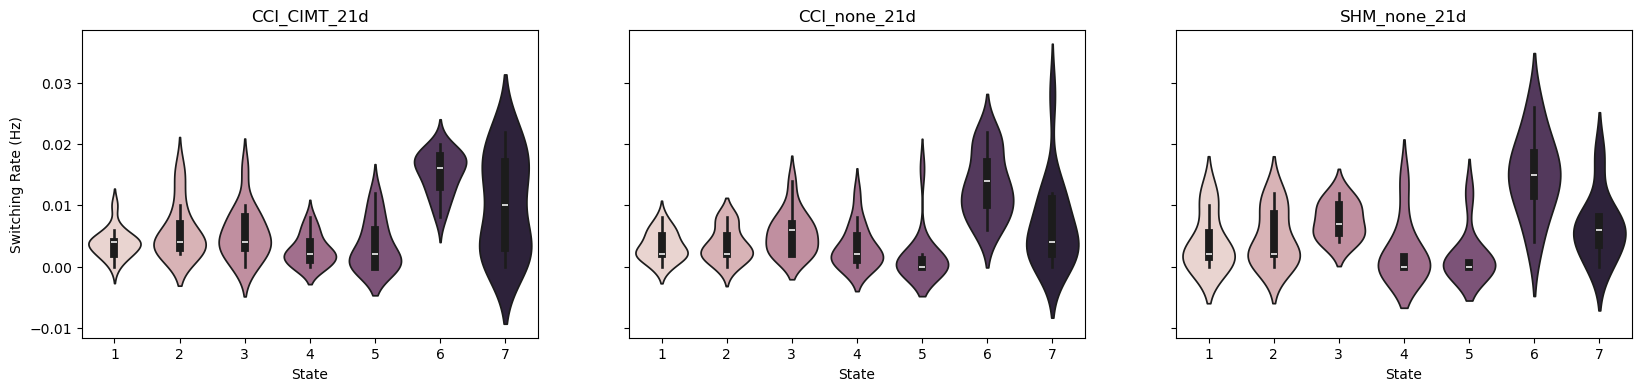

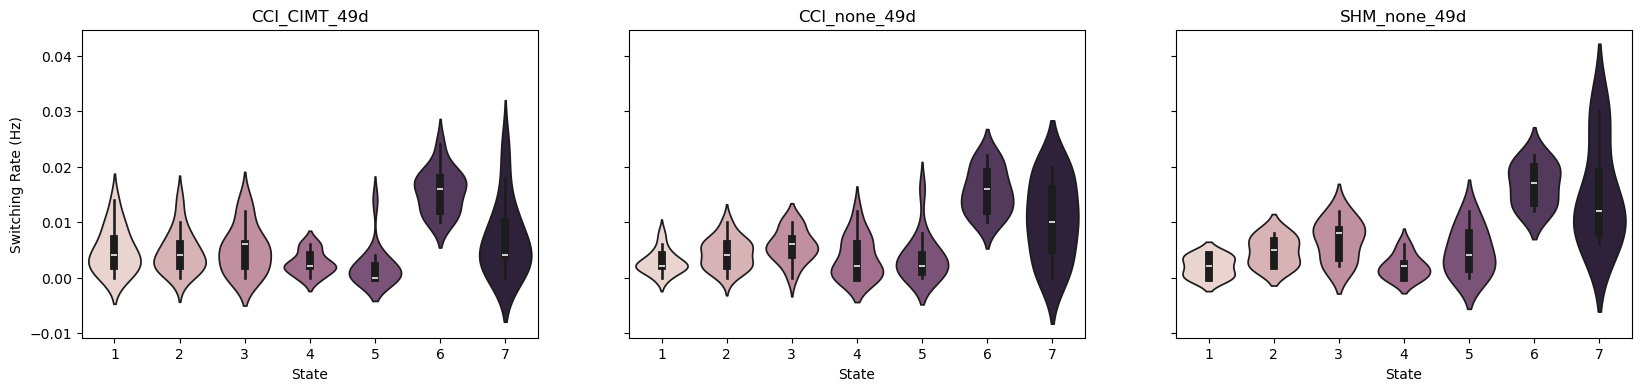

In [470]:
# Calculate the switching rate (Hz)
for group in groups:
    groups[group]['sr'] = modes.switching_rates(groups[group]['stc'], sampling_frequency=1/2)

print(sum([len(groups[group]['sr']) for group in groups]) == full_data.n_sessions)
within_group_plotting_helper('sr', "Switching Rate (Hz)")

## Subject-Level Transition Probability Matrices

In [471]:
subj_trans_matrices = post_hoc.calc_trans_prob_matrix(list(stc), n_states=k_optimal)
subj_trans_matrices.shape

(114, 7, 7)

In [472]:
for group in groups:
    group_trans_matrices = subj_trans_matrices[np.where(y == group)]
    groups[group]['trans_matrices'] = group_trans_matrices
    print(group_trans_matrices.shape)
    groups[group]['mean_trans_matrix'] = np.mean(group_trans_matrices, axis=0)
    print(groups[group]['mean_trans_matrix'].shape)

(15, 7, 7)
(7, 7)
(15, 7, 7)
(7, 7)
(15, 7, 7)
(7, 7)
(15, 7, 7)
(7, 7)
(15, 7, 7)
(7, 7)
(15, 7, 7)
(7, 7)
(8, 7, 7)
(7, 7)
(8, 7, 7)
(7, 7)
(8, 7, 7)
(7, 7)


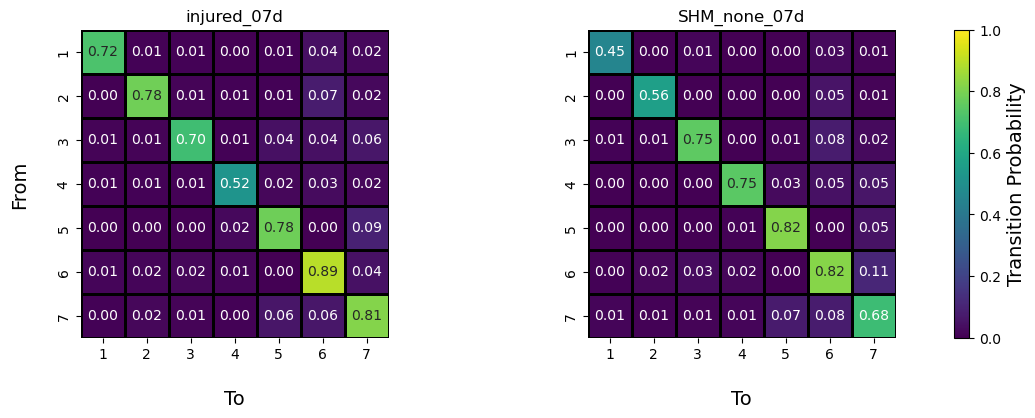

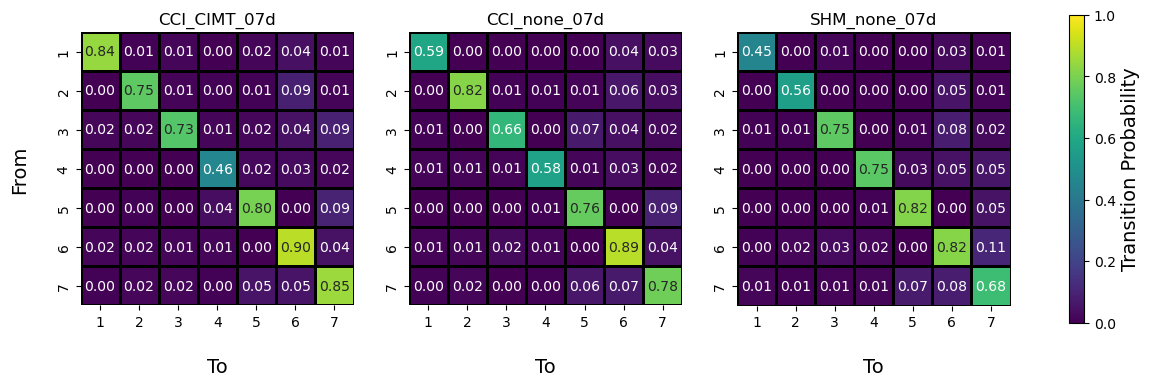

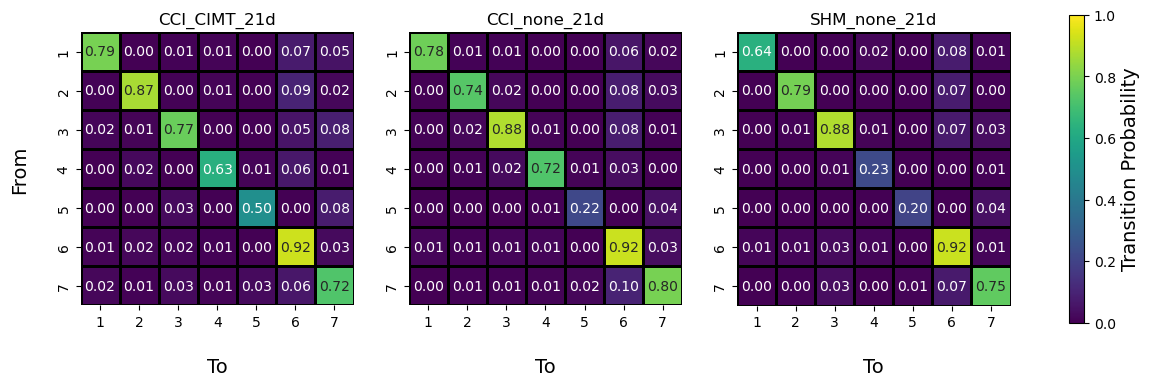

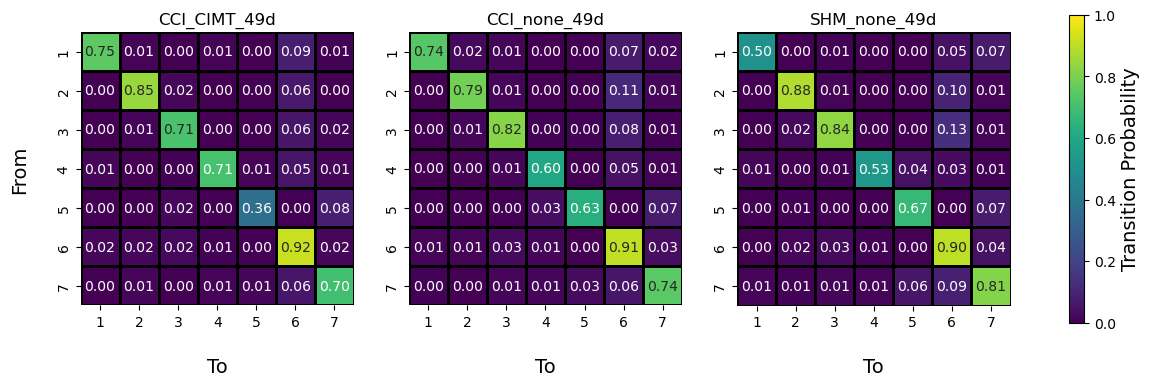

In [473]:
def heatmap_wrapper(data, ax):
    return sns.heatmap(
        data,
        cmap='viridis',
        linecolor='black',
        linewidths=1,
        cbar=False,
        annot=True,
        square=True,
        vmin=0,
        vmax=1,
        center=0.5,
        fmt='.2f',
        ax=ax,
    )

fig, axs = plt.subplots(1, 2, figsize=(15, 4))
im = heatmap_wrapper(np.mean(subj_trans_matrices[np.where((y == 'CCI_CIMT_07d') | (y == 'CCI_none_07d'))], axis=0), axs[0])
im.set_xlabel('To',fontsize=14,fontweight='regular',labelpad=20)
im.set_ylabel('From',fontsize=14,fontweight='regular',labelpad=20)
im.set_yticks(ticks=np.arange(0.5, k_optimal + 0.5, 1), labels=range(1, k_optimal + 1))
im.set_xticks(ticks=np.arange(0.5, k_optimal + 0.5, 1), labels=range(1, k_optimal + 1))
axs[0].set_title("injured_07d")

im = heatmap_wrapper(groups['SHM_none_07d']['mean_trans_matrix'], ax=axs[1])
im.set_xlabel('To',fontsize=14,fontweight='regular',labelpad=20)
im.set_yticks(ticks=np.arange(0.5, k_optimal + 0.5, 1), labels=range(1, k_optimal + 1))
im.set_xticks(ticks=np.arange(0.5, k_optimal + 0.5, 1), labels=range(1, k_optimal + 1))
axs[1].set_title('SHM_none_07d')

cbar = fig.colorbar(axs[0].collections[0], ax=axs, orientation='vertical')
cbar.set_label('Transition Probability', fontsize=14)
plt.show()

for PID in ['07d', '21d', '49d']:
    fig, axs = plt.subplots(1, 3, figsize=(15, 4))

    im = heatmap_wrapper(groups['CCI_CIMT_' + PID]['mean_trans_matrix'], ax=axs[0])
    im.set_xlabel('To',fontsize=14,fontweight='regular',labelpad=20)
    im.set_ylabel('From',fontsize=14,fontweight='regular',labelpad=20)
    im.set_yticks(ticks=np.arange(0.5, k_optimal + 0.5, 1), labels=range(1, k_optimal + 1))
    im.set_xticks(ticks=np.arange(0.5, k_optimal + 0.5, 1), labels=range(1, k_optimal + 1))
    axs[0].set_title("CCI_CIMT_" + PID)

    im = heatmap_wrapper(groups['CCI_none_' + PID]['mean_trans_matrix'], ax=axs[1])
    im.set_xlabel('To',fontsize=14,fontweight='regular',labelpad=20)
    im.set_yticks(ticks=np.arange(0.5, k_optimal + 0.5, 1), labels=range(1, k_optimal + 1))
    im.set_xticks(ticks=np.arange(0.5, k_optimal + 0.5, 1), labels=range(1, k_optimal + 1))
    axs[1].set_title("CCI_none_" + PID)
    
    im = heatmap_wrapper(groups['SHM_none_' + PID]['mean_trans_matrix'], ax=axs[2])
    im.set_xlabel('To',fontsize=14,fontweight='regular',labelpad=20)
    im.set_yticks(ticks=np.arange(0.5, k_optimal + 0.5, 1), labels=range(1, k_optimal + 1))
    im.set_xticks(ticks=np.arange(0.5, k_optimal + 0.5, 1), labels=range(1, k_optimal + 1))
    axs[2].set_title("SHM_none_" + PID)

    cbar = fig.colorbar(axs[0].collections[0], ax=axs, orientation='vertical')
    cbar.set_label('Transition Probability', fontsize=14)
    plt.show()

# Hypothesis Testing

In [497]:
ht_df = create_hypothesis_testing_dataframe(
    group_data=groups, 
    group_labels=list(np.unique(y)),
    metrics=['fo', 'lt', 'intv', 'sr'],
    k=k_optimal,
)
ht_df['condition'] = ht_df['group'].map(lambda g: 'injured' if 'CCI' in g else 'healthy')
print(ht_df.shape)
print(ht_df.columns)
ht_df

(114, 30)
Index(['fo_state1', 'fo_state2', 'fo_state3', 'fo_state4', 'fo_state5',
       'fo_state6', 'fo_state7', 'lt_state1', 'lt_state2', 'lt_state3',
       'lt_state4', 'lt_state5', 'lt_state6', 'lt_state7', 'intv_state1',
       'intv_state2', 'intv_state3', 'intv_state4', 'intv_state5',
       'intv_state6', 'intv_state7', 'sr_state1', 'sr_state2', 'sr_state3',
       'sr_state4', 'sr_state5', 'sr_state6', 'sr_state7', 'group',
       'condition'],
      dtype='object')


,fo_state1,fo_state2,fo_state3,fo_state4,fo_state5,fo_state6,fo_state7,lt_state1,lt_state2,lt_state3,...,intv_state7,sr_state1,sr_state2,sr_state3,sr_state4,sr_state5,sr_state6,sr_state7,group,condition
0,0.128,0.020,0.020,0.028,0.168,0.324,0.312,10.666667,10.000000,10.000000,...,33.750000,0.012,0.002,0.002,0.002,0.008,0.016,0.018,CCI_CIMT_07d,injured
1,0.052,0.228,0.280,0.020,0.076,0.164,0.180,13.000000,28.500000,23.333333,...,58.571429,0.004,0.008,0.012,0.002,0.006,0.012,0.014,CCI_CIMT_07d,injured
2,0.040,0.032,0.152,0.000,0.108,0.500,0.168,20.000000,16.000000,25.333333,...,47.600000,0.002,0.002,0.006,0.000,0.004,0.010,0.012,CCI_CIMT_07d,injured
3,0.084,0.144,0.196,0.000,0.012,0.480,0.084,14.000000,18.000000,24.500000,...,102.000000,0.006,0.008,0.008,0.000,0.002,0.016,0.006,CCI_CIMT_07d,injured
4,0.140,0.064,0.028,0.468,0.200,0.072,0.028,35.000000,32.000000,7.000000,...,94.000000,0.002,0.002,0.004,0.014,0.006,0.008,0.004,CCI_CIMT_07d,injured
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109,0.048,0.168,0.384,0.000,0.096,0.220,0.084,24.000000,21.000000,48.000000,...,134.000000,0.002,0.008,0.008,0.000,0.004,0.014,0.008,SHM_none_49d,healthy
110,0.060,0.184,0.188,0.036,0.000,0.296,0.236,15.000000,23.000000,15.666667,...,55.600000,0.004,0.008,0.012,0.002,0.000,0.020,0.012,SHM_none_49d,healthy
111,0.048,0.048,0.048,0.040,0.076,0.656,0.084,12.000000,24.000000,12.000000,...,62.800000,0.004,0.002,0.004,0.002,0.004,0.016,0.012,SHM_none_49d,healthy
112,0.000,0.188,0.040,0.000,0.276,0.328,0.168,0.000000,31.333333,20.000000,...,29.230769,0.000,0.006,0.002,0.000,0.012,0.018,0.028,SHM_none_49d,healthy


## Between Groups

### 07d

Note that CIMT treatment began after 07d

In [511]:
ht_df_07d = ht_df.loc[ht_df['group'].str.find('07d') != -1]
ht_df_07d['group'].unique()

array([np.str_('CCI_CIMT_07d'), np.str_('CCI_none_07d'),
       np.str_('SHM_none_07d')], dtype=object)

In [505]:
# FO
permtest_ind(
    data=ht_df_07d[[[f'fo_state{state + 1}' for state in range(k_optimal)] + ['condition']][0]], 
    class_column='condition', 
    n_perm=10_000, 
    alternative='two-sided', 
    random_state=42
)

,variable,group_1,group_2,statistic,p-value,test,effect_size,alpha_Bonferroni,reject_null
0,fo_state1,healthy,injured,-1.385540,0.164784,t-test,0.563123,0.007143,False
1,fo_state2,healthy,injured,0.596937,0.436156,welch,0.467574,0.007143,False
2,fo_state3,healthy,injured,0.192796,0.800320,t-test,0.078795,0.007143,False
3,fo_state4,healthy,injured,0.031188,0.863114,t-test,0.012692,0.007143,False
4,fo_state5,healthy,injured,2.133711,0.052795,t-test,0.878362,0.007143,False
5,fo_state6,healthy,injured,-3.127754,0.023998,welch,0.901873,0.007143,False
6,fo_state7,healthy,injured,-0.661514,0.531547,t-test,0.269574,0.007143,False


In [506]:
# State lifetimes
permtest_ind(
    data=ht_df_07d[[[f'lt_state{state + 1}' for state in range(k_optimal)] + ['condition']][0]], 
    class_column='condition', 
    n_perm=10_000, 
    alternative='two-sided', 
    random_state=42
)

,variable,group_1,group_2,statistic,p-value,test,effect_size,alpha_Bonferroni,reject_null
0,lt_state1,healthy,injured,-0.760717,0.459354,t-test,0.312604,0.007143,False
1,lt_state2,healthy,injured,0.649946,0.406359,welch,0.519362,0.007143,False
2,lt_state3,healthy,injured,-0.275339,0.828517,t-test,0.112066,0.007143,False
3,lt_state4,healthy,injured,0.814938,0.428957,t-test,0.331524,0.007143,False
4,lt_state5,healthy,injured,1.398378,0.180582,t-test,0.571797,0.007143,False
5,lt_state6,healthy,injured,-2.416241,0.010399,t-test,0.982486,0.007143,False
6,lt_state7,healthy,injured,-2.357280,0.028597,t-test,0.961036,0.007143,False


In [507]:
# Interstate intervals
permtest_ind(
    data=ht_df_07d[[[f'intv_state{state + 1}' for state in range(k_optimal)] + ['condition']][0]], 
    class_column='condition', 
    n_perm=10_000, 
    alternative='two-sided', 
    random_state=42
)

,variable,group_1,group_2,statistic,p-value,test,effect_size,alpha_Bonferroni,reject_null
0,intv_state1,healthy,injured,-0.614012,0.606739,t-test,0.250101,0.007143,False
1,intv_state2,healthy,injured,-1.531375,0.104990,t-test,0.622249,0.007143,False
2,intv_state3,healthy,injured,-1.121880,0.268173,t-test,0.456892,0.007143,False
3,intv_state4,healthy,injured,-0.574646,0.652535,t-test,0.233346,0.007143,False
4,intv_state5,healthy,injured,-2.029215,0.132987,welch,0.525068,0.007143,False
5,intv_state6,healthy,injured,1.351262,0.205579,t-test,0.551500,0.007143,False
6,intv_state7,healthy,injured,-1.035940,0.291171,t-test,0.420459,0.007143,False


In [508]:
# Switching rates
permtest_ind(
    data=ht_df_07d[[[f'sr_state{state + 1}' for state in range(k_optimal)] + ['condition']][0]], 
    class_column='condition', 
    n_perm=10_000, 
    alternative='two-sided', 
    random_state=42
)

,variable,group_1,group_2,statistic,p-value,test,effect_size,alpha_Bonferroni,reject_null
0,sr_state1,healthy,injured,-1.645334,0.127387,t-test,0.668192,0.007143,False
1,sr_state2,healthy,injured,-1.502149,0.162184,t-test,0.612946,0.007143,False
2,sr_state3,healthy,injured,0.796165,0.479752,t-test,0.327270,0.007143,False
3,sr_state4,healthy,injured,0.287686,0.811919,t-test,0.117187,0.007143,False
4,sr_state5,healthy,injured,1.133355,0.291171,t-test,0.463544,0.007143,False
5,sr_state6,healthy,injured,-0.476681,0.710329,t-test,0.194917,0.007143,False
6,sr_state7,healthy,injured,0.838264,0.442756,t-test,0.343768,0.007143,False


### 21d

#### CCI Only

In [520]:
ht_df_21d_CCI = ht_df.loc[(ht_df['group'].str.find('21d') != -1) & (ht_df['group'].str.startswith('CCI'))]
ht_df_21d_CCI['group'].unique()

array([np.str_('CCI_CIMT_21d'), np.str_('CCI_none_21d')], dtype=object)

In [513]:
# FO
permtest_ind(
    data=ht_df_21d_CCI[[[f'fo_state{state + 1}' for state in range(k_optimal)] + ['group']][0]], 
    class_column='group', 
    n_perm=10_000, 
    alternative='two-sided', 
    random_state=42
)

,variable,group_1,group_2,statistic,p-value,test,effect_size,alpha_Bonferroni,reject_null
0,fo_state1,CCI_CIMT_21d,CCI_none_21d,-0.397093,0.691931,t-test,0.150087,0.007143,False
1,fo_state2,CCI_CIMT_21d,CCI_none_21d,1.260685,0.231977,t-test,0.476494,0.007143,False
2,fo_state3,CCI_CIMT_21d,CCI_none_21d,0.100250,0.937306,t-test,0.037891,0.007143,False
3,fo_state4,CCI_CIMT_21d,CCI_none_21d,-1.464212,0.162184,welch,0.553420,0.007143,False
4,fo_state5,CCI_CIMT_21d,CCI_none_21d,0.463920,0.714129,t-test,0.175345,0.007143,False
5,fo_state6,CCI_CIMT_21d,CCI_none_21d,-0.321505,0.762324,t-test,0.121517,0.007143,False
6,fo_state7,CCI_CIMT_21d,CCI_none_21d,0.656302,0.533347,t-test,0.248059,0.007143,False


In [514]:
# State lifetimes
permtest_ind(
    data=ht_df_21d_CCI[[[f'lt_state{state + 1}' for state in range(k_optimal)] + ['group']][0]], 
    class_column='group', 
    n_perm=10_000, 
    alternative='two-sided', 
    random_state=42
)

,variable,group_1,group_2,statistic,p-value,test,effect_size,alpha_Bonferroni,reject_null
0,lt_state1,CCI_CIMT_21d,CCI_none_21d,-0.583229,0.584342,t-test,0.220440,0.007143,False
1,lt_state2,CCI_CIMT_21d,CCI_none_21d,0.701891,0.499350,t-test,0.265290,0.007143,False
2,lt_state3,CCI_CIMT_21d,CCI_none_21d,0.507393,0.644336,t-test,0.191776,0.007143,False
3,lt_state4,CCI_CIMT_21d,CCI_none_21d,-2.137716,0.044996,welch,0.807981,0.007143,False
4,lt_state5,CCI_CIMT_21d,CCI_none_21d,1.394858,0.173383,t-test,0.527207,0.007143,False
5,lt_state6,CCI_CIMT_21d,CCI_none_21d,-0.817007,0.425157,t-test,0.308800,0.007143,False
6,lt_state7,CCI_CIMT_21d,CCI_none_21d,-1.012980,0.328567,t-test,0.382871,0.007143,False


In [515]:
# Interstate intervals
permtest_ind(
    data=ht_df_21d_CCI[[[f'intv_state{state + 1}' for state in range(k_optimal)] + ['group']][0]], 
    class_column='group', 
    n_perm=10_000, 
    alternative='two-sided', 
    random_state=42
)

,variable,group_1,group_2,statistic,p-value,test,effect_size,alpha_Bonferroni,reject_null
0,intv_state1,CCI_CIMT_21d,CCI_none_21d,1.124097,0.282772,t-test,0.424869,0.007143,False
1,intv_state2,CCI_CIMT_21d,CCI_none_21d,1.106970,0.286371,t-test,0.418395,0.007143,False
2,intv_state3,CCI_CIMT_21d,CCI_none_21d,0.083998,0.938306,t-test,0.031748,0.007143,False
3,intv_state4,CCI_CIMT_21d,CCI_none_21d,0.289162,0.779322,t-test,0.109293,0.007143,False
4,intv_state5,CCI_CIMT_21d,CCI_none_21d,0.189437,0.916708,t-test,0.071600,0.007143,False
5,intv_state6,CCI_CIMT_21d,CCI_none_21d,-1.074361,0.334367,welch,0.406070,0.007143,False
6,intv_state7,CCI_CIMT_21d,CCI_none_21d,-1.244307,0.239376,welch,0.470304,0.007143,False


In [516]:
# Switching rates
permtest_ind(
    data=ht_df_21d_CCI[[[f'sr_state{state + 1}' for state in range(k_optimal)] + ['group']][0]], 
    class_column='group', 
    n_perm=10_000, 
    alternative='two-sided', 
    random_state=42
)

,variable,group_1,group_2,statistic,p-value,test,effect_size,alpha_Bonferroni,reject_null
0,sr_state1,CCI_CIMT_21d,CCI_none_21d,0.624695,0.660734,t-test,0.236113,0.007143,False
1,sr_state2,CCI_CIMT_21d,CCI_none_21d,1.593187,0.155584,t-test,0.602168,0.007143,False
2,sr_state3,CCI_CIMT_21d,CCI_none_21d,-0.094612,1.000000,t-test,0.035760,0.007143,False
3,sr_state4,CCI_CIMT_21d,CCI_none_21d,-0.487122,0.730927,t-test,0.184115,0.007143,False
4,sr_state5,CCI_CIMT_21d,CCI_none_21d,1.248636,0.268773,t-test,0.471940,0.007143,False
5,sr_state6,CCI_CIMT_21d,CCI_none_21d,1.228259,0.263574,t-test,0.464238,0.007143,False
6,sr_state7,CCI_CIMT_21d,CCI_none_21d,1.152606,0.279172,t-test,0.435644,0.007143,False


### 49d

#### CCI Only

In [519]:
ht_df_49d_CCI = ht_df.loc[(ht_df['group'].str.find('49d') != -1) & (ht_df['group'].str.startswith('CCI'))]
ht_df_49d_CCI['group'].unique()

array([np.str_('CCI_CIMT_49d'), np.str_('CCI_none_49d')], dtype=object)

In [521]:
# FO
permtest_ind(
    data=ht_df_49d_CCI[[[f'fo_state{state + 1}' for state in range(k_optimal)] + ['group']][0]], 
    class_column='group', 
    n_perm=10_000, 
    alternative='two-sided', 
    random_state=42
)

,variable,group_1,group_2,statistic,p-value,test,effect_size,alpha_Bonferroni,reject_null
0,fo_state1,CCI_CIMT_49d,CCI_none_49d,2.018765,0.056594,welch,0.763021,0.007143,False
1,fo_state2,CCI_CIMT_49d,CCI_none_49d,1.078351,0.282972,welch,0.407578,0.007143,False
2,fo_state3,CCI_CIMT_49d,CCI_none_49d,0.324275,0.768523,welch,0.122564,0.007143,False
3,fo_state4,CCI_CIMT_49d,CCI_none_49d,-0.981786,0.360164,welch,0.371080,0.007143,False
4,fo_state5,CCI_CIMT_49d,CCI_none_49d,-0.875136,0.492151,t-test,0.330770,0.007143,False
5,fo_state6,CCI_CIMT_49d,CCI_none_49d,0.432956,0.677332,t-test,0.163642,0.007143,False
6,fo_state7,CCI_CIMT_49d,CCI_none_49d,-1.449948,0.162384,t-test,0.548029,0.007143,False


In [522]:
# State lifetimes
permtest_ind(
    data=ht_df_49d_CCI[[[f'lt_state{state + 1}' for state in range(k_optimal)] + ['group']][0]], 
    class_column='group', 
    n_perm=10_000, 
    alternative='two-sided', 
    random_state=42
)

,variable,group_1,group_2,statistic,p-value,test,effect_size,alpha_Bonferroni,reject_null
0,lt_state1,CCI_CIMT_49d,CCI_none_49d,0.715688,0.479952,t-test,0.270505,0.007143,False
1,lt_state2,CCI_CIMT_49d,CCI_none_49d,1.608934,0.116788,t-test,0.608120,0.007143,False
2,lt_state3,CCI_CIMT_49d,CCI_none_49d,0.452861,0.652735,t-test,0.171165,0.007143,False
3,lt_state4,CCI_CIMT_49d,CCI_none_49d,0.627999,0.555944,t-test,0.237361,0.007143,False
4,lt_state5,CCI_CIMT_49d,CCI_none_49d,-0.679139,0.550745,t-test,0.256690,0.007143,False
5,lt_state6,CCI_CIMT_49d,CCI_none_49d,0.000191,0.999100,t-test,0.000072,0.007143,False
6,lt_state7,CCI_CIMT_49d,CCI_none_49d,-0.178865,0.858514,t-test,0.067604,0.007143,False


In [523]:
# Interstate intervals
permtest_ind(
    data=ht_df_49d_CCI[[[f'intv_state{state + 1}' for state in range(k_optimal)] + ['group']][0]], 
    class_column='group', 
    n_perm=10_000, 
    alternative='two-sided', 
    random_state=42
)

,variable,group_1,group_2,statistic,p-value,test,effect_size,alpha_Bonferroni,reject_null
0,intv_state1,CCI_CIMT_49d,CCI_none_49d,0.928534,0.388761,t-test,0.350953,0.007143,False
1,intv_state2,CCI_CIMT_49d,CCI_none_49d,-1.382360,0.176582,welch,0.522483,0.007143,False
2,intv_state3,CCI_CIMT_49d,CCI_none_49d,-1.698748,0.102990,t-test,0.642066,0.007143,False
3,intv_state4,CCI_CIMT_49d,CCI_none_49d,1.559626,0.132187,welch,0.589483,0.007143,False
4,intv_state5,CCI_CIMT_49d,CCI_none_49d,-1.846931,0.078392,welch,0.698074,0.007143,False
5,intv_state6,CCI_CIMT_49d,CCI_none_49d,-0.199680,0.872713,t-test,0.075472,0.007143,False
6,intv_state7,CCI_CIMT_49d,CCI_none_49d,0.674681,0.521348,t-test,0.255005,0.007143,False


In [524]:
# Switching rates
permtest_ind(
    data=ht_df_49d_CCI[[[f'sr_state{state + 1}' for state in range(k_optimal)] + ['group']][0]], 
    class_column='group', 
    n_perm=10_000, 
    alternative='two-sided', 
    random_state=42
)

,variable,group_1,group_2,statistic,p-value,test,effect_size,alpha_Bonferroni,reject_null
0,sr_state1,CCI_CIMT_49d,CCI_none_49d,1.805043e+00,0.107789,welch,6.822423e-01,0.007143,False
1,sr_state2,CCI_CIMT_49d,CCI_none_49d,2.220265e-01,0.924908,t-test,8.391814e-02,0.007143,False
2,sr_state3,CCI_CIMT_49d,CCI_none_49d,-4.943818e-01,0.694731,t-test,1.868588e-01,0.007143,False
3,sr_state4,CCI_CIMT_49d,CCI_none_49d,-8.341105e-01,0.493551,welch,3.152641e-01,0.007143,False
4,sr_state5,CCI_CIMT_49d,CCI_none_49d,-1.123903e+00,0.340566,t-test,4.247954e-01,0.007143,False
5,sr_state6,CCI_CIMT_49d,CCI_none_49d,1.183465e-15,0.990101,t-test,4.473077e-16,0.007143,False
6,sr_state7,CCI_CIMT_49d,CCI_none_49d,-1.356925e+00,0.193981,t-test,5.128694e-01,0.007143,False
